In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import math
from itertools import combinations,  count
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from sklearn.tree import DecisionTreeClassifier, plot_tree
import scipy.stats as stats
from scipy.stats import kurtosis, skew
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association
from scipy.stats import kruskal
import scikit_posthocs as sp
import re
import scikit_posthocs as sp
from statannotations.Annotator import Annotator
from sklearn.preprocessing import StandardScaler


### EDA FUNCTIONS

### Histograms

In [114]:
def plot_hist_with_stats(df, column, bins=30):

    data = df[column]

    mean_val = data.mean()
    std_val  = data.std()

    plt.figure(figsize=(8,5))
    
    sns.histplot(
        data=data,
        bins=bins,
        kde=True,
        color='skyblue',
        edgecolor='black'
    )

    # Líneas de media y ±1 SD
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2f}')
    plt.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=1.5, label=f'+1 SD = {mean_val+std_val:.2f}')
    plt.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=1.5, label=f'-1 SD = {mean_val-std_val:.2f}')

    plt.title(f'Distribution of {column}', fontsize=13, fontweight='bold')
    plt.xlabel(column, fontsize=11)
    plt.ylabel('Frequency', fontsize=11)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print('Statistical descriptors:')
    print(df[column].describe())


#### ANOVA LPA

In [115]:
def kruskal_dunn_analysis_LPA(motor_data, columns):

    categories = [
        'General Improv.',
        'Stability',
        'General Progress.',
    ]

    # Diccionario dinámico
    groups = {
        cat: motor_data.loc[motor_data['Perfil_LPA'] == cat, columns]
        for cat in categories
    }

    # Colores (8 colores)
    colors = [
        '#4C72B0', '#55A868', '#C44E52'
    ]

    kruskal_results = {}
    dunn_tables = {}

    # ============================
    # FIGURES & STATISTICS
    # ============================
    fig, axes = plt.subplots(1, len(columns), figsize=(8 * len(columns), 6))
    axes = axes.flatten() if len(columns) > 1 else [axes]

    for i, col in enumerate(columns):

        data_to_plot = [g[col] for g in groups.values()]

        # === Kruskal-Wallis ===
        h_stat, p_val = kruskal(*data_to_plot)
        kruskal_results[col] = (h_stat, p_val)

        # === BOXPLOT ===
        box = axes[i].boxplot(
            data_to_plot,
            labels=categories,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color='black', linewidth=2),
            boxprops=dict(linewidth=1.5),
            whiskerprops=dict(linewidth=1.5),
            capprops=dict(linewidth=1.5)
        )

        for patch, color in zip(box['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        axes[i].set_title(
            f"{col} - 3 TypeGeneralProgression\nKruskal–Wallis p={p_val:.4f}",
            fontsize=12, fontweight="bold"
        )
        axes[i].set_ylabel("Score", fontsize=11)
        # === Estética de ejes ===
        axes[i].tick_params(axis='x', labelsize=9)

        # Rotar y alinear etiquetas del eje X
        for label in axes[i].get_xticklabels():
            label.set_rotation(0)
            label.set_horizontalalignment('center')
        axes[i].grid(axis='y', linestyle='--', alpha=0.6)

        # === Dunn Post-Hoc Test ===
        if p_val < 0.05:

            tmp = pd.concat([
                pd.DataFrame({'Group': group, col: data[col]})
                for group, data in groups.items()
            ])

            dunn = sp.posthoc_dunn(
                tmp, val_col=col, group_col='Group',
                p_adjust='bonferroni'
            ).round(4)

            dunn_tables[col] = dunn

    plt.tight_layout()
    plt.show()

    # ============================
    # KRUSKAL RESULTS
    # ============================
    print("=== KRUSKAL–WALLIS RESULTS (8 categories) ===")
    for col, (h, p) in kruskal_results.items():
        if p < 0.05:
            print(f"{col}: H={h:.3f}, p={p:.4e}  --> ✅ Significant (Dunn performed)")
        else:
            print(f"{col}: H={h:.3f}, p={p:.4e}  --> 🛑 Not significant")

    # ============================
    # DUNN TABLES
    # ============================
    for col, dunn_df in dunn_tables.items():
        print(f"\n=== Dunn's Test Table — {col} (Significant: p < 0.05) ===")
        display(dunn_df)

        plt.figure(figsize=(8, 7))
        sns.heatmap(
            dunn_df, annot=True, cmap="coolwarm_r", fmt=".4f",
            cbar_kws={'label': 'Adjusted p-value'}
        )
        plt.title(f"Dunn’s Test — {col}\n(Bonferroni Correction)", fontsize=12, fontweight="bold")
        plt.yticks(rotation=0)
        plt.xticks(rotation=0, ha='center')
        plt.tight_layout()
        plt.show()


#### ANOVA FOR 2 Type

In [116]:
def kruskal_dunn_ynprogression(data, yn_col, score_cols):
    """
    Performs Kruskal–Wallis tests comparing exactly two Y/N progression groups.
    If p < 0.05, performs Dunn's post-hoc test.

    Generates:
        - Boxplots for each score variable
        - Dunn post-hoc table (only when significant)
        - Dunn heatmap (only when significant)
    """


    # ============================
    # Internal color palette
    # ============================
    COLORS = ['#4C72B0', '#55A868']  # always 2 groups

    # ============================
    # Get the two categories
    # ============================
    category_1, category_2 = data[yn_col].unique()

    groups = {
        category_1: data.loc[data[yn_col] == category_1, score_cols],
        category_2: data.loc[data[yn_col] == category_2, score_cols]
    }

    # ============================
    # Figure setup
    # ============================
    fig, axes = plt.subplots(1, len(score_cols), figsize=(7 * len(score_cols), 6))
    axes = axes.flatten() if len(score_cols) > 1 else [axes]

    kruskal_results = {}
    dunn_tables = {}

    # ============================
    # Main loop
    # ============================
    for i, col in enumerate(score_cols):

        # Extract the two groups (no NaN)
        data_to_plot = [g[col] for g in groups.values()]

        # --- Kruskal–Wallis ---
        h_stat, p_val = kruskal(*data_to_plot)
        kruskal_results[col] = (h_stat, p_val)

        # --- BOXPlot ---
        box = axes[i].boxplot(
            data_to_plot,
            labels=groups.keys(),
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color='black', linewidth=2),
            boxprops=dict(linewidth=1.5),
            whiskerprops=dict(linewidth=1.5),
            capprops=dict(linewidth=1.5)
        )

        for patch, c in zip(box['boxes'], COLORS):
            patch.set_facecolor(c)
            patch.set_alpha(0.7)

        axes[i].set_title(
            f"{col} - {yn_col} \nKruskal–Wallis p = {p_val:.4f}",
            fontsize=11, fontweight='bold'
        )
        axes[i].set_ylabel("Score")
        axes[i].grid(axis='y', linestyle='--', alpha=0.6)

        # === Dunn’s test ONLY if p < 0.05 ===
        if p_val < 0.05:

            tmp = pd.concat([
                pd.DataFrame({'Group': group_label, col: df[col]})
                for group_label, df in groups.items()
            ])

            dunn = sp.posthoc_dunn(
                tmp, val_col=col, group_col='Group', p_adjust='bonferroni'
            ).round(4)

            dunn_tables[col] = dunn

    plt.tight_layout()
    plt.show()

    # ============================
    # PRINT SUMMARY
    # ============================
    print("\n=== KRUSKAL–WALLIS RESULTS (YNProgression) ===")
    for col, (h, p) in kruskal_results.items():
        if p < 0.05:
            print(f"{col}: H = {h:.3f}, p = {p:.4e}  --> ✅ Significant (Dunn performed)")
        else:
            print(f"{col}: H = {h:.3f}, p = {p:.4e}  --> 🛑 Not significant")

    # ============================
    # DUNN RESULTS + HEATMAPS
    # ============================
    for col, dunn_df in dunn_tables.items():
        print(f"\n=== Dunn’s Test for {col} ===")
        display(dunn_df)

        plt.figure(figsize=(5, 4))
        sns.heatmap(
            dunn_df,
            annot=True,
            cmap="coolwarm_r",
            fmt=".4f",
            cbar_kws={'label': 'Adjusted p-value'}
        )
        plt.title(f"Dunn’s Test — {col}", fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

    return kruskal_results, dunn_tables


#### ANOVA FOR UPDRS CLASS visit vs MCID

In [117]:
def kruskal_dunn_by_class(data, class_col, score_cols, class_order=None):
    """
    Performs Kruskal–Wallis tests grouped by a class variable.
    If the Kruskal–Wallis p-value < 0.05, a Dunn post-hoc test is performed.
    Generates:
        - Boxplots
        - Dunn table (only when significant)
        - Dunn heatmap (only when significant)
    """
    COLORS = ['#55A868', '#4C72B0']

    # ============================
    # Prepare groups
    # ============================
    if class_order is None:
        class_order = sorted(data[class_col].unique())

    groups = {
        group: data.loc[data[class_col] == group, score_cols]
        for group in class_order
    }

    colors = COLORS[:len(groups)]

    # ============================
    # Figure layout
    # ============================
    fig, axes = plt.subplots(1, len(score_cols), figsize=(7 * len(score_cols), 6))
    axes = axes.flatten() if len(score_cols) > 1 else [axes]

    kruskal_results = {}
    dunn_tables = {}

    # ============================
    # Main loop
    # ============================
    for i, col in enumerate(score_cols):

        # Extract values for each class
        data_to_plot = [g[col] for g in groups.values()]  

        # --- Kruskal–Wallis ---
        h_stat, p_val = kruskal(*data_to_plot)
        kruskal_results[col] = (h_stat, p_val)

        # --- Boxplot ---
        box = axes[i].boxplot(
            data_to_plot,
            labels=groups.keys(),
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color='black', linewidth=2),
            boxprops=dict(linewidth=1.5),
            whiskerprops=dict(linewidth=1.5),
            capprops=dict(linewidth=1.5)
        )

        for patch, c in zip(box['boxes'], colors):
            patch.set_facecolor(c)
            patch.set_alpha(0.7)

        axes[i].set_title(
            f"{col} — {class_col}\nKruskal–Wallis p = {p_val:.4f}",
            fontsize=12, fontweight='bold'
        )
        axes[i].set_ylabel("Score")
        axes[i].grid(axis='y', linestyle='--', alpha=0.6)

        # === Dunn test only if p < 0.05 ===
        if p_val < 0.05:

            tmp = pd.concat([
                pd.DataFrame({'Group': group, col: g[col]})
                for group, g in groups.items()
            ])

            dunn = sp.posthoc_dunn(
                tmp, val_col=col, group_col='Group', p_adjust='bonferroni'
            ).round(4)

            dunn_tables[col] = dunn

    plt.tight_layout()
    plt.show()

    # ============================
    # Print Kruskal results
    # ============================
    print("\n=== KRUSKAL–WALLIS RESULTS ===")
    for col, (h, p) in kruskal_results.items():
        if p < 0.05:
            print(f"{col}: H = {h:.3f}, p = {p:.4e}  --> ✅ Significant (Dunn performed)")
        else:
            print(f"{col}: H = {h:.3f}, p = {p:.4e}  --> 🛑 Not significant")

    # ============================
    # Dunn post-hoc (only significant)
    # ============================
    for col, dunn_df in dunn_tables.items():
        print(f"\n=== Dunn’s Test for {col} ===")
        display(dunn_df)

        plt.figure(figsize=(6, 5))
        sns.heatmap(
            dunn_df,
            annot=True,
            cmap="coolwarm_r",
            fmt=".4f",
            cbar_kws={'label': 'Adjusted p-value'}
        )
        plt.title(f"Dunn’s Test — {col}", fontsize=12, fontweight='bold')
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    return kruskal_results, dunn_tables


#### Chi^2 Analysis 

In [118]:
def chi_square_heatmap(data, col_1, col_2, order_1=None, order_2=None):

    # === Build contingency table ===
    contingency_table = pd.crosstab(
        data[col_1],
        data[col_2]
    )

    # Apply custom order
    if order_1 is not None:
        contingency_table = contingency_table.reindex(order_1)
    if order_2 is not None:
        contingency_table = contingency_table.reindex(columns=order_2)

    # === Chi-square test ===
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # === Cramer's V ===
    cramer_v = association(contingency_table, method="cramer")

    # Interpretation of effect size
    if cramer_v < 0.20:
        effect = "Weak"
    elif cramer_v < 0.60:
        effect = "Moderate"
    else:
        effect = "Strong"

    # === PRINT BASIC RESULTS ===
    print(f"\n=============================")
    print(f" Chi-square test for: {col_1} vs {col_2}")
    print(f"=============================\n")
    print(f"Chi² statistic = {chi2:.3f}")
    print(f"p-value = {p:.4f}")
    print(f"Degrees of freedom = {dof}")
    print(f"Cramér's V = {cramer_v:.3f}")
    print(f"Effect size: {effect}")

    # === ONLY IF SIGNIFICANT ===
    if p < 0.05:
        print(" ✅ Significant association (p < 0.05)\n")

        # === Display contingency table ===
        print("Contingency table (ordered):")
        display(contingency_table)

        # === Standardized residuals ===
        residuals = (contingency_table - expected) / np.sqrt(expected)

        # === Heatmap of contingency table ===
        plt.figure(figsize=(8, 5))
        sns.heatmap(
            contingency_table,
            annot=True,
            cmap="Blues",
            fmt="d",
            cbar_kws={'label': 'Counts'}
        )
        plt.title(f"Contingency Table — {col_1} vs {col_2}",
                  fontsize=12, fontweight='bold')
        plt.xlabel(col_2)
        plt.ylabel(col_1)
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

        # === Residuals heatmap ===
        plt.figure(figsize=(8, 5))
        sns.heatmap(
            residuals,
            annot=True,
            cmap="coolwarm",
            center=0,
            fmt=".2f",
            cbar_kws={'label': 'Standardized residuals'}
        )
        plt.title(
            f"Standardized Residuals — {col_1} vs {col_2}\n"
            f"p={p:.3f} | Cramér's V={cramer_v:.3f} ({effect})",
            fontsize=12,
            fontweight='bold'
        )
        plt.xlabel(col_2)
        plt.ylabel(col_1)
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

    else:
        print(" 🛑 No significant association (p ≥ 0.05)")
        print("    → No tables or heatmaps displayed.")

    print("\n" + "-"*80 + "\n")


# Motor analyisis data

In [119]:
motor_data = pd.read_csv('/Users/fserracrespi/Desktop/PD_Project_UofL/PD_DATA/PD_1y_progress_DATA/Data_Motor_1Year_12SEP2025.csv')
motor_data.drop(columns=['Unnamed: 0','Is the participant on medication or receiving deep brain stimulation for treating the symptoms of Parkinsons disease?',
                            'Is subject on medication for PD'],inplace=True)
motor_data.sort_values(by=['PATNO','Visit ID'],inplace=True)
motor_data.head(3)

,PATNO,Visit ID,MDS-UPDRS Part I (Patient Questionnaire) Total Score,MDS-UPDRS Part II Total Score,Does participant have DBS,MDS-UPDRS Part III Total Score,3.21 HOEHN AND YAHR STAGE,MDS-UPDRS Part IV Total Score,DBS_Transition_Visit,DBS_Post_Transition,SCHWAB & ENGLAND ADL,MDS-UPDRS Total Score 1YearProg,UPDRS_III_1YearProg,MDS-UPDRS Total Score,Δ TOTAL_UPDRS_1Y,Δ UPDRS_I_1Y,Δ UPDRS_II_1Y,Δ UPDRS_III_1Y,Δ UPDRS_IV_1Y
728,3001,V10_V12,6,5.0,0,35,2,0.0,False,0.0,90,37.0,26,46.0,-9.0,1,-1.0,-9,0.0
729,3003,V10_V12,9,10.0,0,53,3,0.0,False,0.0,85,59.0,39,72.0,-13.0,2,-1.0,-14,0.0
730,3010,V10_V12,11,16.0,0,18,2,7.0,False,0.0,80,70.0,34,52.0,18.0,0,4.0,16,-2.0


## UPDRS CLASS

In [120]:
def clasificar_updrs_thresholds(df):
    df = df.copy()

    # Diccionario de puntos de corte oficiales por Parte
    thresholds = {
        'I': (10, 21),   # <=10 leve, 11-21 moderado, >=22 severo
        'II': (12, 29),  # <=12 leve, 13-29 moderado, >=30 severo
        'III': (32, 58), # <=32 leve, 33-58 moderado, >=59 severo
        'IV': (4, 12)    # <=4 leve, 5-12 moderado, >=13 severo
    }

    # Mapeo de columnas del dataframe
    columnas = {
        'I': 'MDS-UPDRS Part I (Patient Questionnaire) Total Score',
        'II': 'MDS-UPDRS Part II Total Score',
        'III': 'MDS-UPDRS Part III Total Score',
        'IV': 'MDS-UPDRS Part IV Total Score'
    }

    # Función para clasificar según thresholds
    def clasificar(valor, parte):
        t1, t2 = thresholds[parte]

        if valor <= t1:
            return 'Mild'
        elif valor <= t2:
            return 'Moderate'
        else:
            return 'Moderate' #deberia ser severe pero por balance lo dejo en moderado 

    # Aplicar clasificación por parte
    for parte, col in columnas.items():
        df[f'UPDRS_{parte}_Class'] = df[col].apply(lambda x: clasificar(x, parte))

    return df


# Aplicar la clasificación al dataframe
motor_data = clasificar_updrs_thresholds(motor_data)


# Distribución por categoría
for col in ['UPDRS_I_Class', 'UPDRS_II_Class', 'UPDRS_III_Class', 'UPDRS_IV_Class']:
    print(f"\nDistribución en {col}:")
    print(motor_data[col].value_counts())




Distribución en UPDRS_I_Class:
UPDRS_I_Class
Mild        806
Moderate    105
Name: count, dtype: int64

Distribución en UPDRS_II_Class:
UPDRS_II_Class
Mild        779
Moderate    132
Name: count, dtype: int64

Distribución en UPDRS_III_Class:
UPDRS_III_Class
Mild        808
Moderate    103
Name: count, dtype: int64

Distribución en UPDRS_IV_Class:
UPDRS_IV_Class
Mild        781
Moderate    130
Name: count, dtype: int64


In [121]:
motor_data.columns

Index(['PATNO', 'Visit ID',
       'MDS-UPDRS Part I (Patient Questionnaire) Total Score',
       'MDS-UPDRS Part II Total Score', 'Does participant have DBS',
       'MDS-UPDRS Part III Total Score', '3.21 HOEHN AND YAHR STAGE',
       'MDS-UPDRS Part IV Total Score', 'DBS_Transition_Visit',
       'DBS_Post_Transition', 'SCHWAB & ENGLAND ADL',
       'MDS-UPDRS Total Score 1YearProg', 'UPDRS_III_1YearProg',
       'MDS-UPDRS Total Score', 'Δ TOTAL_UPDRS_1Y', 'Δ UPDRS_I_1Y',
       'Δ UPDRS_II_1Y', 'Δ UPDRS_III_1Y', 'Δ UPDRS_IV_1Y', 'UPDRS_I_Class',
       'UPDRS_II_Class', 'UPDRS_III_Class', 'UPDRS_IV_Class'],
      dtype='object')

### Chi2 analysis class

Combination of UPDRS_I_Class and UPDRS_II_Class:

 Chi-square test for: UPDRS_I_Class vs UPDRS_II_Class

Chi² statistic = 114.392
p-value = 0.0000
Degrees of freedom = 1
Cramér's V = 0.359
Effect size: Moderate
 ✅ Significant association (p < 0.05)

Contingency table (ordered):


UPDRS_II_Class,Mild,Moderate
UPDRS_I_Class,,
Mild,726,80
Moderate,53,52


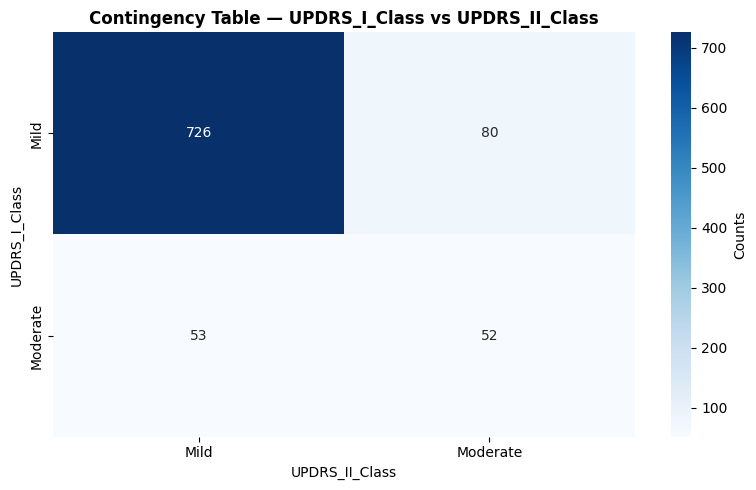

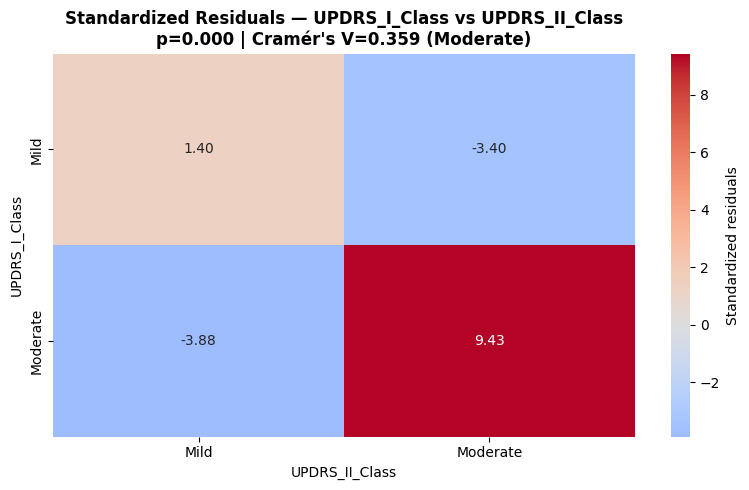


--------------------------------------------------------------------------------

Combination of UPDRS_I_Class and UPDRS_III_Class:

 Chi-square test for: UPDRS_I_Class vs UPDRS_III_Class

Chi² statistic = 6.247
p-value = 0.0124
Degrees of freedom = 1
Cramér's V = 0.088
Effect size: Weak
 ✅ Significant association (p < 0.05)

Contingency table (ordered):


UPDRS_III_Class,Mild,Moderate
UPDRS_I_Class,,
Mild,723,83
Moderate,85,20


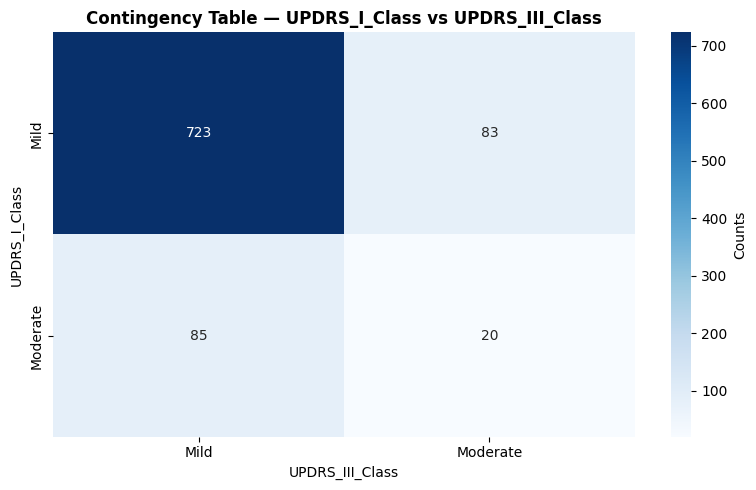

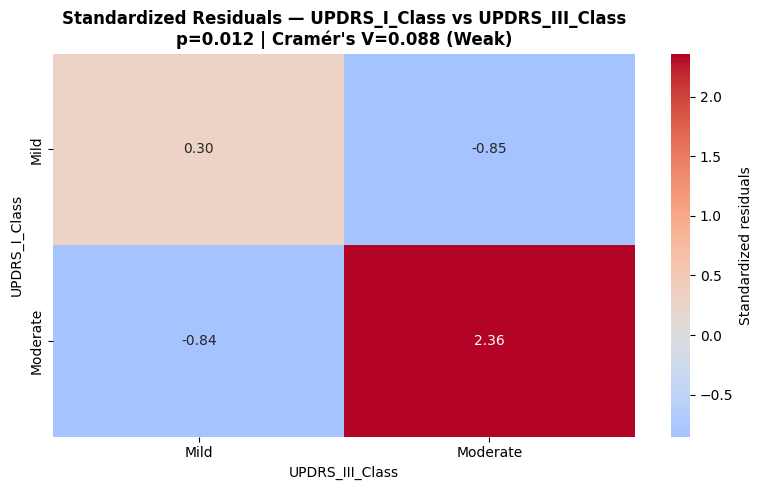


--------------------------------------------------------------------------------

Combination of UPDRS_II_Class and UPDRS_III_Class:

 Chi-square test for: UPDRS_II_Class vs UPDRS_III_Class

Chi² statistic = 41.127
p-value = 0.0000
Degrees of freedom = 1
Cramér's V = 0.217
Effect size: Moderate
 ✅ Significant association (p < 0.05)

Contingency table (ordered):


UPDRS_III_Class,Mild,Moderate
UPDRS_II_Class,,
Mild,713,66
Moderate,95,37


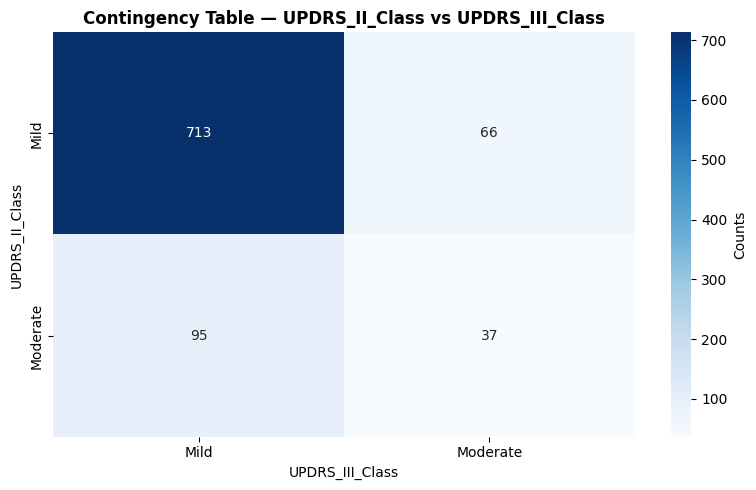

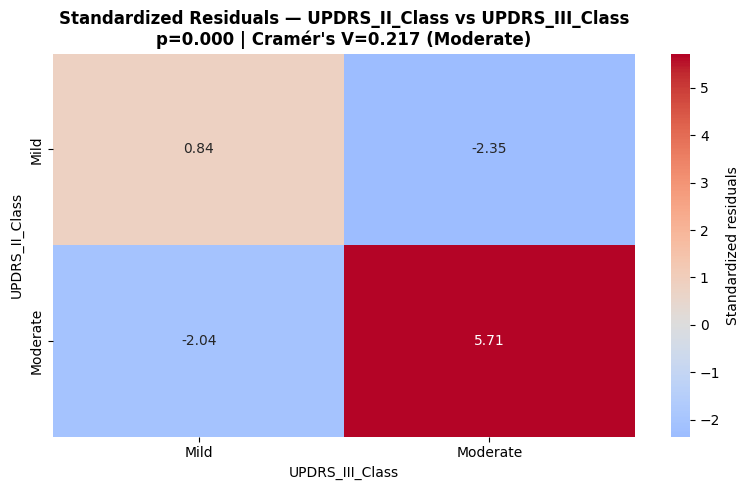


--------------------------------------------------------------------------------



In [122]:
from itertools import combinations

palabras = ['UPDRS_I_Class', 'UPDRS_II_Class', 'UPDRS_III_Class']

resultado = list(combinations(palabras, 2))

for combo in resultado:
    print(f'Combination of {combo[0]} and {combo[1]}:')
    chi_square_heatmap(motor_data, combo[0], combo[1], order_1=None, order_2=None)
    

## UPDRS Progression 

In [123]:
# 4 types of progression based MCID
def categorize_progression(delta, T1, T2):
    if delta <= T1:
        return 'Substantial improv.' 
    elif T1 < delta <= T2:
        return 'No significant change.'  
    else:
        return 'Substantial progress.'

In [124]:
motor_data['UPDRS_I_ProgressionType'] = motor_data['Δ UPDRS_I_1Y'].apply(lambda delta: categorize_progression(delta, -3,3 ))
motor_data['UPDRS_II_ProgressionType'] = motor_data['Δ UPDRS_II_1Y'].apply(lambda delta: categorize_progression(delta, -3,5 ))
motor_data['UPDRS_III_ProgressionType'] = motor_data['Δ UPDRS_III_1Y'].apply(lambda delta: categorize_progression(delta, -3,5 ))
motor_data.head(3)

,PATNO,Visit ID,MDS-UPDRS Part I (Patient Questionnaire) Total Score,MDS-UPDRS Part II Total Score,Does participant have DBS,MDS-UPDRS Part III Total Score,3.21 HOEHN AND YAHR STAGE,MDS-UPDRS Part IV Total Score,DBS_Transition_Visit,DBS_Post_Transition,...,Δ UPDRS_II_1Y,Δ UPDRS_III_1Y,Δ UPDRS_IV_1Y,UPDRS_I_Class,UPDRS_II_Class,UPDRS_III_Class,UPDRS_IV_Class,UPDRS_I_ProgressionType,UPDRS_II_ProgressionType,UPDRS_III_ProgressionType
728,3001,V10_V12,6,5.0,0,35,2,0.0,False,0.0,...,-1.0,-9,0.0,Mild,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.
729,3003,V10_V12,9,10.0,0,53,3,0.0,False,0.0,...,-1.0,-14,0.0,Mild,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.
730,3010,V10_V12,11,16.0,0,18,2,7.0,False,0.0,...,4.0,16,-2.0,Moderate,Moderate,Mild,Moderate,No significant change.,No significant change.,Substantial progress.


## UPDRS CLASS - UPDRS Progression

Combination of UPDRS_I_Class and UPDRS_I_ProgressionType:

 Chi-square test for: UPDRS_I_Class vs UPDRS_I_ProgressionType

Chi² statistic = 56.055
p-value = 0.0000
Degrees of freedom = 2
Cramér's V = 0.248
Effect size: Moderate
 ✅ Significant association (p < 0.05)

Contingency table (ordered):


UPDRS_I_ProgressionType,Substantial improv.,No significant change.,Substantial progress.
UPDRS_I_Class,,,
Mild,81,624,101
Moderate,38,59,8


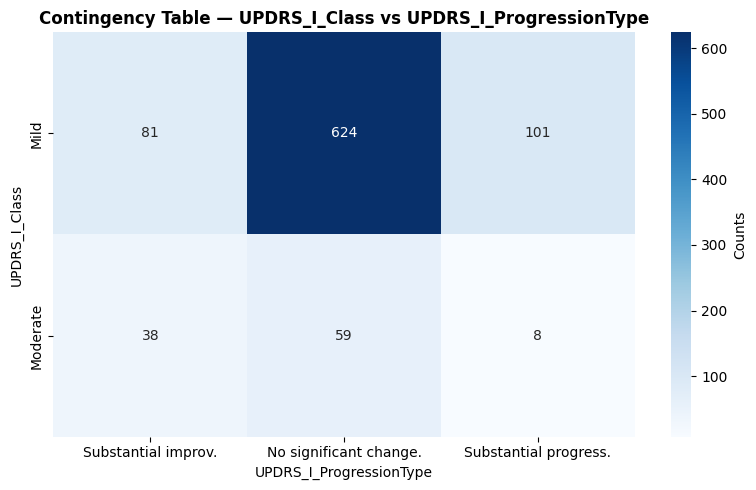

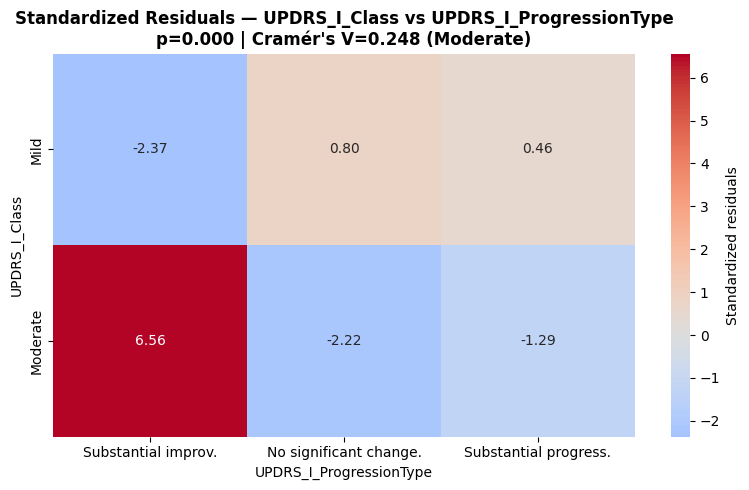


--------------------------------------------------------------------------------

Combination of UPDRS_I_Class and UPDRS_II_ProgressionType:

 Chi-square test for: UPDRS_I_Class vs UPDRS_II_ProgressionType

Chi² statistic = 1.607
p-value = 0.4477
Degrees of freedom = 2
Cramér's V = 0.042
Effect size: Weak
 🛑 No significant association (p ≥ 0.05)
    → No tables or heatmaps displayed.

--------------------------------------------------------------------------------

Combination of UPDRS_I_Class and UPDRS_III_ProgressionType:

 Chi-square test for: UPDRS_I_Class vs UPDRS_III_ProgressionType

Chi² statistic = 1.526
p-value = 0.4663
Degrees of freedom = 2
Cramér's V = 0.041
Effect size: Weak
 🛑 No significant association (p ≥ 0.05)
    → No tables or heatmaps displayed.

--------------------------------------------------------------------------------

Combination of UPDRS_II_Class and UPDRS_I_ProgressionType:

 Chi-square test for: UPDRS_II_Class vs UPDRS_I_ProgressionType

Chi² statistic

UPDRS_I_ProgressionType,Substantial improv.,No significant change.,Substantial progress.
UPDRS_II_Class,,,
Mild,95,598,86
Moderate,24,85,23


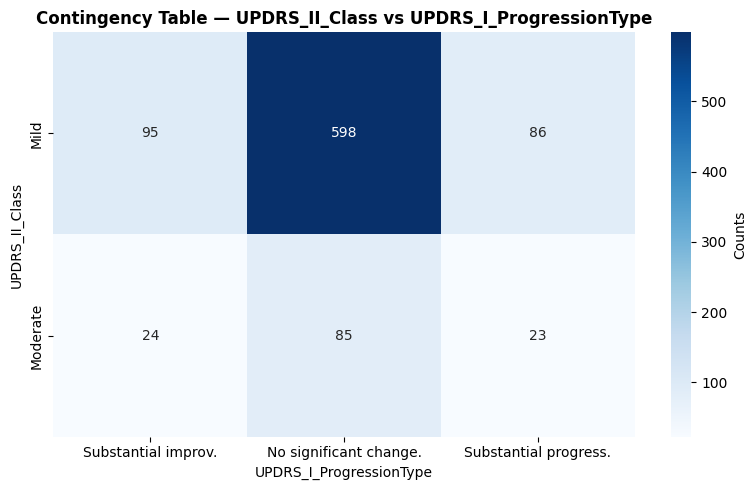

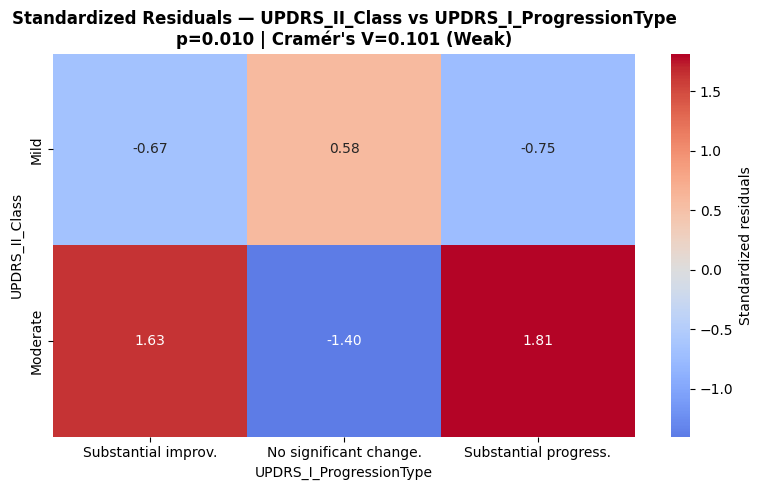


--------------------------------------------------------------------------------

Combination of UPDRS_II_Class and UPDRS_II_ProgressionType:

 Chi-square test for: UPDRS_II_Class vs UPDRS_II_ProgressionType

Chi² statistic = 39.631
p-value = 0.0000
Degrees of freedom = 2
Cramér's V = 0.209
Effect size: Moderate
 ✅ Significant association (p < 0.05)

Contingency table (ordered):


UPDRS_II_ProgressionType,Substantial improv.,No significant change.,Substantial progress.
UPDRS_II_Class,,,
Mild,86,627,66
Moderate,40,76,16


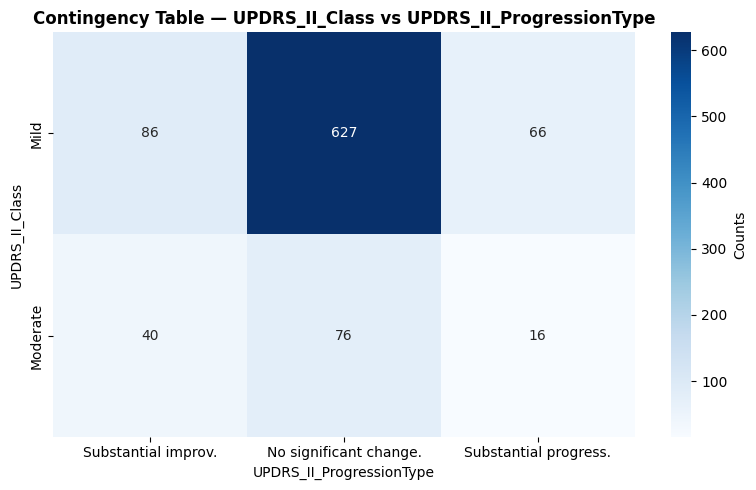

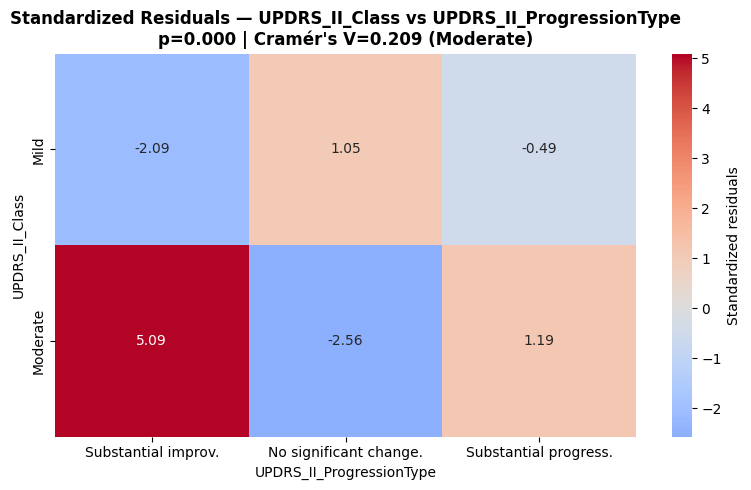


--------------------------------------------------------------------------------

Combination of UPDRS_II_Class and UPDRS_III_ProgressionType:

 Chi-square test for: UPDRS_II_Class vs UPDRS_III_ProgressionType

Chi² statistic = 6.039
p-value = 0.0488
Degrees of freedom = 2
Cramér's V = 0.081
Effect size: Weak
 ✅ Significant association (p < 0.05)

Contingency table (ordered):


UPDRS_III_ProgressionType,Substantial improv.,No significant change.,Substantial progress.
UPDRS_II_Class,,,
Mild,277,319,183
Moderate,49,41,42


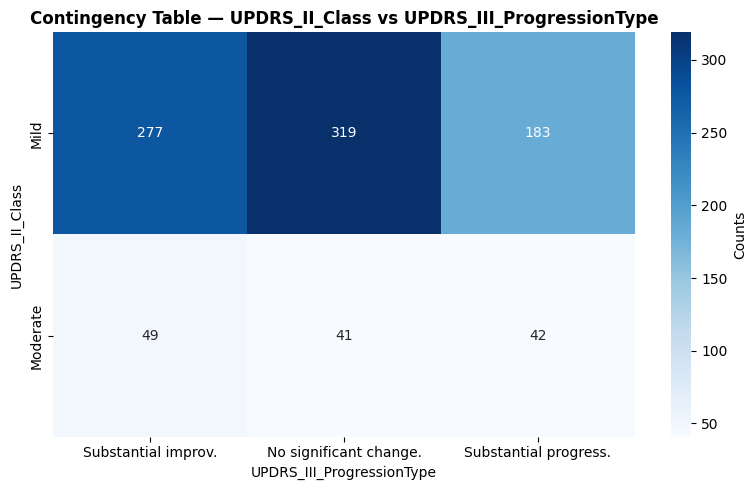

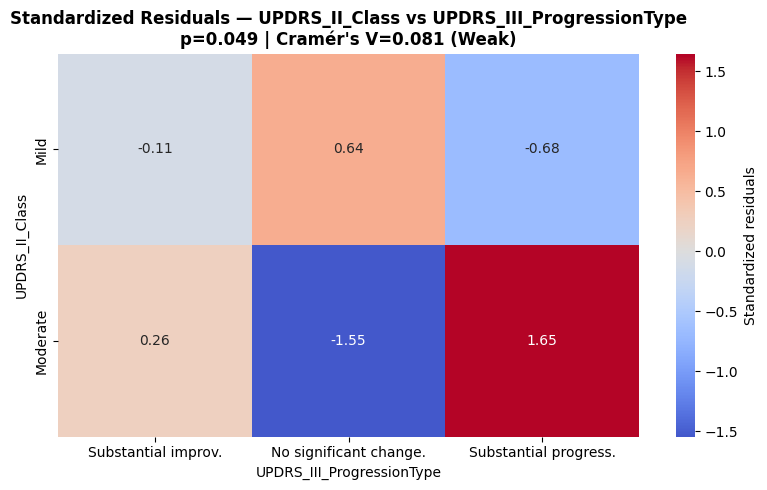


--------------------------------------------------------------------------------

Combination of UPDRS_III_Class and UPDRS_I_ProgressionType:

 Chi-square test for: UPDRS_III_Class vs UPDRS_I_ProgressionType

Chi² statistic = 0.832
p-value = 0.6598
Degrees of freedom = 2
Cramér's V = 0.030
Effect size: Weak
 🛑 No significant association (p ≥ 0.05)
    → No tables or heatmaps displayed.

--------------------------------------------------------------------------------

Combination of UPDRS_III_Class and UPDRS_II_ProgressionType:

 Chi-square test for: UPDRS_III_Class vs UPDRS_II_ProgressionType

Chi² statistic = 4.114
p-value = 0.1278
Degrees of freedom = 2
Cramér's V = 0.067
Effect size: Weak
 🛑 No significant association (p ≥ 0.05)
    → No tables or heatmaps displayed.

--------------------------------------------------------------------------------

Combination of UPDRS_III_Class and UPDRS_III_ProgressionType:

 Chi-square test for: UPDRS_III_Class vs UPDRS_III_ProgressionType

Chi²

UPDRS_III_ProgressionType,Substantial improv.,No significant change.,Substantial progress.
UPDRS_III_Class,,,
Mild,263,339,206
Moderate,63,21,19


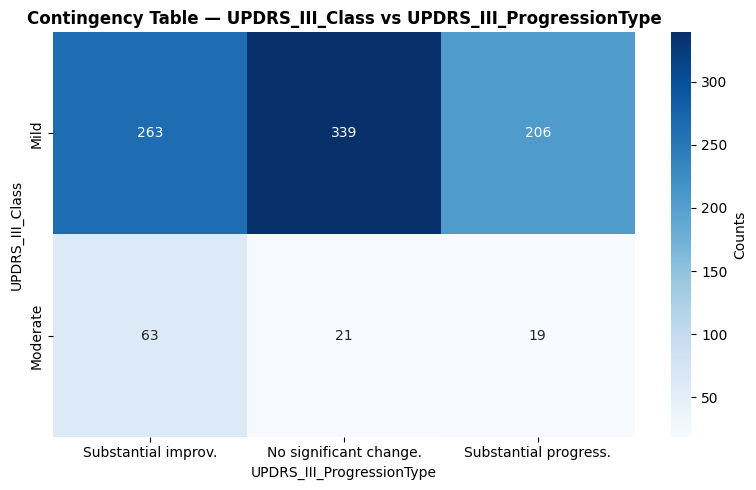

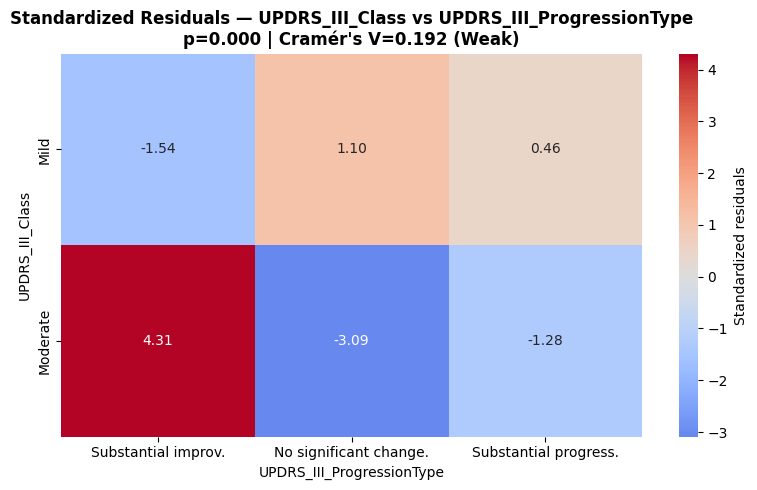


--------------------------------------------------------------------------------



In [125]:
from itertools import product

updrs_class = [
    'UPDRS_I_Class',
    'UPDRS_II_Class',
    'UPDRS_III_Class'
]

progression_types = [
    'UPDRS_I_ProgressionType',
    'UPDRS_II_ProgressionType',
    'UPDRS_III_ProgressionType'
]

pares = list(product(updrs_class, progression_types))

for combo in pares:
    print(f'Combination of {combo[0]} and {combo[1]}:')
    chi_square_heatmap(motor_data, combo[0], combo[1], order_1=['Mild','Moderate'], order_2=['Substantial improv.' ,'No significant change.','Substantial progress.'])

## UPDRS Progression - UPDRS 3 and UPDRS Total 

### ANOVA

Kruskal-Dunn analysis for MDS-UPDRS Part III Total Score by UPDRS_I_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


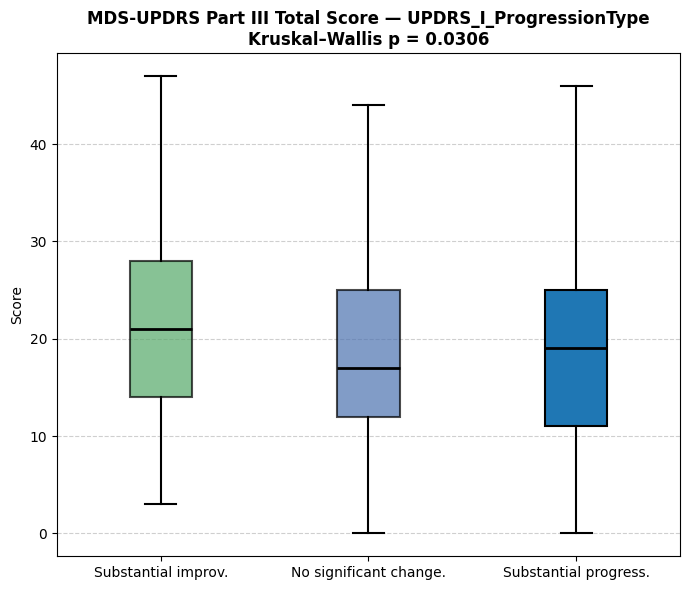


=== KRUSKAL–WALLIS RESULTS ===
MDS-UPDRS Part III Total Score: H = 6.975, p = 3.0584e-02  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for MDS-UPDRS Part III Total Score ===


,No significant change.,Substantial improv.,Substantial progress.
No significant change.,1.0000,0.0399,0.6194
Substantial improv.,0.0399,1.0000,1.0000
Substantial progress.,0.6194,1.0000,1.0000


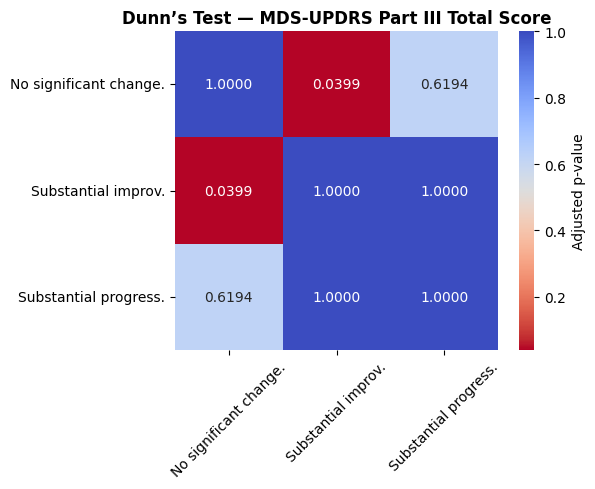

Kruskal-Dunn analysis for MDS-UPDRS Total Score by UPDRS_I_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


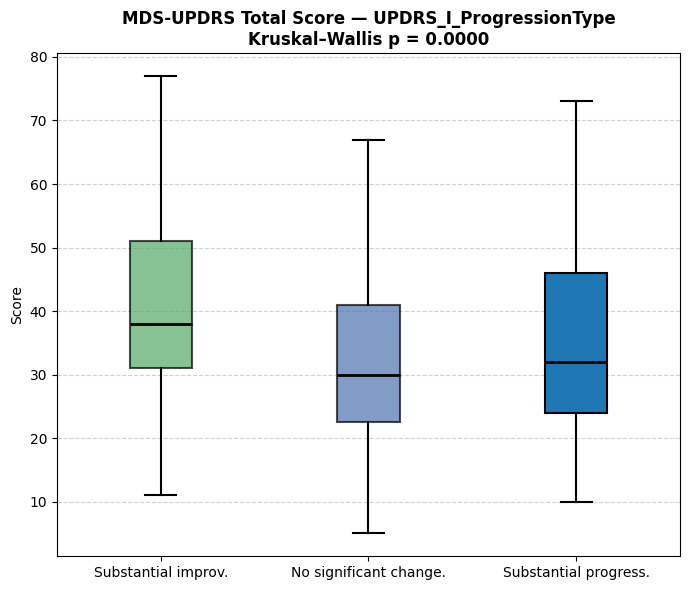


=== KRUSKAL–WALLIS RESULTS ===
MDS-UPDRS Total Score: H = 30.974, p = 1.8798e-07  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for MDS-UPDRS Total Score ===


,No significant change.,Substantial improv.,Substantial progress.
No significant change.,1.0000,0.0000,0.4948
Substantial improv.,0.0000,1.0000,0.0065
Substantial progress.,0.4948,0.0065,1.0000


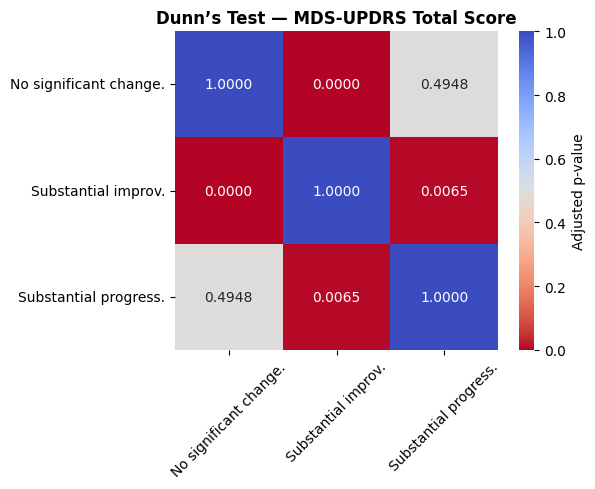

Kruskal-Dunn analysis for MDS-UPDRS Part III Total Score by UPDRS_II_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


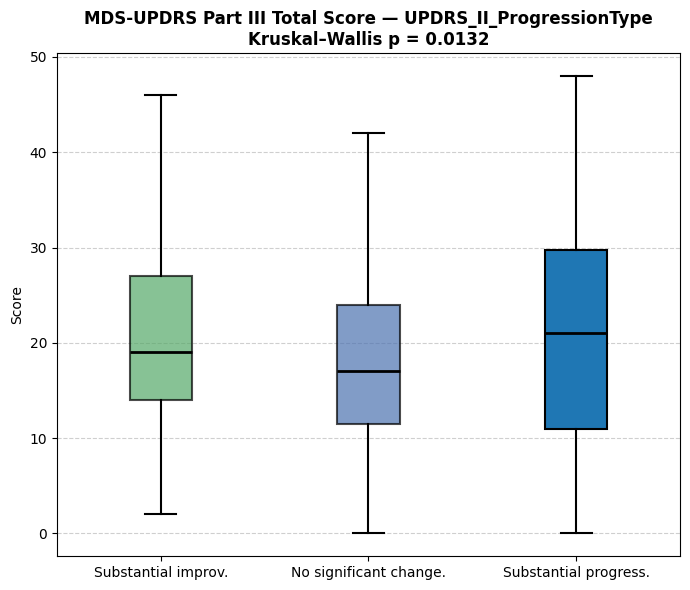


=== KRUSKAL–WALLIS RESULTS ===
MDS-UPDRS Part III Total Score: H = 8.649, p = 1.3240e-02  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for MDS-UPDRS Part III Total Score ===


,No significant change.,Substantial improv.,Substantial progress.
No significant change.,1.0000,0.0364,0.1977
Substantial improv.,0.0364,1.0000,1.0000
Substantial progress.,0.1977,1.0000,1.0000


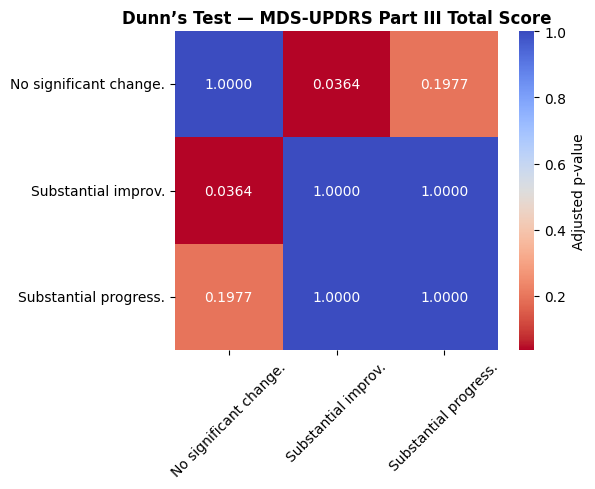

Kruskal-Dunn analysis for MDS-UPDRS Total Score by UPDRS_II_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


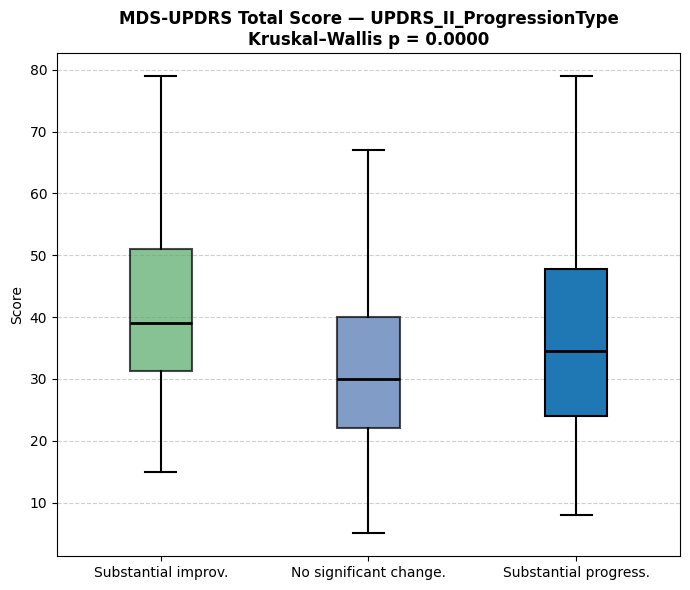


=== KRUSKAL–WALLIS RESULTS ===
MDS-UPDRS Total Score: H = 43.018, p = 4.5578e-10  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for MDS-UPDRS Total Score ===


,No significant change.,Substantial improv.,Substantial progress.
No significant change.,1.0000,0.0000,0.0637
Substantial improv.,0.0000,1.0000,0.0421
Substantial progress.,0.0637,0.0421,1.0000


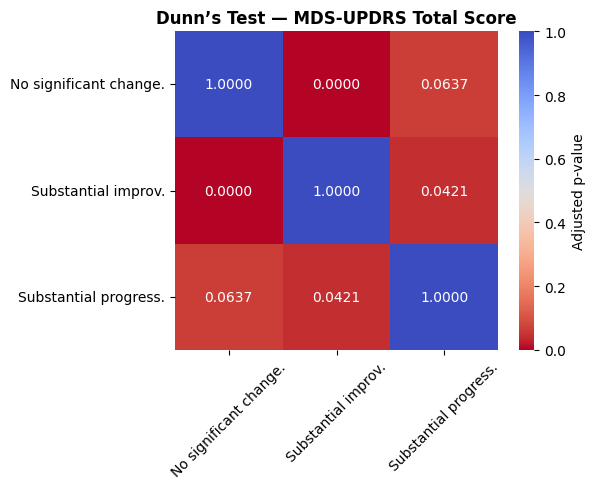

Kruskal-Dunn analysis for MDS-UPDRS Part III Total Score by UPDRS_III_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


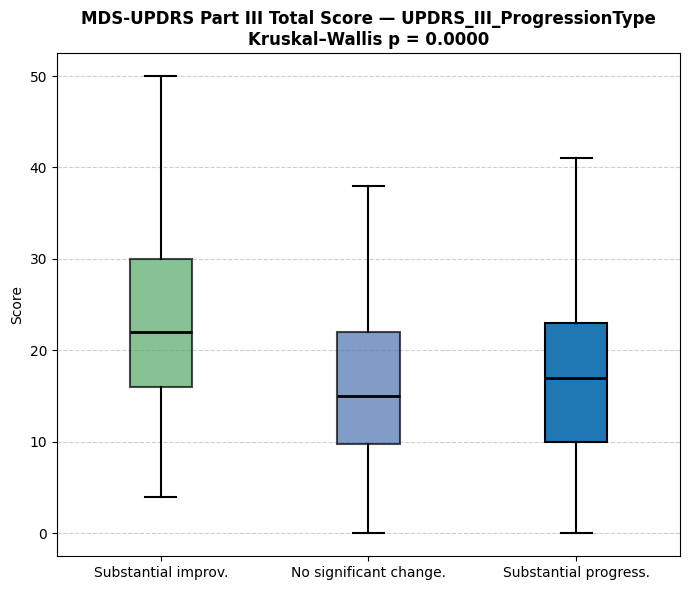


=== KRUSKAL–WALLIS RESULTS ===
MDS-UPDRS Part III Total Score: H = 90.476, p = 2.2562e-20  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for MDS-UPDRS Part III Total Score ===


,No significant change.,Substantial improv.,Substantial progress.
No significant change.,1.000,0.0,0.301
Substantial improv.,0.000,1.0,0.000
Substantial progress.,0.301,0.0,1.000


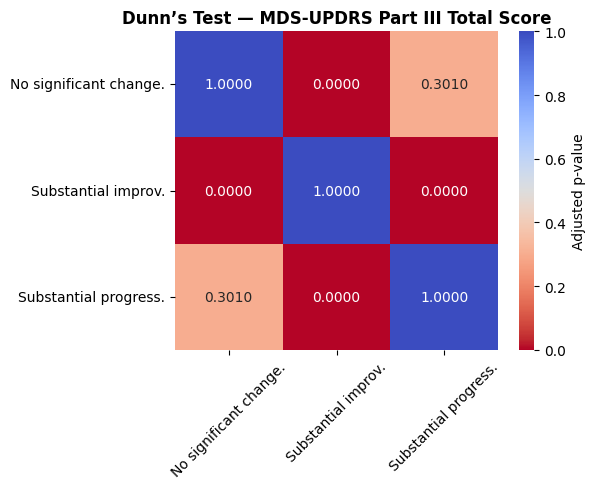

Kruskal-Dunn analysis for MDS-UPDRS Total Score by UPDRS_III_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


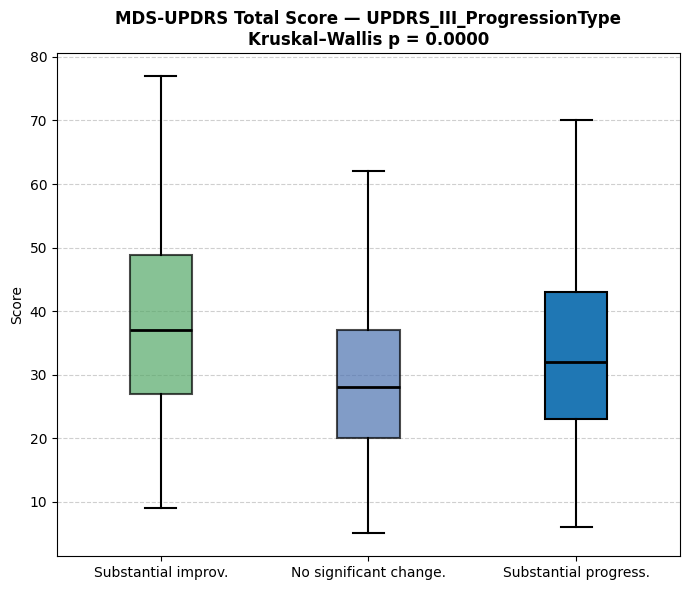


=== KRUSKAL–WALLIS RESULTS ===
MDS-UPDRS Total Score: H = 57.486, p = 3.2894e-13  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for MDS-UPDRS Total Score ===


,No significant change.,Substantial improv.,Substantial progress.
No significant change.,1.0000,0.0000,0.0096
Substantial improv.,0.0000,1.0000,0.0004
Substantial progress.,0.0096,0.0004,1.0000


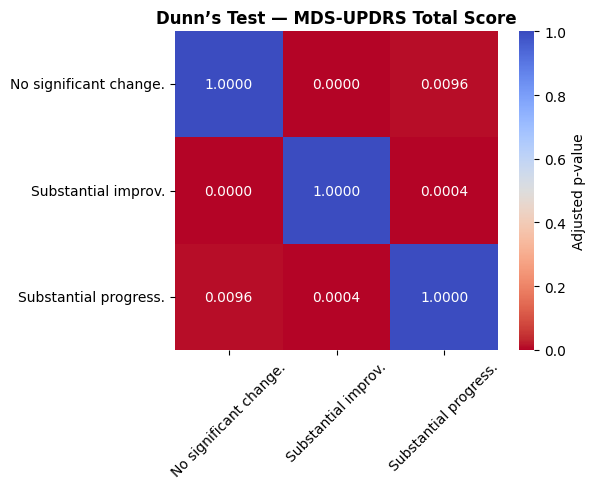

In [126]:
progression_types = [
    'UPDRS_I_ProgressionType',
    'UPDRS_II_ProgressionType',
    'UPDRS_III_ProgressionType'
]


for col in progression_types:
    for score_col in ['MDS-UPDRS Part III Total Score','MDS-UPDRS Total Score']:
        print(f'Kruskal-Dunn analysis for {score_col} by {col}:')
        kruskal_dunn_by_class(motor_data, col, [score_col], class_order=['Substantial improv.' ,'No significant change.','Substantial progress.'])


### Chi2


 Chi-square test for: UPDRS_III_Class vs UPDRS_III_ProgressionType

Chi² statistic = 33.495
p-value = 0.0000
Degrees of freedom = 2
Cramér's V = 0.192
Effect size: Weak
 ✅ Significant association (p < 0.05)

Contingency table (ordered):


UPDRS_III_ProgressionType,Substantial improv.,No significant change.,Substantial progress.
UPDRS_III_Class,,,
Mild,263,339,206
Moderate,63,21,19


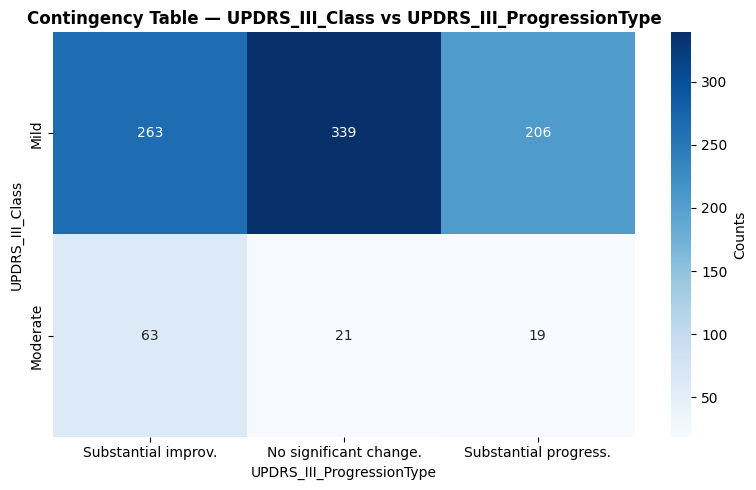

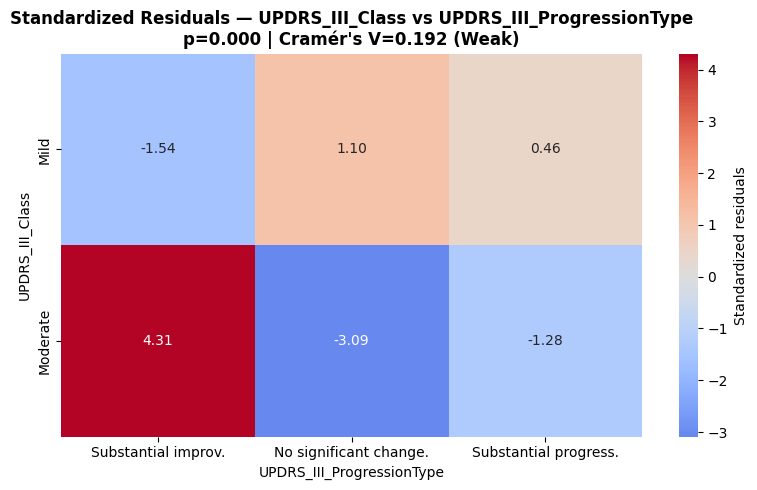


--------------------------------------------------------------------------------



In [127]:
chi_square_heatmap(motor_data,'UPDRS_III_Class' , 'UPDRS_III_ProgressionType', order_1=['Mild','Moderate'], order_2=['Substantial improv.' ,'No significant change.','Substantial progress.'])

### UPRDS VS H&Y

In [128]:
motor_data.columns

Index(['PATNO', 'Visit ID',
       'MDS-UPDRS Part I (Patient Questionnaire) Total Score',
       'MDS-UPDRS Part II Total Score', 'Does participant have DBS',
       'MDS-UPDRS Part III Total Score', '3.21 HOEHN AND YAHR STAGE',
       'MDS-UPDRS Part IV Total Score', 'DBS_Transition_Visit',
       'DBS_Post_Transition', 'SCHWAB & ENGLAND ADL',
       'MDS-UPDRS Total Score 1YearProg', 'UPDRS_III_1YearProg',
       'MDS-UPDRS Total Score', 'Δ TOTAL_UPDRS_1Y', 'Δ UPDRS_I_1Y',
       'Δ UPDRS_II_1Y', 'Δ UPDRS_III_1Y', 'Δ UPDRS_IV_1Y', 'UPDRS_I_Class',
       'UPDRS_II_Class', 'UPDRS_III_Class', 'UPDRS_IV_Class',
       'UPDRS_I_ProgressionType', 'UPDRS_II_ProgressionType',
       'UPDRS_III_ProgressionType'],
      dtype='object')

Kruskal-Dunn analysis for MDS-UPDRS Part III Total Score by H&Y Stage:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


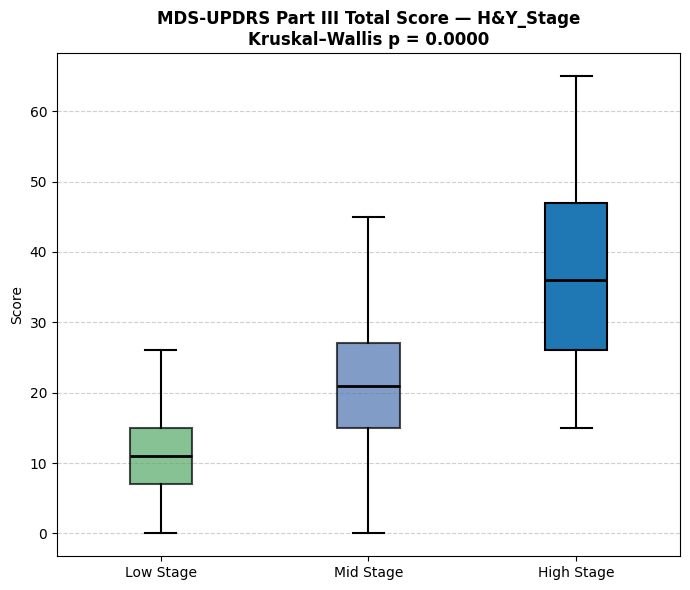


=== KRUSKAL–WALLIS RESULTS ===
MDS-UPDRS Part III Total Score: H = 249.647, p = 6.1634e-55  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for MDS-UPDRS Part III Total Score ===


,High Stage,Low Stage,Mid Stage
High Stage,1.0000,0.0,0.0001
Low Stage,0.0000,1.0,0.0000
Mid Stage,0.0001,0.0,1.0000


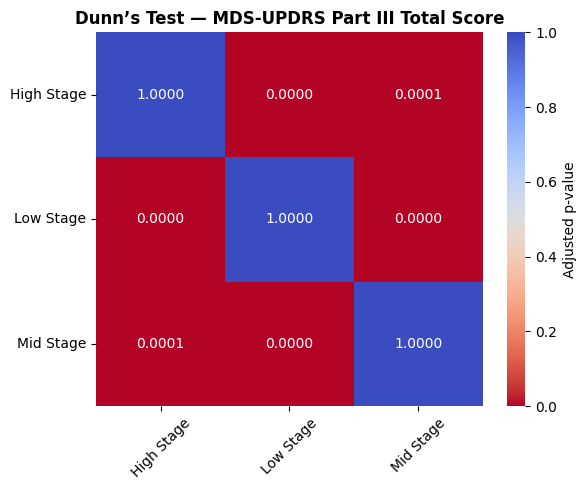

Kruskal-Dunn analysis for Δ UPDRS_III_1Y by H&Y Stage:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


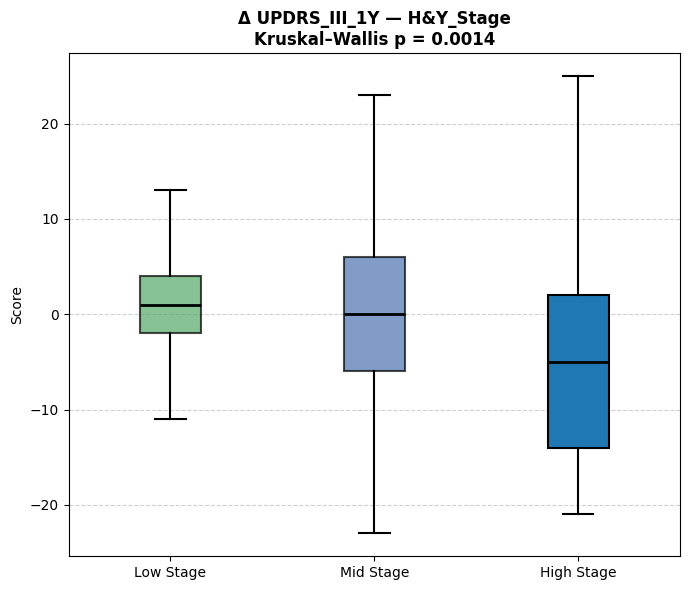


=== KRUSKAL–WALLIS RESULTS ===
Δ UPDRS_III_1Y: H = 13.170, p = 1.3809e-03  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for Δ UPDRS_III_1Y ===


,High Stage,Low Stage,Mid Stage
High Stage,1.0000,0.0071,0.0845
Low Stage,0.0071,1.0000,0.0216
Mid Stage,0.0845,0.0216,1.0000


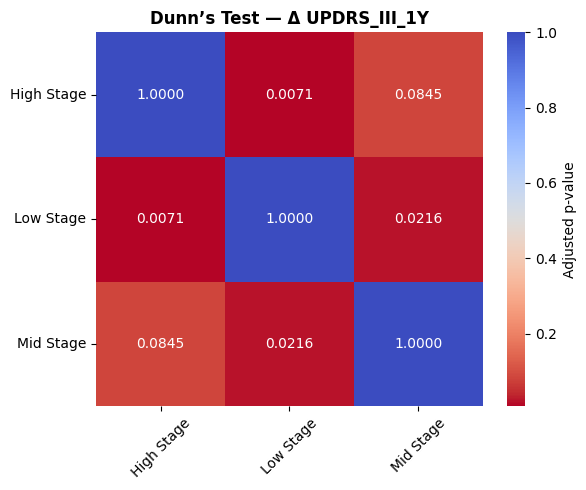

In [129]:
motor_data['H&Y_Stage'] = motor_data['3.21 HOEHN AND YAHR STAGE'].replace({
    0: 'Low Stage',
    1: 'Low Stage',
    2: 'Mid Stage',
    3: 'High Stage',
    4: 'High Stage'
})

relvant_cols=['MDS-UPDRS Part III Total Score', 'Δ UPDRS_III_1Y']
for col in relvant_cols:
    print(f'Kruskal-Dunn analysis for {col} by H&Y Stage:')
    kruskal_dunn_by_class(motor_data, 'H&Y_Stage', [col], class_order=['Low Stage','Mid Stage','High Stage'])

# Subject data

In [130]:
subject_data = pd.read_csv('/Users/fserracrespi/Desktop/PD_Project_UofL/PD_DATA/PD_1y_progress_DATA/Data_Subject_1Year_12SEP2025.csv')
subject_data.drop(columns=['Unnamed: 0','DATE_VISIT','Pink1 Mutation at Enrollment'], inplace=True)
print(subject_data.columns)
print(subject_data.shape)
subject_data=subject_data.merge(motor_data[['PATNO','Visit ID','UPDRS_I_ProgressionType','UPDRS_II_ProgressionType','UPDRS_III_ProgressionType','UPDRS_I_Class', 'UPDRS_II_Class', 'UPDRS_III_Class']], on=['PATNO','Visit ID'], how='inner')
print(subject_data.shape)
subject_data.head(3)
print(subject_data.columns)
# mutation
subject_data['Has a genetic mutation'] = subject_data[['Parkin Mutation at Enrollment',
       'LRRK2 Mutation at Enrollment', 'SNCA Mutation at Enrollment',
       'GBA Mutation at Enrollment']].sum(axis=1)
       
subject_data['Has a genetic mutation'] = subject_data['Has a genetic mutation'].apply(lambda x: True if x>0 else False)

#sex
subject_data['Sex of participant at birth']=subject_data['Sex of participant at birth'].apply(lambda x: 'MALE' if x==1 else 'FEMALE')


Index(['PATNO', 'Visit ID',
       'MDS-UPDRS Part I (Patient Questionnaire) Total Score',
       'MDS-UPDRS Part II Total Score', 'MDS-UPDRS Part III Total Score',
       'MDS-UPDRS Part IV Total Score', 'Height (cm)', 'Weight (kg)',
       'Temperature (Celsius)', 'Supine BP - systolic (mmHg)',
       'Supine BP - diastolic (mmHg)', 'Supine heart rate (bpm)',
       'Standing BP - systolic (mmHg)', 'Standing BP - diastolic (mmHg)',
       'Standing heart rate (bpm)', 'Sporadic PD at Enrollment',
       'RBD at Enrollment', 'Parkin Mutation at Enrollment',
       'LRRK2 Mutation at Enrollment', 'SNCA Mutation at Enrollment',
       'GBA Mutation at Enrollment', 'Birth Date',
       'Sex of participant at birth', 'Identify self as Asian',
       'Identify self as Black/African American',
       'Identify self as Hawaiian/Other Pacific Islander',
       'Identify self as American Indian/Alaska Native',
       'Identify self as White',
       'Number of years of education reported by the

## UPDRS - Sex


 Chi-square test for: Has a genetic mutation vs Sex of participant at birth

Chi² statistic = 20.199
p-value = 0.0000
Degrees of freedom = 1
Cramér's V = 0.151
Effect size: Weak
 ✅ Significant association (p < 0.05)

Contingency table (ordered):


Sex of participant at birth,FEMALE,MALE
Has a genetic mutation,,
False,195,415
True,143,158


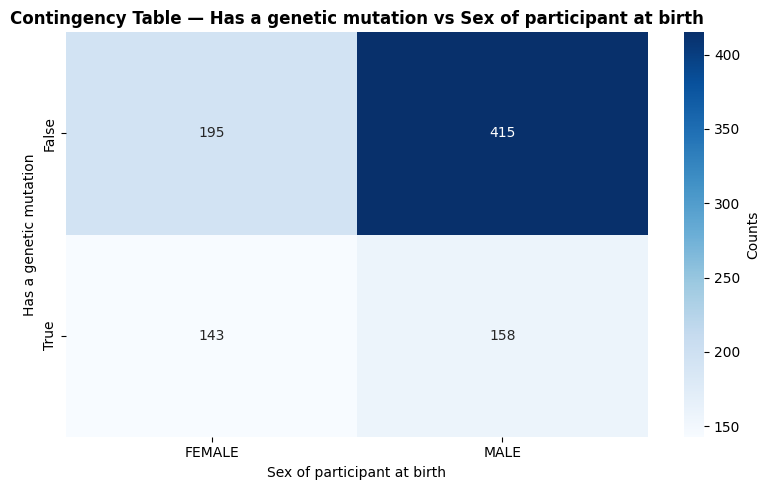

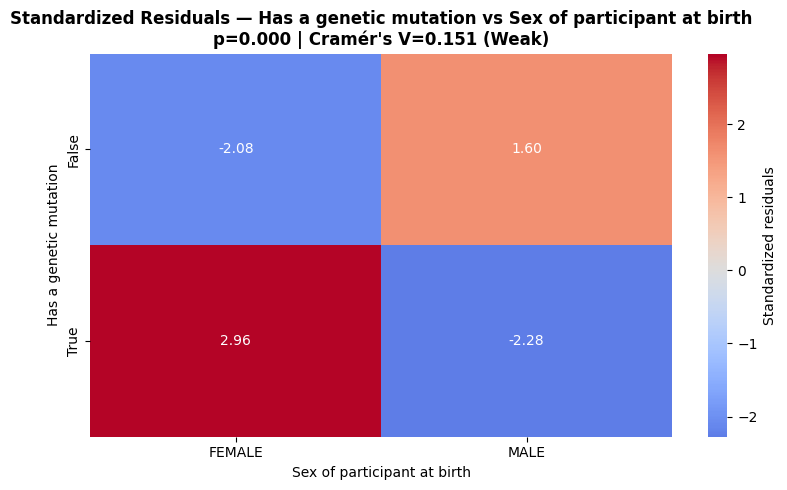


--------------------------------------------------------------------------------



In [131]:
chi_square_heatmap(subject_data,'Has a genetic mutation', 'Sex of participant at birth', order_1=None, order_2=None)

/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


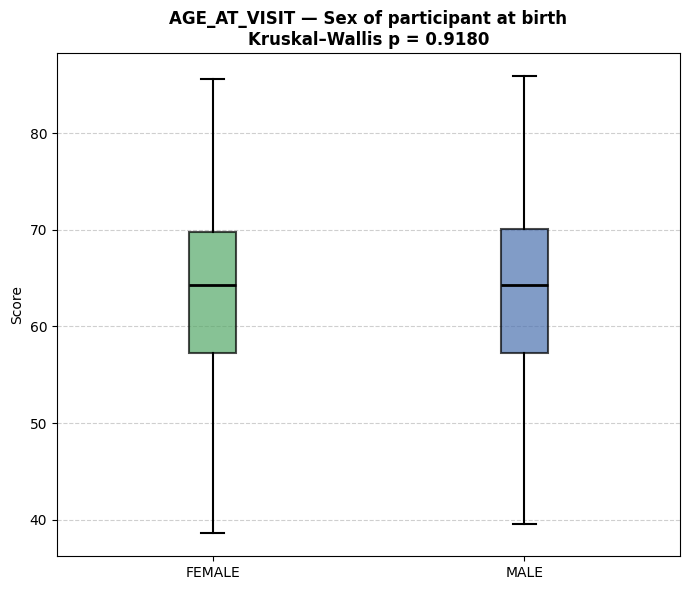


=== KRUSKAL–WALLIS RESULTS ===
AGE_AT_VISIT: H = 0.011, p = 9.1800e-01  --> 🛑 Not significant


({'AGE_AT_VISIT': (0.010600323858019433, 0.9179964047388711)}, {})

In [132]:
kruskal_dunn_by_class(subject_data, 'Sex of participant at birth', ['AGE_AT_VISIT'], class_order=None)

Kruskal-Dunn analysis for Age by MDS-UPDRS Part III Total Score:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


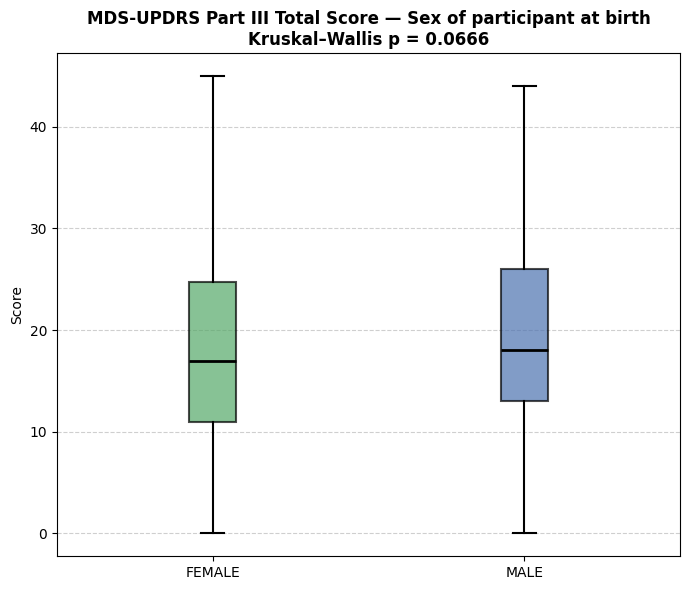


=== KRUSKAL–WALLIS RESULTS ===
MDS-UPDRS Part III Total Score: H = 3.365, p = 6.6615e-02  --> 🛑 Not significant
Kruskal-Dunn analysis for Age by MDS-UPDRS Total Score:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


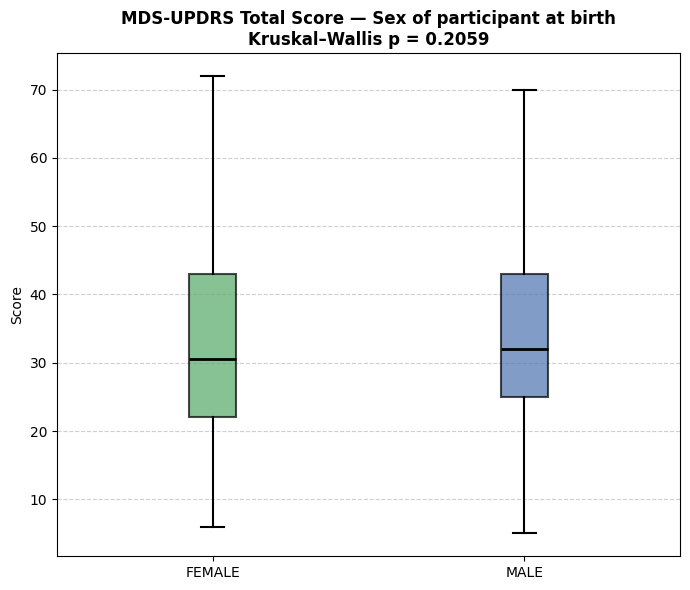


=== KRUSKAL–WALLIS RESULTS ===
MDS-UPDRS Total Score: H = 1.600, p = 2.0591e-01  --> 🛑 Not significant
Kruskal-Dunn analysis for Age by Δ UPDRS_III_1Y:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


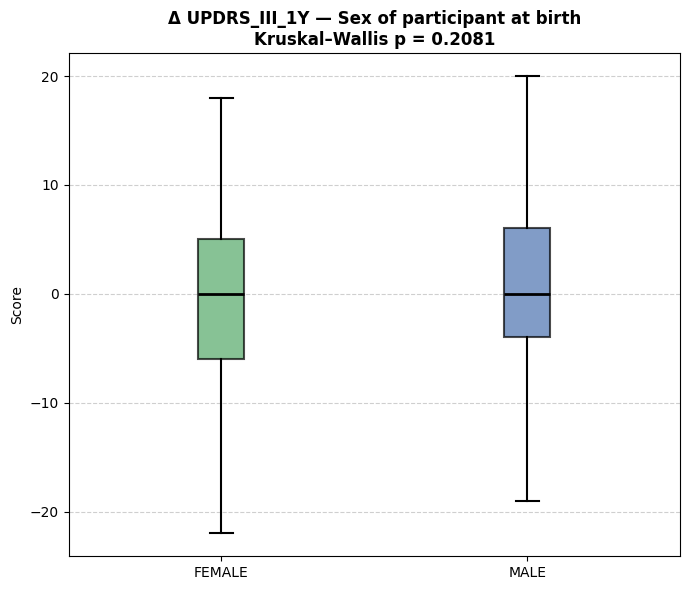


=== KRUSKAL–WALLIS RESULTS ===
Δ UPDRS_III_1Y: H = 1.585, p = 2.0810e-01  --> 🛑 Not significant


In [133]:
relvant_cols=['MDS-UPDRS Part III Total Score','MDS-UPDRS Total Score','Δ UPDRS_III_1Y']
for col in relvant_cols:
    print(f'Kruskal-Dunn analysis for Age by {col}:')
    kruskal_dunn_by_class(subject_data, 'Sex of participant at birth', [col], class_order=None)

## UPDRS - Race

In [134]:
relvant_cols=['UPDRS_I_Class','UPDRS_II_Class','UPDRS_III_Class','UPDRS_III_ProgressionType']
for col in relvant_cols:
    print(f' analysis for Mutation by {col}:')
    chi_square_heatmap(subject_data,'Identify self as White' , col , order_1=None, order_2=None)

 analysis for Mutation by UPDRS_I_Class:

 Chi-square test for: Identify self as White vs UPDRS_I_Class

Chi² statistic = 3.502
p-value = 0.0613
Degrees of freedom = 1
Cramér's V = 0.071
Effect size: Weak
 🛑 No significant association (p ≥ 0.05)
    → No tables or heatmaps displayed.

--------------------------------------------------------------------------------

 analysis for Mutation by UPDRS_II_Class:

 Chi-square test for: Identify self as White vs UPDRS_II_Class

Chi² statistic = 0.611
p-value = 0.4346
Degrees of freedom = 1
Cramér's V = 0.034
Effect size: Weak
 🛑 No significant association (p ≥ 0.05)
    → No tables or heatmaps displayed.

--------------------------------------------------------------------------------

 analysis for Mutation by UPDRS_III_Class:

 Chi-square test for: Identify self as White vs UPDRS_III_Class

Chi² statistic = 0.131
p-value = 0.7173
Degrees of freedom = 1
Cramér's V = 0.021
Effect size: Weak
 🛑 No significant association (p ≥ 0.05)
    → No tab

## UPDRS Class - Age Anova

Kruskal-Dunn analysis for Age by UPDRS_I_Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


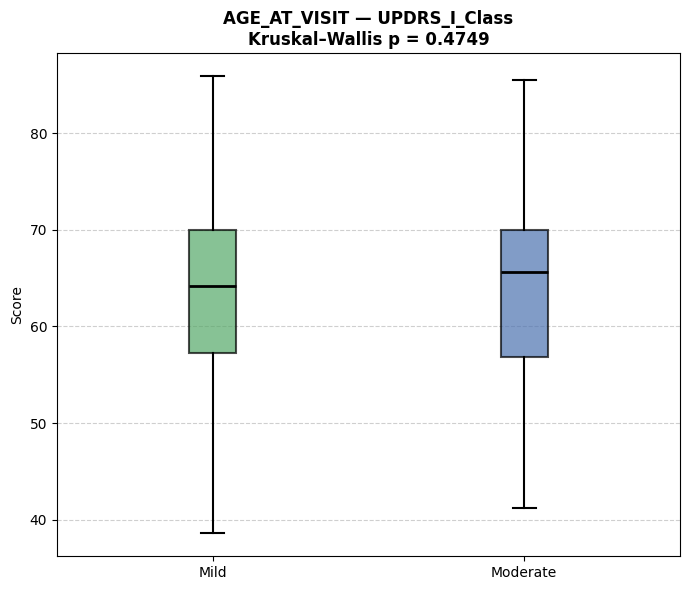


=== KRUSKAL–WALLIS RESULTS ===
AGE_AT_VISIT: H = 0.510, p = 4.7493e-01  --> 🛑 Not significant
Kruskal-Dunn analysis for Age by UPDRS_II_Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


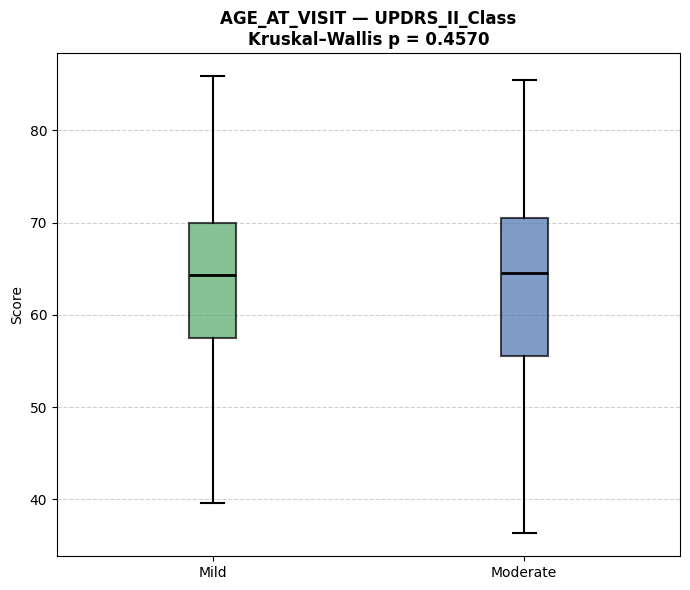


=== KRUSKAL–WALLIS RESULTS ===
AGE_AT_VISIT: H = 0.553, p = 4.5695e-01  --> 🛑 Not significant
Kruskal-Dunn analysis for Age by UPDRS_III_Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


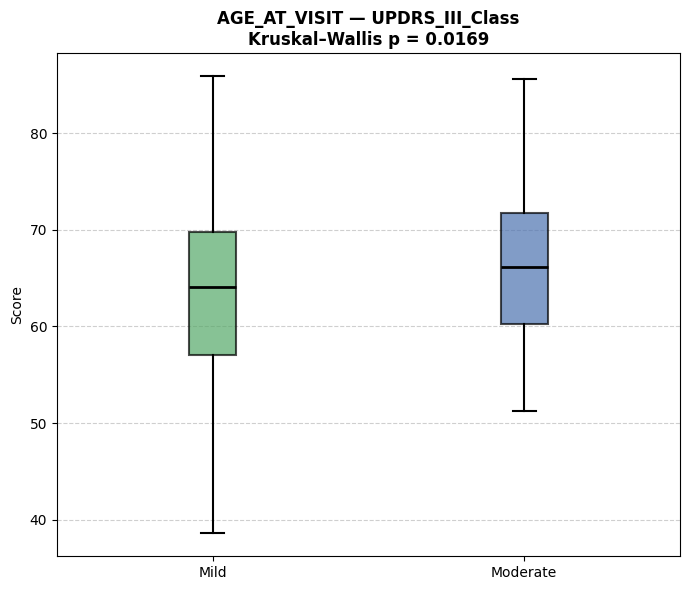


=== KRUSKAL–WALLIS RESULTS ===
AGE_AT_VISIT: H = 5.706, p = 1.6907e-02  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for AGE_AT_VISIT ===


,Mild,Moderate
Mild,1.0000,0.0169
Moderate,0.0169,1.0000


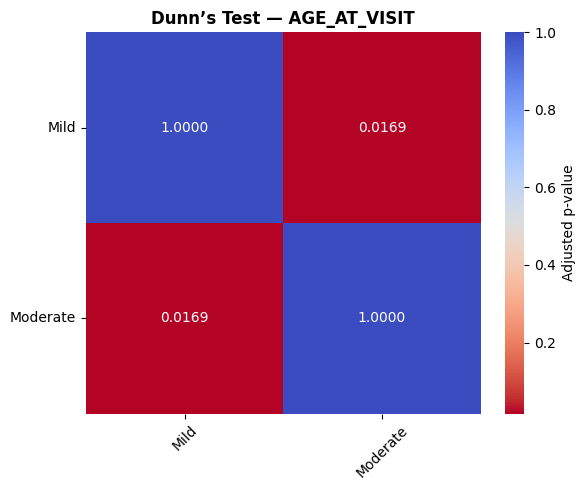

In [135]:
for type in updrs_class:
    print(f'Kruskal-Dunn analysis for Age by {type}:')
    kruskal_dunn_by_class(subject_data, type, ['AGE_AT_VISIT'], class_order=['Mild','Moderate'])


## UPDRS ProgressionType-Age Anova

Kruskal-Dunn analysis for Age by UPDRS_I_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


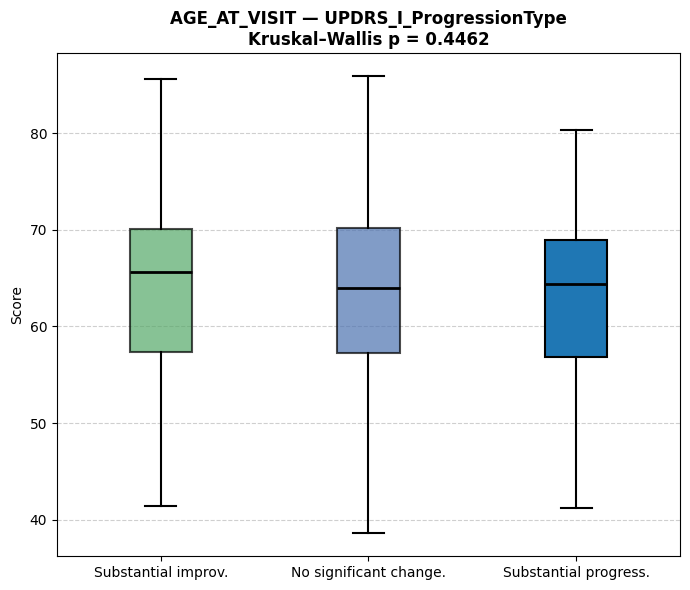


=== KRUSKAL–WALLIS RESULTS ===
AGE_AT_VISIT: H = 1.614, p = 4.4616e-01  --> 🛑 Not significant
Kruskal-Dunn analysis for Age by UPDRS_II_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


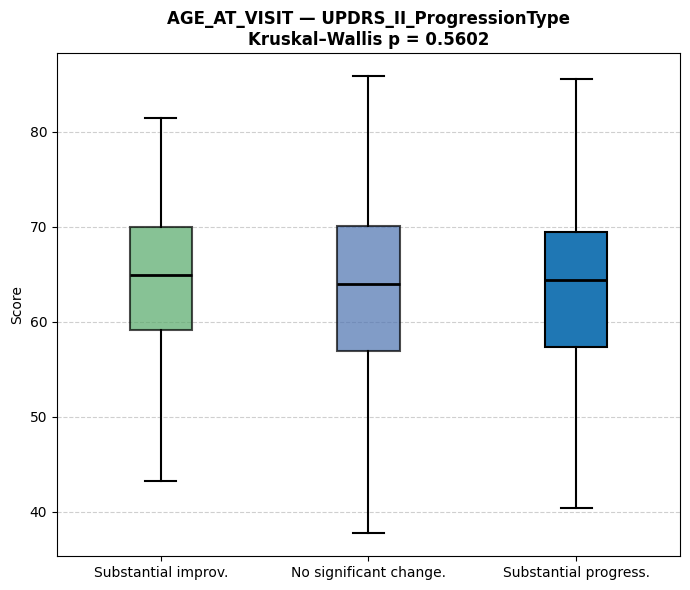


=== KRUSKAL–WALLIS RESULTS ===
AGE_AT_VISIT: H = 1.159, p = 5.6024e-01  --> 🛑 Not significant
Kruskal-Dunn analysis for Age by UPDRS_III_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


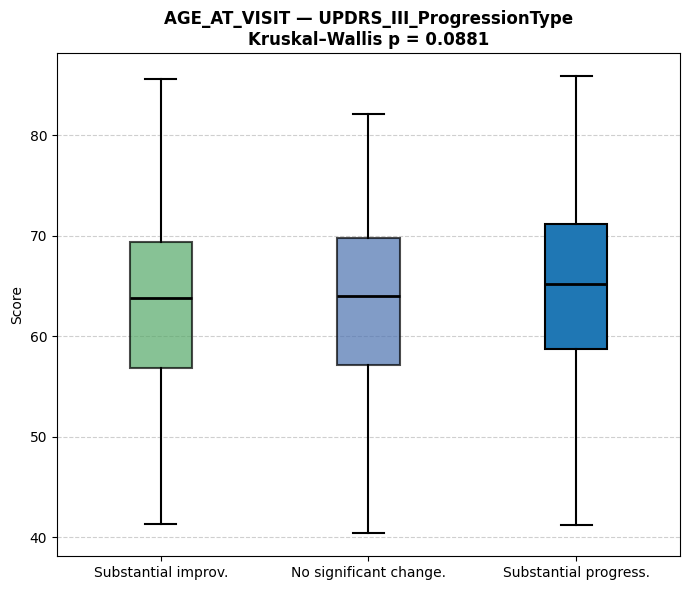


=== KRUSKAL–WALLIS RESULTS ===
AGE_AT_VISIT: H = 4.859, p = 8.8074e-02  --> 🛑 Not significant


In [136]:
for type in progression_types:
    print(f'Kruskal-Dunn analysis for Age by {type}:')
    kruskal_dunn_by_class(subject_data, type, ['AGE_AT_VISIT'], class_order=['Substantial improv.' ,'No significant change.','Substantial progress.'])

# COGNITIVE DATA

In [137]:
cognitive_data = pd.read_csv('/Users/fserracrespi/Desktop/PD_Project_UofL/PD_DATA/PD_1y_progress_DATA/Data_Cognitive_1Year_12SEP2025.csv')
cognitive_data.drop(columns=['Unnamed: 0'],inplace=True)
cognitive_data.sort_values(by=['PATNO','Visit ID'],inplace=True)
# Aplicar la clasificación al dataframe
cognitive_data = clasificar_updrs_thresholds(cognitive_data)

cognitive_data['UPDRS_I_ProgressionType'] = cognitive_data['Δ UPDRS_I_1Y'].apply(lambda delta: categorize_progression(delta, -3,3 ))
cognitive_data['UPDRS_II_ProgressionType'] = cognitive_data['Δ UPDRS_II_1Y'].apply(lambda delta: categorize_progression(delta, -3,5 ))
cognitive_data['UPDRS_III_ProgressionType'] = cognitive_data['Δ UPDRS_III_1Y'].apply(lambda delta: categorize_progression(delta, -3,5 ))

cognitive_data.head(3)

,PATNO,Visit ID,Letter-Number Sequencing Scaled Score,STAI PART I Score,STAI PART II Score,STAI Total Score,MDS-UPDRS Part I (Patient Questionnaire) Total Score,MDS-UPDRS Part II Total Score,MDS-UPDRS Part III Total Score,MDS-UPDRS Part IV Total Score,...,Δ UPDRS_II_1Y,Δ UPDRS_III_1Y,Δ UPDRS_IV_1Y,UPDRS_I_Class,UPDRS_II_Class,UPDRS_III_Class,UPDRS_IV_Class,UPDRS_I_ProgressionType,UPDRS_II_ProgressionType,UPDRS_III_ProgressionType
728,3001,V10_V12,18,53.0,50.0,103.0,6,5.0,35,0.0,...,-1.0,-9,0.0,Mild,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.
729,3003,V10_V12,8,51.0,42.0,93.0,9,10.0,53,0.0,...,-1.0,-14,0.0,Mild,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.
730,3010,V10_V12,12,44.0,40.0,84.0,11,16.0,18,7.0,...,4.0,16,-2.0,Moderate,Moderate,Mild,Moderate,No significant change.,No significant change.,Substantial progress.


## MoCA 

In [138]:
moca_df = cognitive_data[['PATNO','Visit ID','MoCA Total Score','MDS-UPDRS Total Score',
                            'MDS-UPDRS Part I (Patient Questionnaire) Total Score',
                            'MDS-UPDRS Part II Total Score',
                            'MDS-UPDRS Part III Total Score',
                            'MDS-UPDRS Total Score 1YearProg',
                            'UPDRS_III_1YearProg',
                            'MDS-UPDRS Total Score',
                            'Δ TOTAL_UPDRS_1Y',
                            'Δ UPDRS_I_1Y',
                            'Δ UPDRS_II_1Y',
                            'Δ UPDRS_III_1Y',
                            'Δ UPDRS_IV_1Y',
                            'UPDRS_I_Class',
                            'UPDRS_II_Class',
                            'UPDRS_III_Class',
                            'UPDRS_IV_Class',
                            'UPDRS_I_ProgressionType',
                            'UPDRS_II_ProgressionType',
                            'UPDRS_III_ProgressionType']]

moca_df['MoCA_Class'] = moca_df['MoCA Total Score'].apply(lambda x: 'Normal' if x>=26 else 'MCI')
moca_df.head(3)


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/389095716.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  moca_df['MoCA_Class'] = moca_df['MoCA Total Score'].apply(lambda x: 'Normal' if x>=26 else 'MCI')


,PATNO,Visit ID,MoCA Total Score,MDS-UPDRS Total Score,MDS-UPDRS Part I (Patient Questionnaire) Total Score,MDS-UPDRS Part II Total Score,MDS-UPDRS Part III Total Score,MDS-UPDRS Total Score 1YearProg,UPDRS_III_1YearProg,MDS-UPDRS Total Score,...,Δ UPDRS_III_1Y,Δ UPDRS_IV_1Y,UPDRS_I_Class,UPDRS_II_Class,UPDRS_III_Class,UPDRS_IV_Class,UPDRS_I_ProgressionType,UPDRS_II_ProgressionType,UPDRS_III_ProgressionType,MoCA_Class
728,3001,V10_V12,29,46.0,6,5.0,35,37.0,26,46.0,...,-9,0.0,Mild,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.,Normal
729,3003,V10_V12,28,72.0,9,10.0,53,59.0,39,72.0,...,-14,0.0,Mild,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.,Normal
730,3010,V10_V12,29,52.0,11,16.0,18,70.0,34,52.0,...,16,-2.0,Moderate,Moderate,Mild,Moderate,No significant change.,No significant change.,Substantial progress.,Normal


### MoCA vs AGE

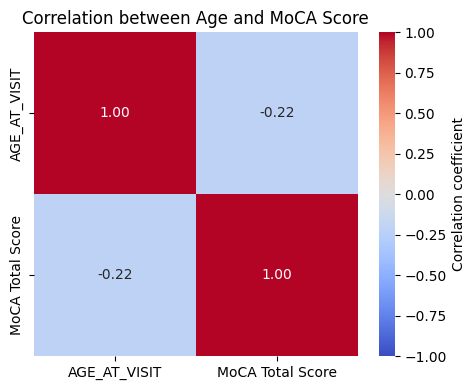

In [139]:
age_analysis=moca_df.merge(subject_data[['PATNO','Visit ID','AGE_AT_VISIT','Sex of participant at birth']], on=['PATNO','Visit ID'], how='inner')
age_analysis=age_analysis[['PATNO','Visit ID','AGE_AT_VISIT','MoCA_Class','MoCA Total Score','Sex of participant at birth']]

corr = age_analysis[['AGE_AT_VISIT', 'MoCA Total Score']].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={"label": "Correlation coefficient"}
)

plt.title("Correlation between Age and MoCA Score")
plt.tight_layout()
plt.show()

### UPDRS Class - MoCA

In [140]:
moca_df['UPDRS_III_Class'].value_counts()

UPDRS_III_Class
Mild        808
Moderate    103
Name: count, dtype: int64

Kruskal-Dunn analysis for MoCA Total Score by UPDRS_I_Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


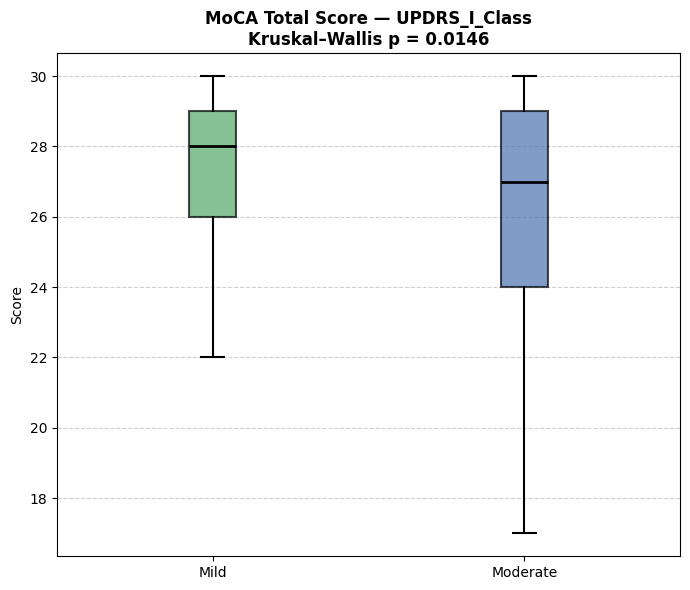


=== KRUSKAL–WALLIS RESULTS ===
MoCA Total Score: H = 5.965, p = 1.4589e-02  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for MoCA Total Score ===


,Mild,Moderate
Mild,1.0000,0.0146
Moderate,0.0146,1.0000


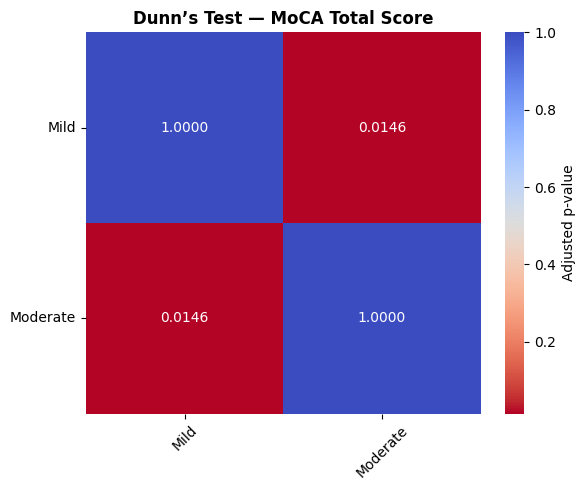

Kruskal-Dunn analysis for MoCA Total Score by UPDRS_II_Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


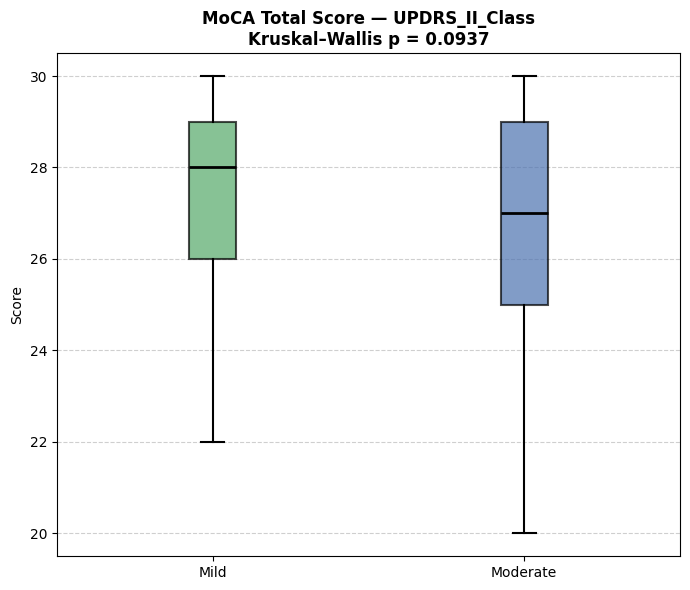


=== KRUSKAL–WALLIS RESULTS ===
MoCA Total Score: H = 2.810, p = 9.3670e-02  --> 🛑 Not significant
Kruskal-Dunn analysis for MoCA Total Score by UPDRS_III_Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


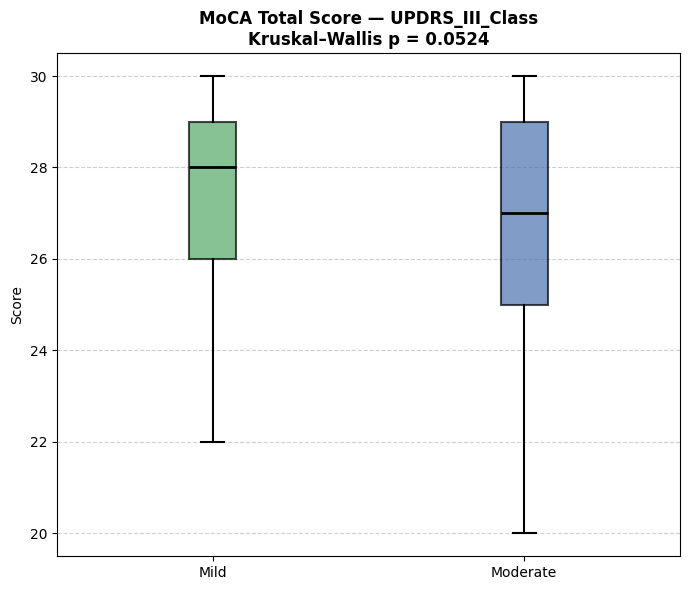


=== KRUSKAL–WALLIS RESULTS ===
MoCA Total Score: H = 3.763, p = 5.2387e-02  --> 🛑 Not significant


In [141]:
for col in ['UPDRS_I_Class', 'UPDRS_II_Class', 'UPDRS_III_Class']:
    print(f'Kruskal-Dunn analysis for MoCA Total Score by {col}:')
    kruskal_dunn_by_class(moca_df, col, ['MoCA Total Score'], class_order=['Mild','Moderate'])


### Chi^2 UPDRS Class - MoCA

Chi2 analysis for MoCA Total Score by UPDRS_I_Class:

 Chi-square test for: MoCA_Class vs UPDRS_I_Class

Chi² statistic = 9.952
p-value = 0.0016
Degrees of freedom = 1
Cramér's V = 0.109
Effect size: Weak
 ✅ Significant association (p < 0.05)

Contingency table (ordered):


UPDRS_I_Class,Mild,Moderate
MoCA_Class,,
MCI,163,36
Normal,643,69


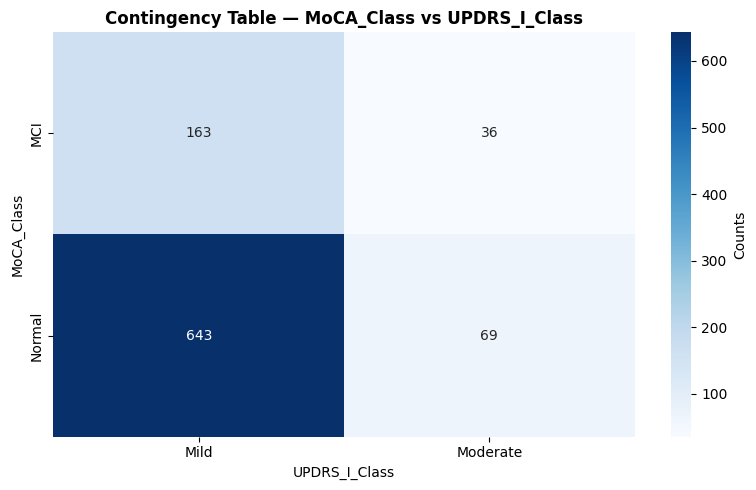

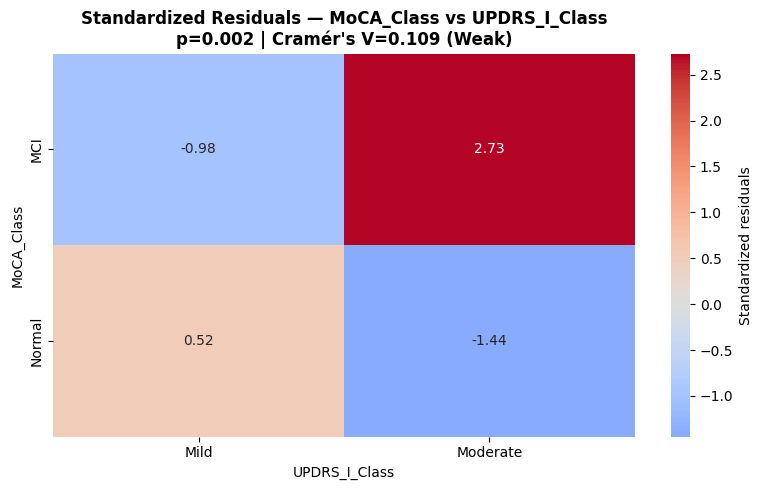


--------------------------------------------------------------------------------

Chi2 analysis for MoCA Total Score by UPDRS_II_Class:

 Chi-square test for: MoCA_Class vs UPDRS_II_Class

Chi² statistic = 3.897
p-value = 0.0484
Degrees of freedom = 1
Cramér's V = 0.069
Effect size: Weak
 ✅ Significant association (p < 0.05)

Contingency table (ordered):


UPDRS_II_Class,Mild,Moderate
MoCA_Class,,
MCI,161,38
Normal,618,94


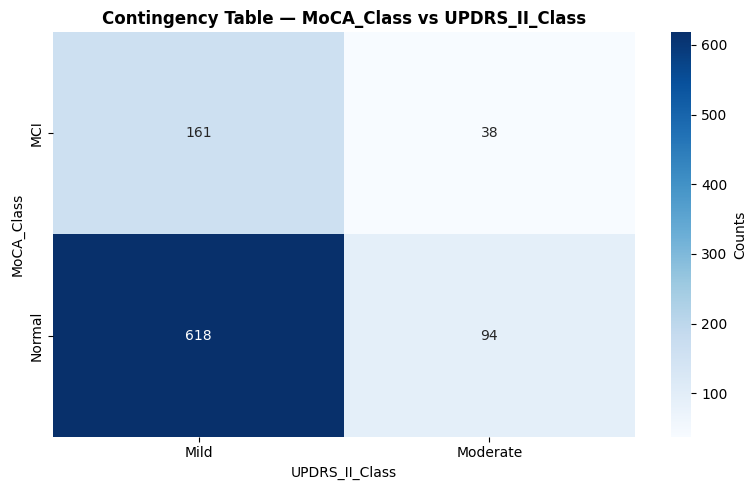

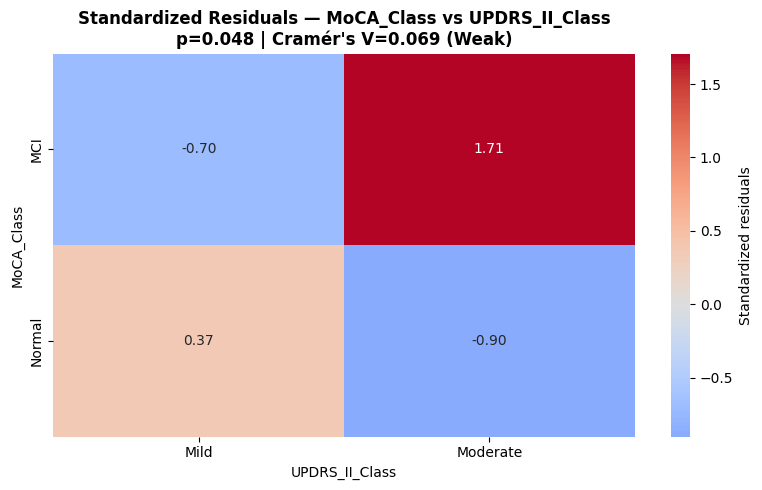


--------------------------------------------------------------------------------

Chi2 analysis for MoCA Total Score by UPDRS_III_Class:

 Chi-square test for: MoCA_Class vs UPDRS_III_Class

Chi² statistic = 3.142
p-value = 0.0763
Degrees of freedom = 1
Cramér's V = 0.063
Effect size: Weak
 🛑 No significant association (p ≥ 0.05)
    → No tables or heatmaps displayed.

--------------------------------------------------------------------------------



In [142]:
for col in updrs_class:
    print(f'Chi2 analysis for MoCA Total Score by {col}:')
    chi_square_heatmap(moca_df, 'MoCA_Class', col , order_1=None, order_2=['Mild','Moderate'])

### UPDRS Progression - MoCA

Kruskal-Dunn analysis for MoCA Total Score by UPDRS_I_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


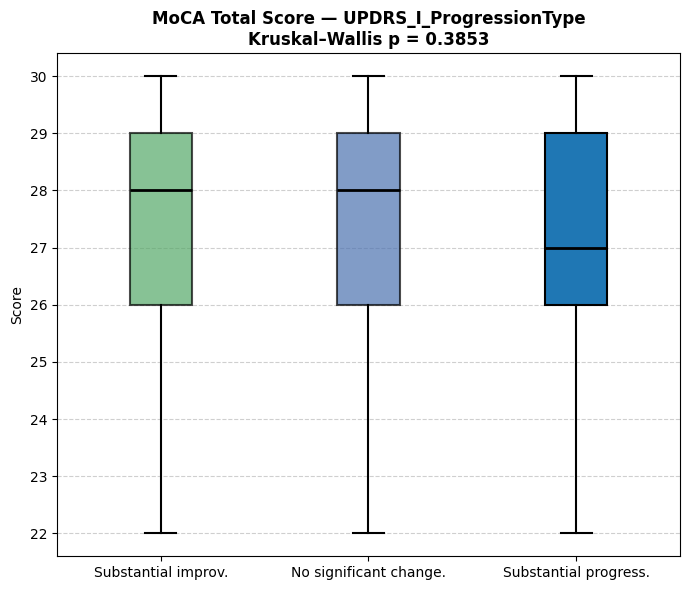


=== KRUSKAL–WALLIS RESULTS ===
MoCA Total Score: H = 1.907, p = 3.8531e-01  --> 🛑 Not significant
Kruskal-Dunn analysis for MoCA Total Score by UPDRS_II_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


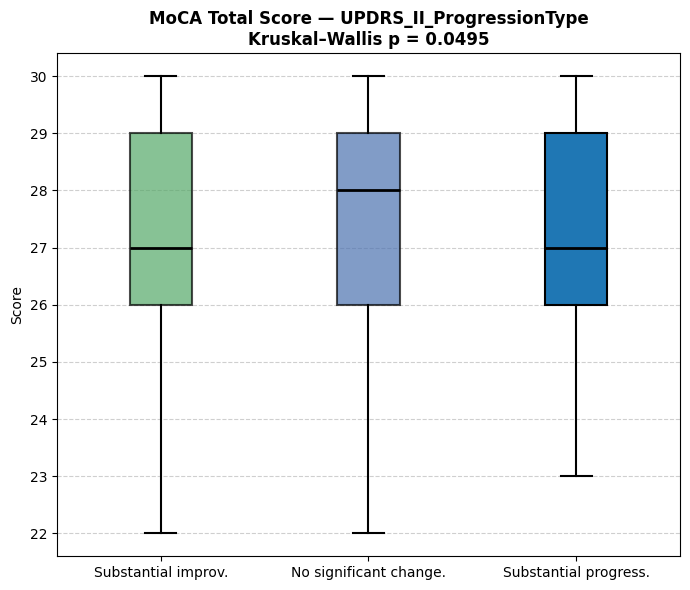


=== KRUSKAL–WALLIS RESULTS ===
MoCA Total Score: H = 6.013, p = 4.9462e-02  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for MoCA Total Score ===


,No significant change.,Substantial improv.,Substantial progress.
No significant change.,1.0000,0.217,0.1796
Substantial improv.,0.2170,1.000,1.0000
Substantial progress.,0.1796,1.000,1.0000


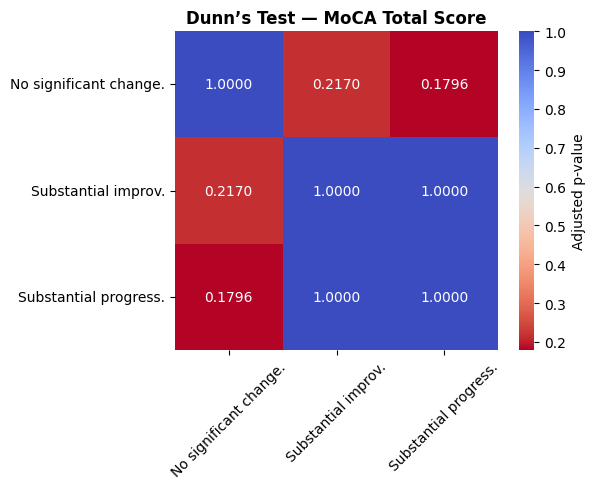

Kruskal-Dunn analysis for MoCA Total Score by UPDRS_III_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


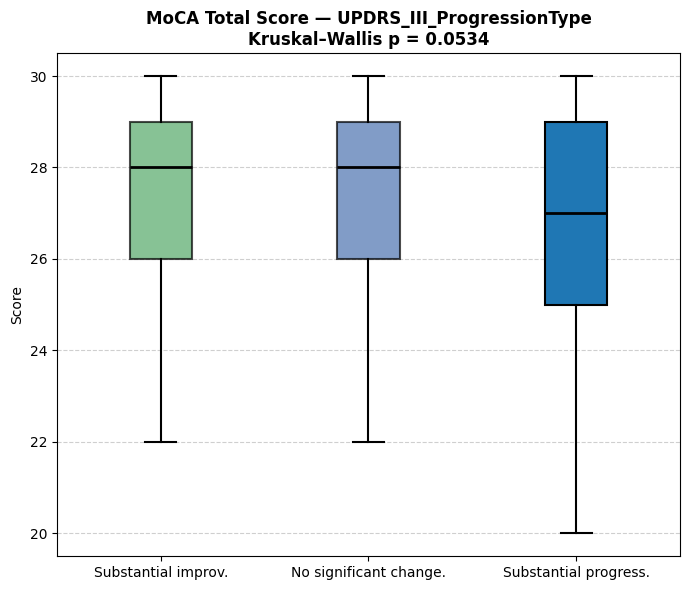


=== KRUSKAL–WALLIS RESULTS ===
MoCA Total Score: H = 5.861, p = 5.3361e-02  --> 🛑 Not significant


In [143]:
for col in ['UPDRS_I_ProgressionType', 'UPDRS_II_ProgressionType', 'UPDRS_III_ProgressionType']:
    print(f'Kruskal-Dunn analysis for MoCA Total Score by {col}:')
    kruskal_dunn_by_class(moca_df, col, ['MoCA Total Score'], class_order=['Substantial improv.' ,'No significant change.','Substantial progress.'])

### Chi^2 UPDRS Progression - MoCA

In [144]:
for col in ['UPDRS_I_ProgressionType', 'UPDRS_II_ProgressionType', 'UPDRS_III_ProgressionType']:
    print(f'Chi2 analysis for MoCA Total Score by {col}:')
    chi_square_heatmap(moca_df, 'MoCA_Class', col , order_1=None, order_2=['Substantial improv.' ,'No significant change.','Substantial progress.'])

Chi2 analysis for MoCA Total Score by UPDRS_I_ProgressionType:

 Chi-square test for: MoCA_Class vs UPDRS_I_ProgressionType

Chi² statistic = 0.362
p-value = 0.8346
Degrees of freedom = 2
Cramér's V = 0.020
Effect size: Weak
 🛑 No significant association (p ≥ 0.05)
    → No tables or heatmaps displayed.

--------------------------------------------------------------------------------

Chi2 analysis for MoCA Total Score by UPDRS_II_ProgressionType:

 Chi-square test for: MoCA_Class vs UPDRS_II_ProgressionType

Chi² statistic = 0.340
p-value = 0.8435
Degrees of freedom = 2
Cramér's V = 0.019
Effect size: Weak
 🛑 No significant association (p ≥ 0.05)
    → No tables or heatmaps displayed.

--------------------------------------------------------------------------------

Chi2 analysis for MoCA Total Score by UPDRS_III_ProgressionType:

 Chi-square test for: MoCA_Class vs UPDRS_III_ProgressionType

Chi² statistic = 5.056
p-value = 0.0798
Degrees of freedom = 2
Cramér's V = 0.074
Effect size

## STAI

In [145]:
stai_df = cognitive_data[['PATNO','Visit ID','STAI PART I Score','STAI PART II Score','STAI Total Score','MDS-UPDRS Total Score',
                            'MDS-UPDRS Part I (Patient Questionnaire) Total Score',
                            'MDS-UPDRS Part II Total Score',
                            'MDS-UPDRS Part III Total Score',
                            'MDS-UPDRS Total Score 1YearProg',
                            'UPDRS_III_1YearProg',
                            'MDS-UPDRS Total Score',
                            'Δ TOTAL_UPDRS_1Y',
                            'Δ UPDRS_I_1Y',
                            'Δ UPDRS_II_1Y',
                            'Δ UPDRS_III_1Y',
                            'Δ UPDRS_IV_1Y',
                            'UPDRS_I_Class',
                            'UPDRS_II_Class',
                            'UPDRS_III_Class',
                            'UPDRS_IV_Class',
                            'UPDRS_I_ProgressionType',
                            'UPDRS_II_ProgressionType',
                            'UPDRS_III_ProgressionType']]
stai_df.head(3)
# stai 1: estado de ansiedad actual
# Stai 2: estado de ansiedad rasgo

,PATNO,Visit ID,STAI PART I Score,STAI PART II Score,STAI Total Score,MDS-UPDRS Total Score,MDS-UPDRS Part I (Patient Questionnaire) Total Score,MDS-UPDRS Part II Total Score,MDS-UPDRS Part III Total Score,MDS-UPDRS Total Score 1YearProg,...,Δ UPDRS_II_1Y,Δ UPDRS_III_1Y,Δ UPDRS_IV_1Y,UPDRS_I_Class,UPDRS_II_Class,UPDRS_III_Class,UPDRS_IV_Class,UPDRS_I_ProgressionType,UPDRS_II_ProgressionType,UPDRS_III_ProgressionType
728,3001,V10_V12,53.0,50.0,103.0,46.0,6,5.0,35,37.0,...,-1.0,-9,0.0,Mild,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.
729,3003,V10_V12,51.0,42.0,93.0,72.0,9,10.0,53,59.0,...,-1.0,-14,0.0,Mild,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.
730,3010,V10_V12,44.0,40.0,84.0,52.0,11,16.0,18,70.0,...,4.0,16,-2.0,Moderate,Moderate,Mild,Moderate,No significant change.,No significant change.,Substantial progress.


### UPDRS Class - STAI Total

Kruskal-Dunn analysis for STAI Total Score by UPDRS_I_Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


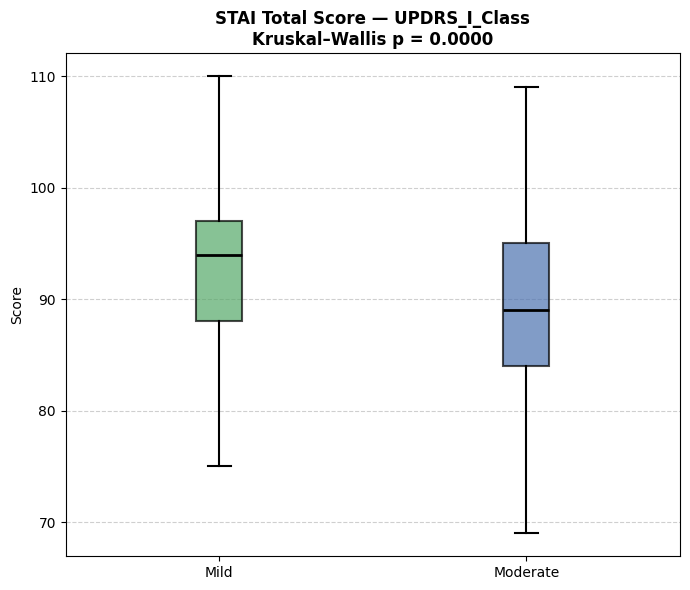


=== KRUSKAL–WALLIS RESULTS ===
STAI Total Score: H = 20.304, p = 6.6055e-06  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for STAI Total Score ===


,Mild,Moderate
Mild,1.0,0.0
Moderate,0.0,1.0


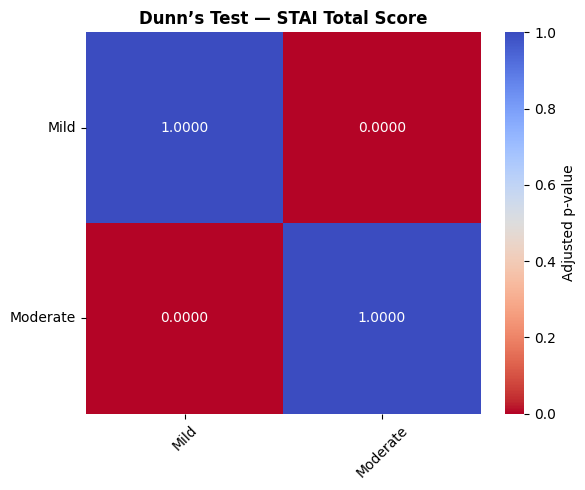

Kruskal-Dunn analysis for STAI Total Score by UPDRS_II_Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


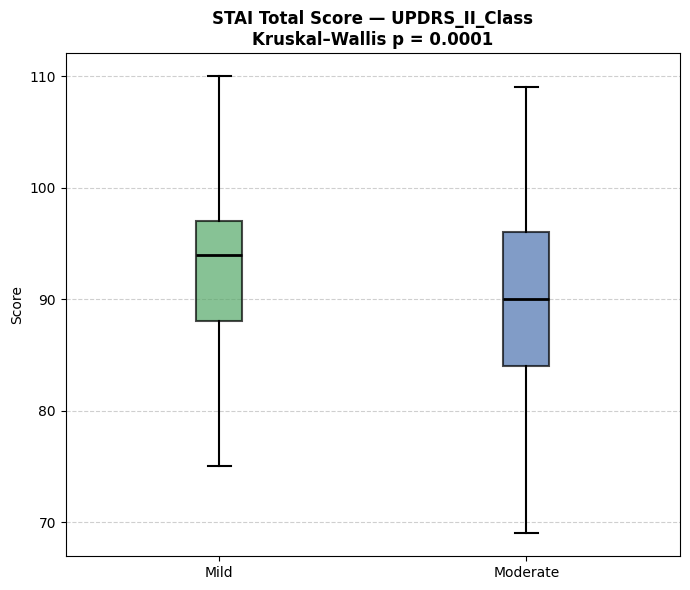


=== KRUSKAL–WALLIS RESULTS ===
STAI Total Score: H = 14.702, p = 1.2590e-04  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for STAI Total Score ===


,Mild,Moderate
Mild,1.0000,0.0001
Moderate,0.0001,1.0000


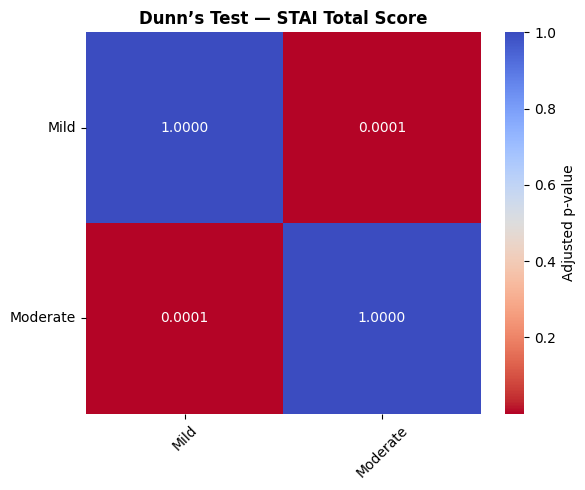

Kruskal-Dunn analysis for STAI Total Score by UPDRS_III_Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


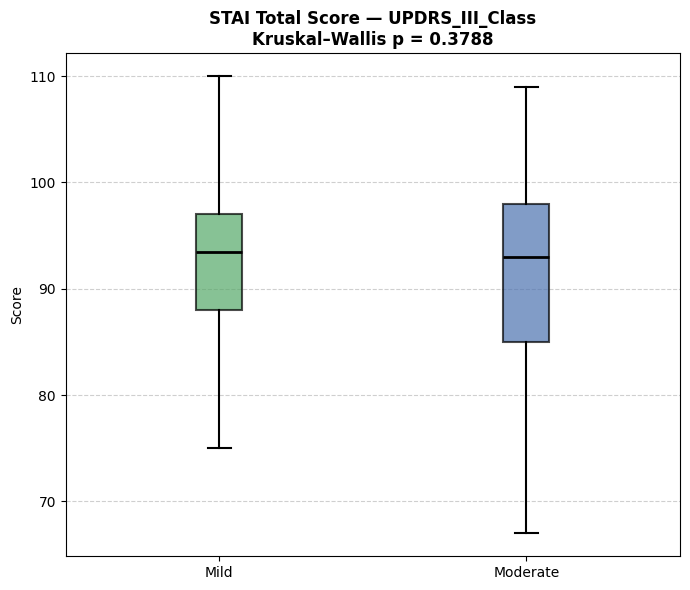


=== KRUSKAL–WALLIS RESULTS ===
STAI Total Score: H = 0.775, p = 3.7879e-01  --> 🛑 Not significant


In [146]:
for col in updrs_class:
    print(f'Kruskal-Dunn analysis for STAI Total Score by {col}:')
    kruskal_dunn_by_class(stai_df, col, ['STAI Total Score'], class_order=['Mild','Moderate'])

### UPDRS Class - STAI I

Kruskal Dunn analysis for STAI I Score by UPDRS_I_Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


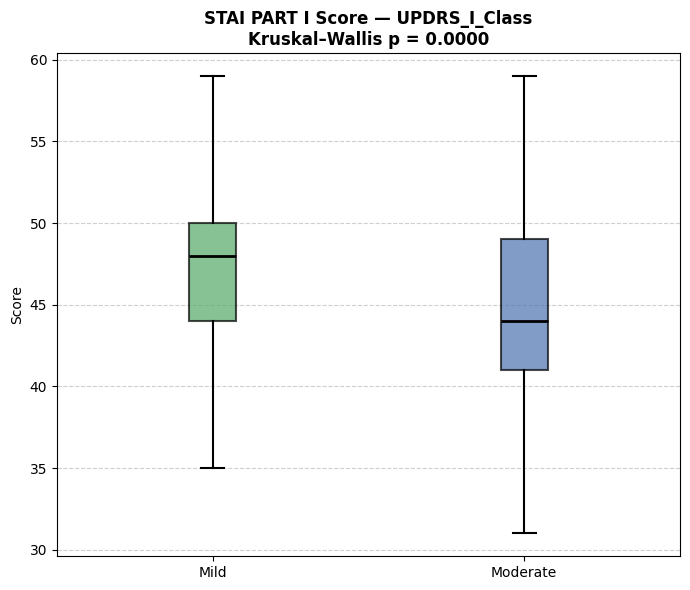


=== KRUSKAL–WALLIS RESULTS ===
STAI PART I Score: H = 19.071, p = 1.2597e-05  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for STAI PART I Score ===


,Mild,Moderate
Mild,1.0,0.0
Moderate,0.0,1.0


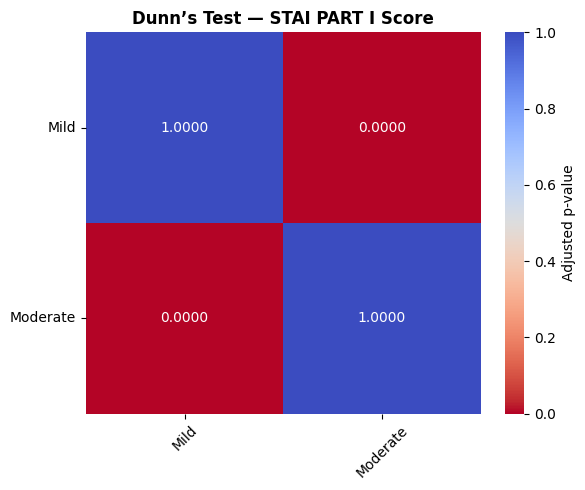

Kruskal Dunn analysis for STAI I Score by UPDRS_II_Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


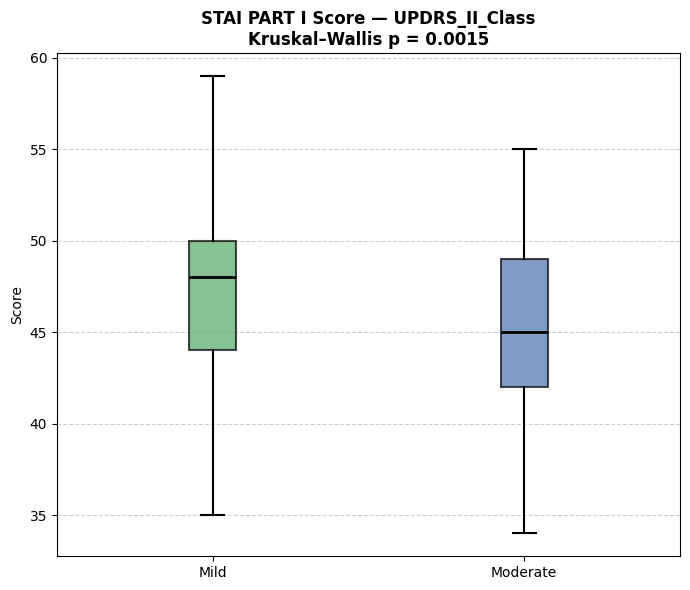


=== KRUSKAL–WALLIS RESULTS ===
STAI PART I Score: H = 10.103, p = 1.4806e-03  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for STAI PART I Score ===


,Mild,Moderate
Mild,1.0000,0.0015
Moderate,0.0015,1.0000


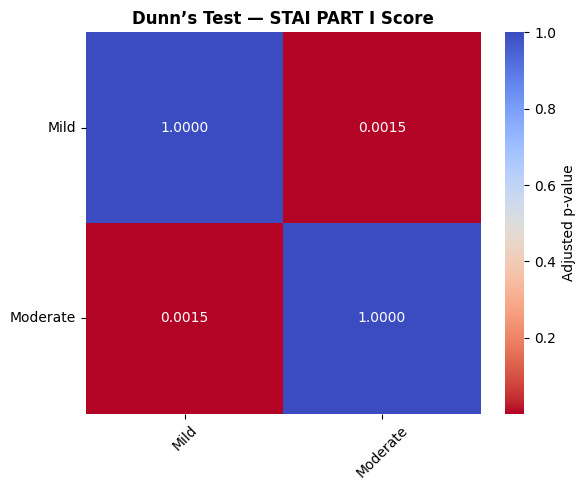

Kruskal Dunn analysis for STAI I Score by UPDRS_III_Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


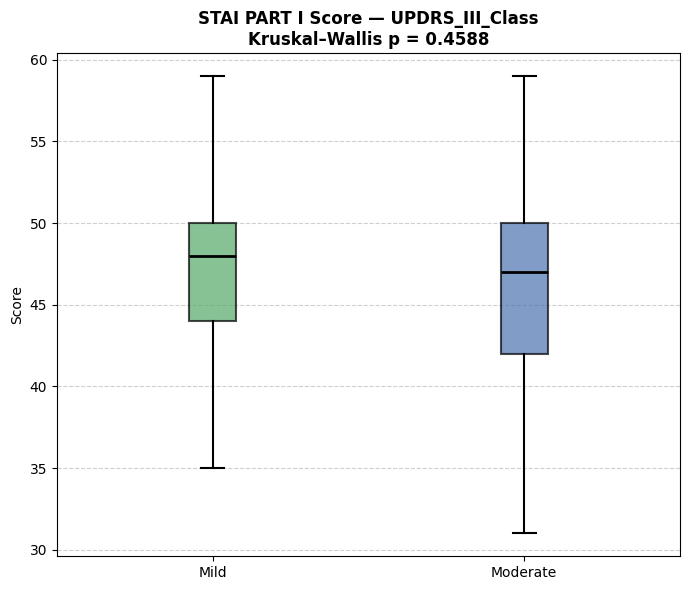


=== KRUSKAL–WALLIS RESULTS ===
STAI PART I Score: H = 0.549, p = 4.5879e-01  --> 🛑 Not significant


In [147]:
for col in updrs_class:
    print(f'Kruskal Dunn analysis for STAI I Score by {col}:')
    kruskal_dunn_by_class(stai_df, col, ['STAI PART I Score'], class_order=['Mild','Moderate'])

### UPDRS CLASS - STAI II 

Kruskal Dunn analysis for STAI II Score by UPDRS_I_Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


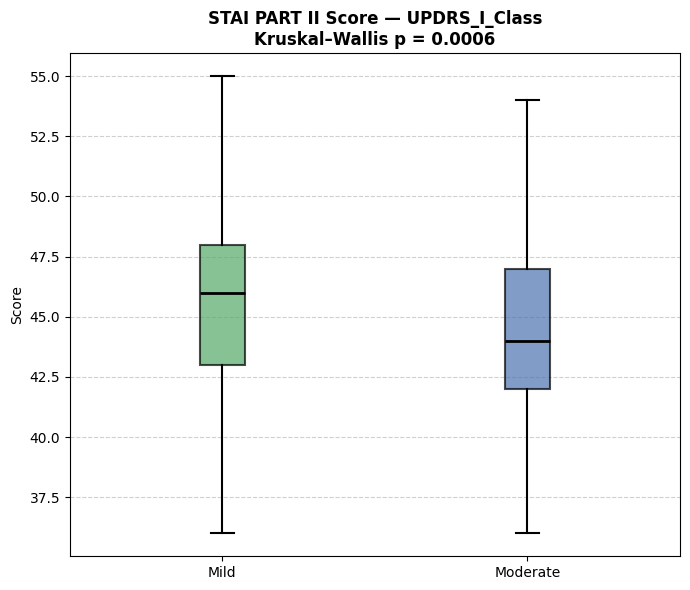


=== KRUSKAL–WALLIS RESULTS ===
STAI PART II Score: H = 11.658, p = 6.3933e-04  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for STAI PART II Score ===


,Mild,Moderate
Mild,1.0000,0.0006
Moderate,0.0006,1.0000


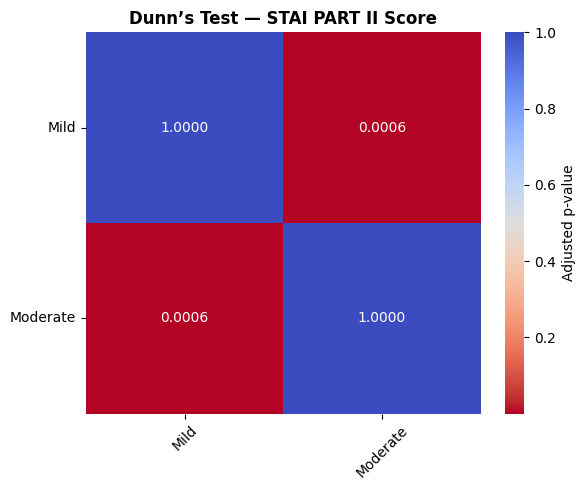

Kruskal Dunn analysis for STAI II Score by UPDRS_II_Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


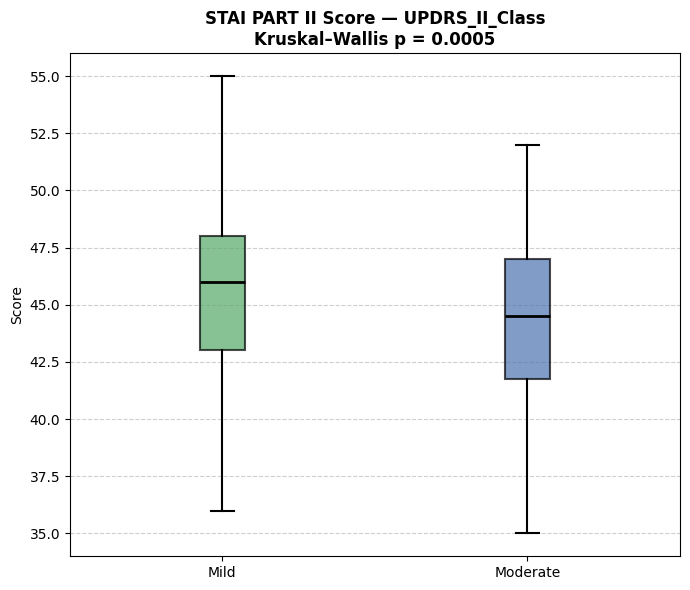


=== KRUSKAL–WALLIS RESULTS ===
STAI PART II Score: H = 12.198, p = 4.7847e-04  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for STAI PART II Score ===


,Mild,Moderate
Mild,1.0000,0.0005
Moderate,0.0005,1.0000


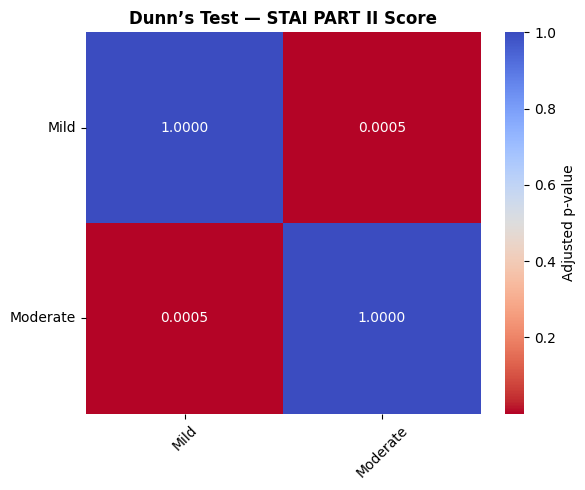

Kruskal Dunn analysis for STAI II Score by UPDRS_III_Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


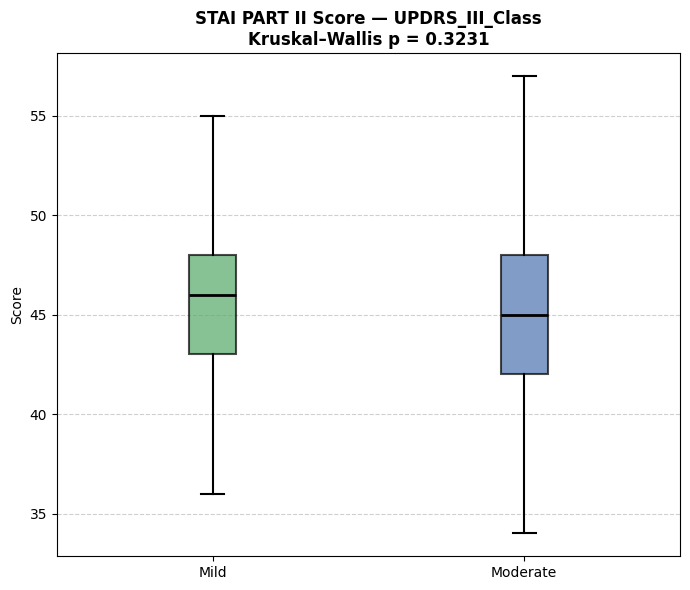


=== KRUSKAL–WALLIS RESULTS ===
STAI PART II Score: H = 0.976, p = 3.2310e-01  --> 🛑 Not significant


In [148]:
for col in updrs_class:
    print(f'Kruskal Dunn analysis for STAI II Score by {col}:')
    kruskal_dunn_by_class(stai_df, col, ['STAI PART II Score'], class_order=['Mild','Moderate'])

/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/891761042.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stai_df['UPDRS_I_II']=stai_df['UPDRS_I_Class']+'_'+stai_df['UPDRS_II_Class']
/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


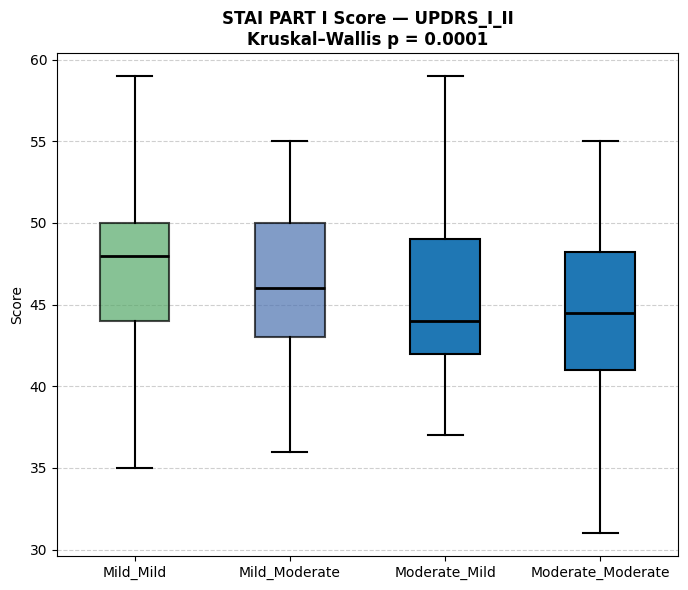


=== KRUSKAL–WALLIS RESULTS ===
STAI PART I Score: H = 22.049, p = 6.3703e-05  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for STAI PART I Score ===


,Mild_Mild,Mild_Moderate,Moderate_Mild,Moderate_Moderate
Mild_Mild,1.0000,0.7876,0.0369,0.0007
Mild_Moderate,0.7876,1.0000,1.0000,0.2103
Moderate_Mild,0.0369,1.0000,1.0000,1.0000
Moderate_Moderate,0.0007,0.2103,1.0000,1.0000


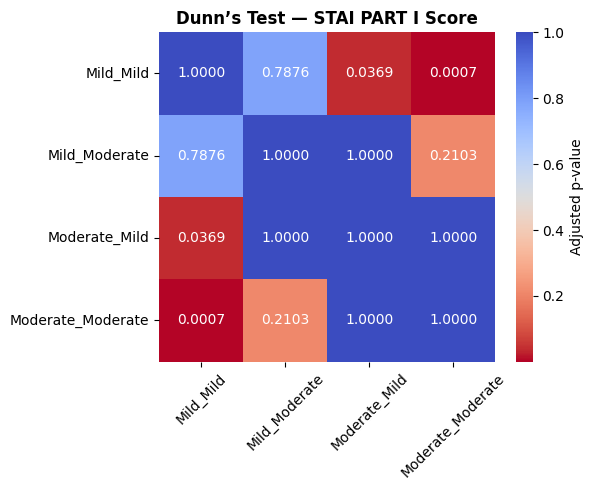

/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


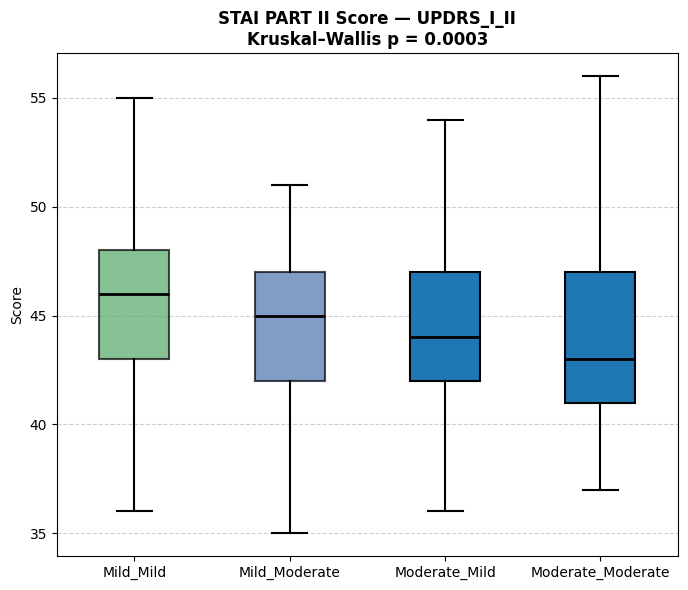


=== KRUSKAL–WALLIS RESULTS ===
STAI PART II Score: H = 19.020, p = 2.7086e-04  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for STAI PART II Score ===


,Mild_Mild,Mild_Moderate,Moderate_Mild,Moderate_Moderate
Mild_Mild,1.0000,0.041,0.0621,0.0273
Mild_Moderate,0.0410,1.000,1.0000,1.0000
Moderate_Mild,0.0621,1.000,1.0000,1.0000
Moderate_Moderate,0.0273,1.000,1.0000,1.0000


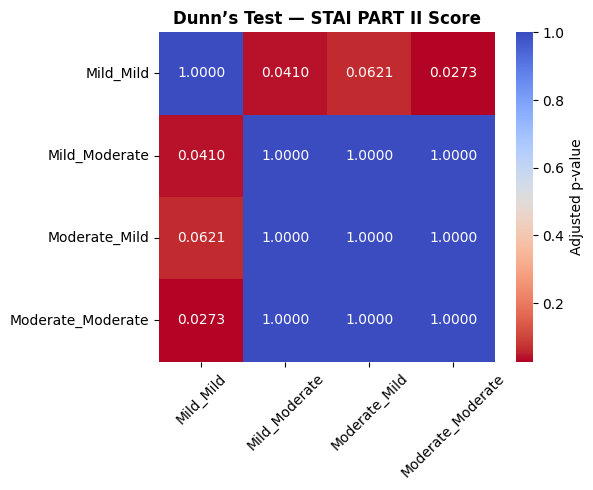

/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


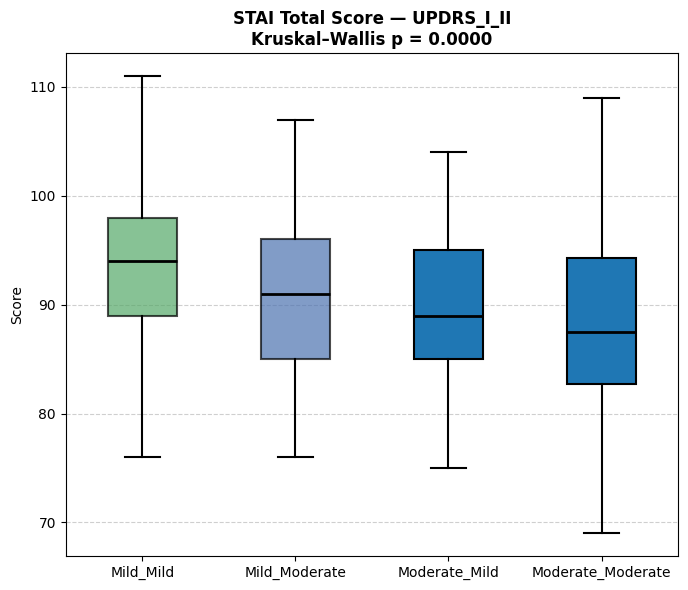


=== KRUSKAL–WALLIS RESULTS ===
STAI Total Score: H = 26.509, p = 7.4601e-06  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for STAI Total Score ===


,Mild_Mild,Mild_Moderate,Moderate_Mild,Moderate_Moderate
Mild_Mild,1.0000,0.0925,0.012,0.0007
Mild_Moderate,0.0925,1.0000,1.000,0.7971
Moderate_Mild,0.0120,1.0000,1.000,1.0000
Moderate_Moderate,0.0007,0.7971,1.000,1.0000


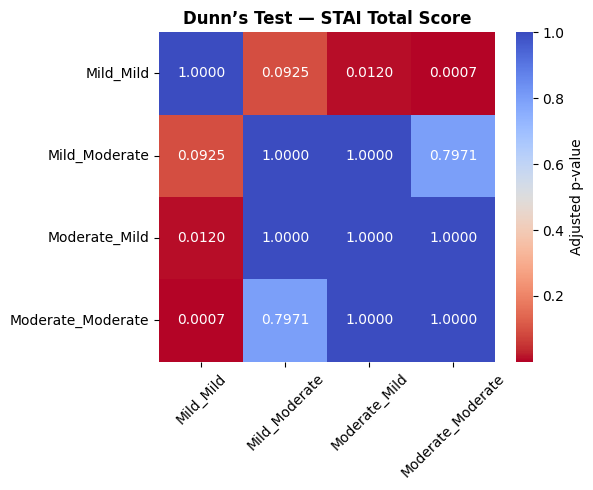

In [149]:
stai_df['UPDRS_I_II']=stai_df['UPDRS_I_Class']+'_'+stai_df['UPDRS_II_Class']

for col in ['STAI PART I Score','STAI PART II Score','STAI Total Score']: 
    kruskal_dunn_by_class(stai_df, 'UPDRS_I_II', [col], class_order=['Mild_Mild','Mild_Moderate','Moderate_Mild','Moderate_Moderate'])

### UPDRS Progression - STAI Total

/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


Kruskal-Dunn analysis for STAI Total Score by UPDRS_I_ProgressionType:


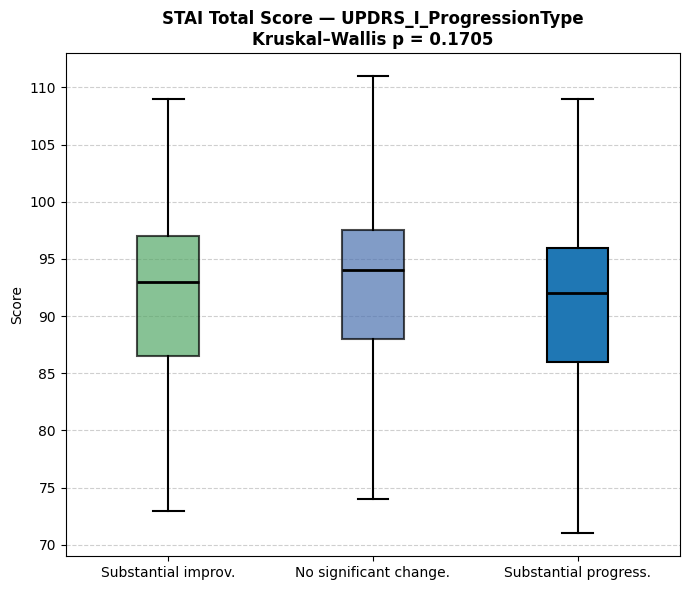


=== KRUSKAL–WALLIS RESULTS ===
STAI Total Score: H = 3.539, p = 1.7045e-01  --> 🛑 Not significant
Kruskal-Dunn analysis for STAI Total Score by UPDRS_II_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


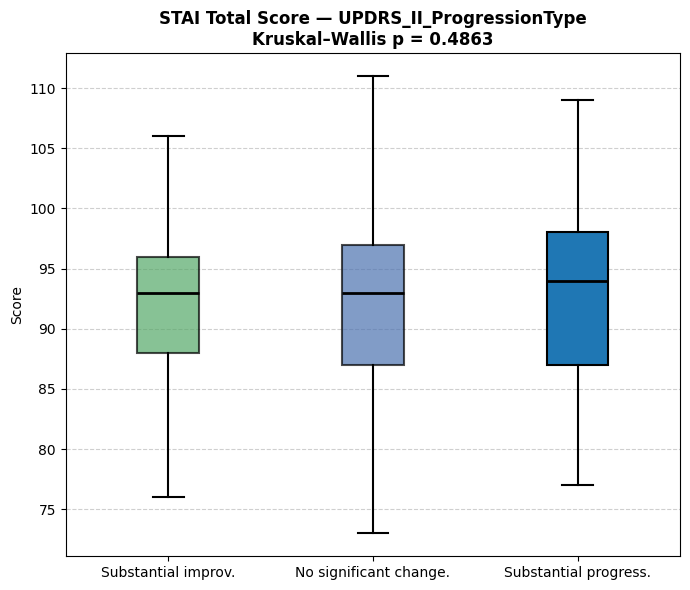


=== KRUSKAL–WALLIS RESULTS ===
STAI Total Score: H = 1.442, p = 4.8626e-01  --> 🛑 Not significant
Kruskal-Dunn analysis for STAI Total Score by UPDRS_III_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


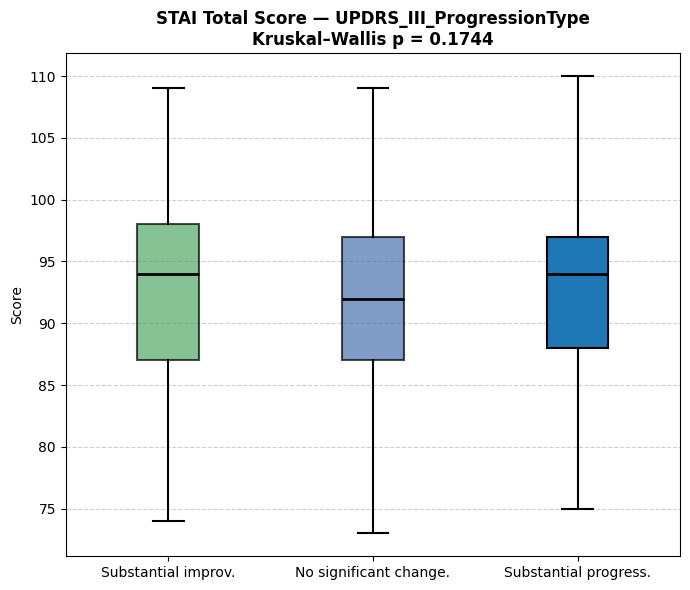


=== KRUSKAL–WALLIS RESULTS ===
STAI Total Score: H = 3.493, p = 1.7441e-01  --> 🛑 Not significant


In [150]:
for col in progression_types:
    print(f'Kruskal-Dunn analysis for STAI Total Score by {col}:')
    kruskal_dunn_by_class(stai_df, col, ['STAI Total Score'], class_order=['Substantial improv.' ,'No significant change.','Substantial progress.'])

### UPDRS Progression - STAI PART I

Kruskal Dunn analysis for STAI I Score by UPDRS_I_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


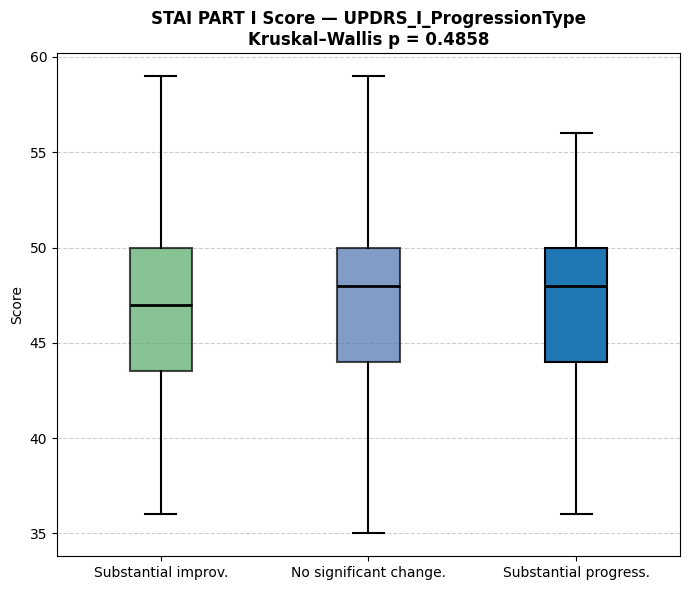


=== KRUSKAL–WALLIS RESULTS ===
STAI PART I Score: H = 1.444, p = 4.8582e-01  --> 🛑 Not significant
Kruskal Dunn analysis for STAI I Score by UPDRS_II_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


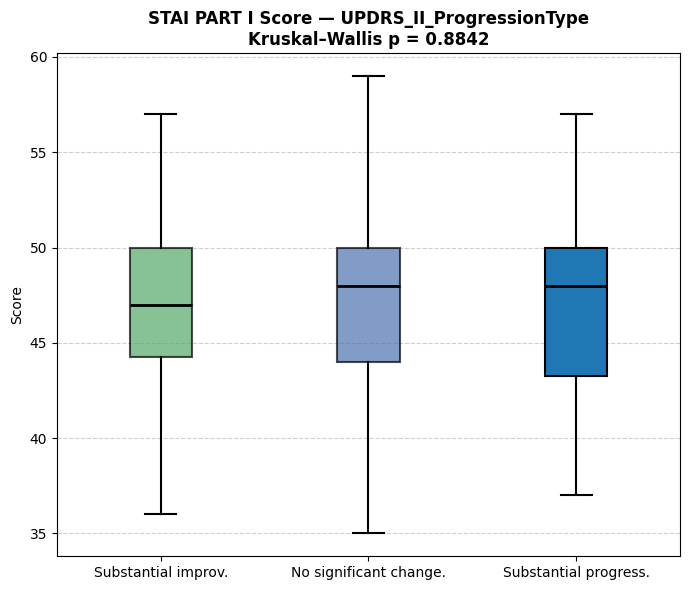


=== KRUSKAL–WALLIS RESULTS ===
STAI PART I Score: H = 0.246, p = 8.8418e-01  --> 🛑 Not significant
Kruskal Dunn analysis for STAI I Score by UPDRS_III_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


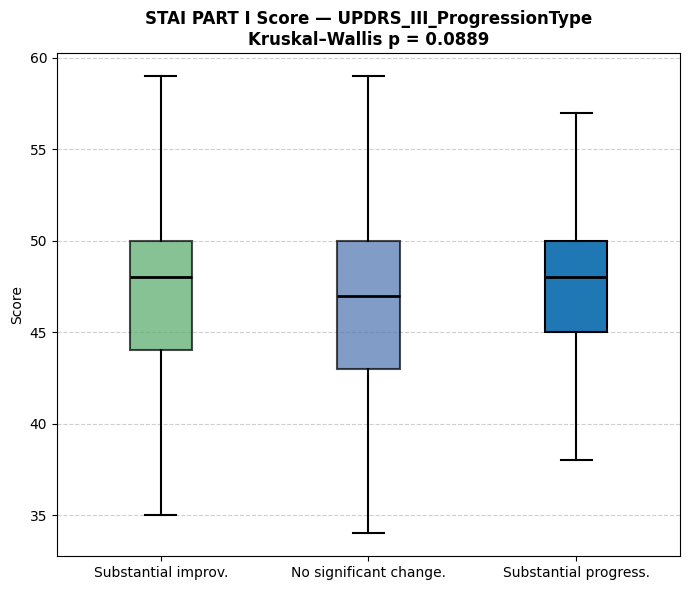


=== KRUSKAL–WALLIS RESULTS ===
STAI PART I Score: H = 4.839, p = 8.8945e-02  --> 🛑 Not significant


In [151]:
for col in progression_types:
    print(f'Kruskal Dunn analysis for STAI I Score by {col}:')
    kruskal_dunn_by_class(stai_df, col, ['STAI PART I Score'], class_order=['Substantial improv.' ,'No significant change.','Substantial progress.'])

### UPDRS Progression - STAI PART II

Kruskal Dunn analysis for STAI II Score by UPDRS_I_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


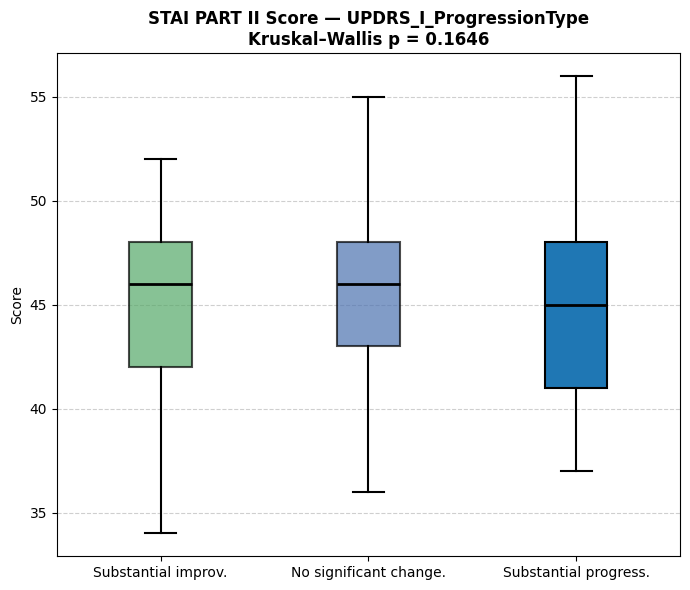


=== KRUSKAL–WALLIS RESULTS ===
STAI PART II Score: H = 3.608, p = 1.6462e-01  --> 🛑 Not significant
Kruskal Dunn analysis for STAI II Score by UPDRS_II_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


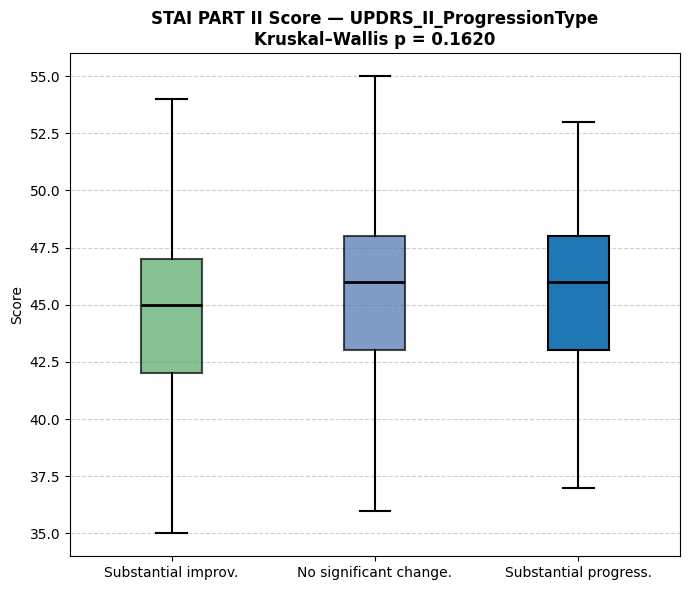


=== KRUSKAL–WALLIS RESULTS ===
STAI PART II Score: H = 3.641, p = 1.6198e-01  --> 🛑 Not significant
Kruskal Dunn analysis for STAI II Score by UPDRS_III_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


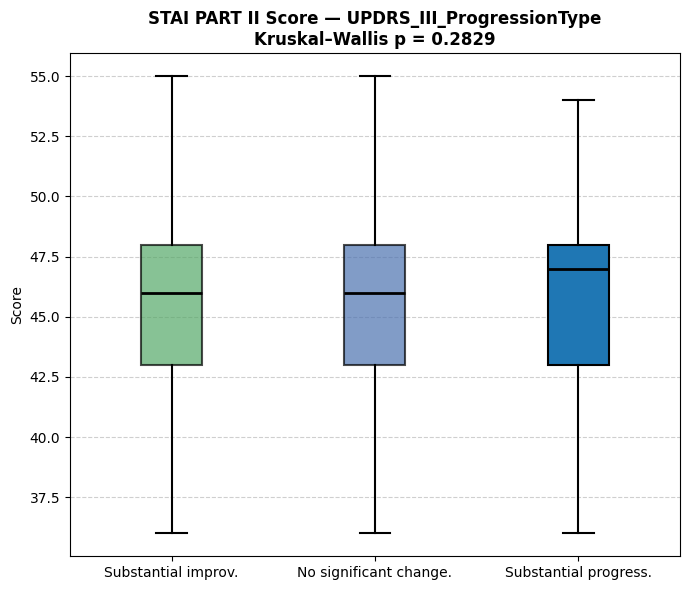


=== KRUSKAL–WALLIS RESULTS ===
STAI PART II Score: H = 2.525, p = 2.8288e-01  --> 🛑 Not significant


In [152]:
for col in progression_types:
    print(f'Kruskal Dunn analysis for STAI II Score by {col}:')
    kruskal_dunn_by_class(stai_df, col, ['STAI PART II Score'], class_order=['Substantial improv.' ,'No significant change.','Substantial progress.'])

## GDS - Geriatric Depression Scale

In [153]:
gds_df = cognitive_data[['PATNO','Visit ID','GDS Short Score','Has Depression','MDS-UPDRS Total Score',
                            'MDS-UPDRS Part I (Patient Questionnaire) Total Score',
                            'MDS-UPDRS Part II Total Score',
                            'MDS-UPDRS Part III Total Score',
                            'MDS-UPDRS Total Score 1YearProg',
                            'UPDRS_III_1YearProg',
                            'MDS-UPDRS Total Score',
                            'Δ TOTAL_UPDRS_1Y',
                            'Δ UPDRS_I_1Y',
                            'Δ UPDRS_II_1Y',
                            'Δ UPDRS_III_1Y',
                            'Δ UPDRS_IV_1Y',
                            'UPDRS_I_Class',
                            'UPDRS_II_Class',
                            'UPDRS_III_Class',
                            'UPDRS_IV_Class',
                            'UPDRS_I_ProgressionType',
                            'UPDRS_II_ProgressionType',
                            'UPDRS_III_ProgressionType']]
                            
gds_df.head(3)

,PATNO,Visit ID,GDS Short Score,Has Depression,MDS-UPDRS Total Score,MDS-UPDRS Part I (Patient Questionnaire) Total Score,MDS-UPDRS Part II Total Score,MDS-UPDRS Part III Total Score,MDS-UPDRS Total Score 1YearProg,UPDRS_III_1YearProg,...,Δ UPDRS_II_1Y,Δ UPDRS_III_1Y,Δ UPDRS_IV_1Y,UPDRS_I_Class,UPDRS_II_Class,UPDRS_III_Class,UPDRS_IV_Class,UPDRS_I_ProgressionType,UPDRS_II_ProgressionType,UPDRS_III_ProgressionType
728,3001,V10_V12,1,False,46.0,6,5.0,35,37.0,26,...,-1.0,-9,0.0,Mild,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.
729,3003,V10_V12,2,False,72.0,9,10.0,53,59.0,39,...,-1.0,-14,0.0,Mild,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.
730,3010,V10_V12,4,False,52.0,11,16.0,18,70.0,34,...,4.0,16,-2.0,Moderate,Moderate,Mild,Moderate,No significant change.,No significant change.,Substantial progress.


### UPDRS Class - GDS

Kruskal-Dunn analysis for GDS Short Score by UPDRS_I_Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


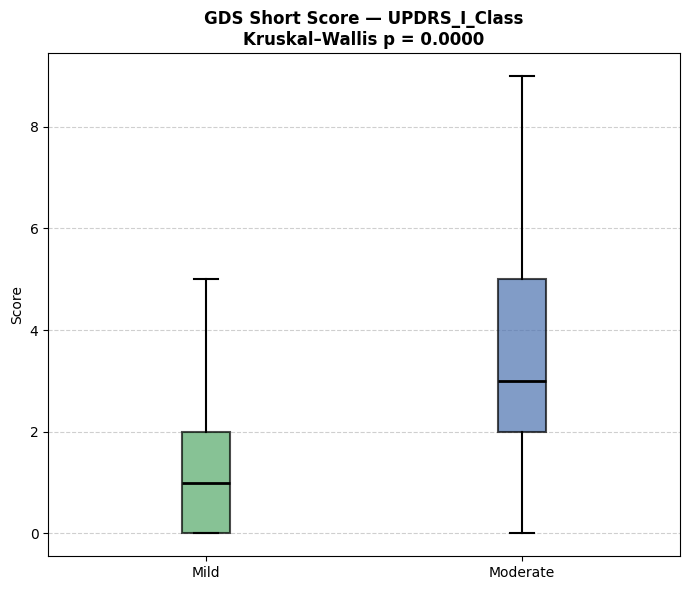


=== KRUSKAL–WALLIS RESULTS ===
GDS Short Score: H = 67.816, p = 1.7948e-16  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for GDS Short Score ===


,Mild,Moderate
Mild,1.0,0.0
Moderate,0.0,1.0


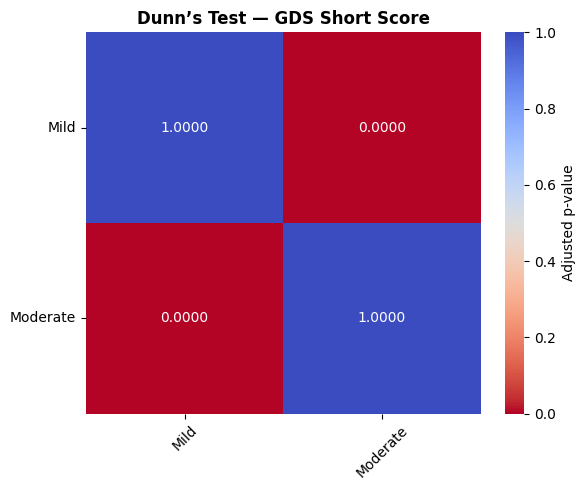

Kruskal-Dunn analysis for GDS Short Score by UPDRS_II_Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


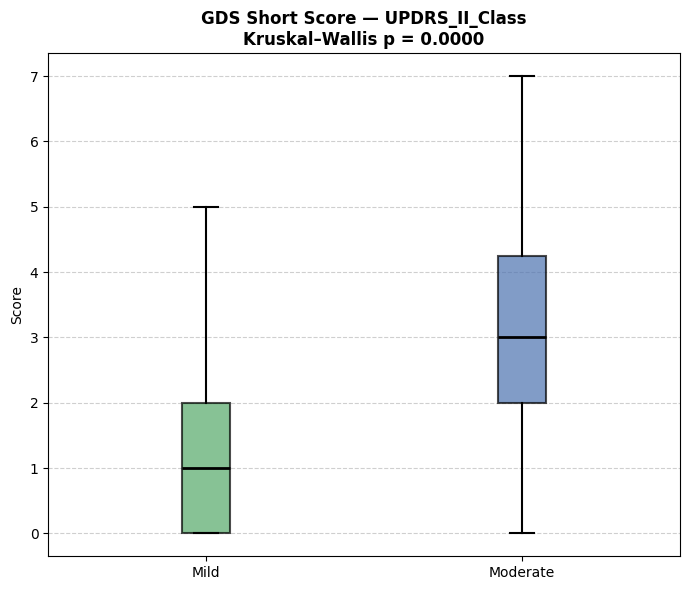


=== KRUSKAL–WALLIS RESULTS ===
GDS Short Score: H = 65.061, p = 7.2611e-16  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for GDS Short Score ===


,Mild,Moderate
Mild,1.0,0.0
Moderate,0.0,1.0


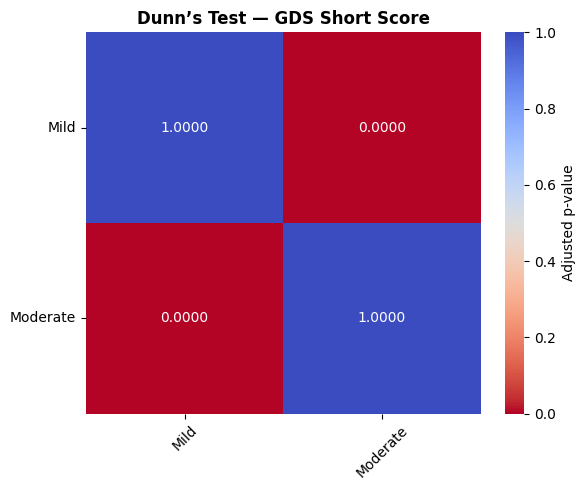

Kruskal-Dunn analysis for GDS Short Score by UPDRS_III_Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


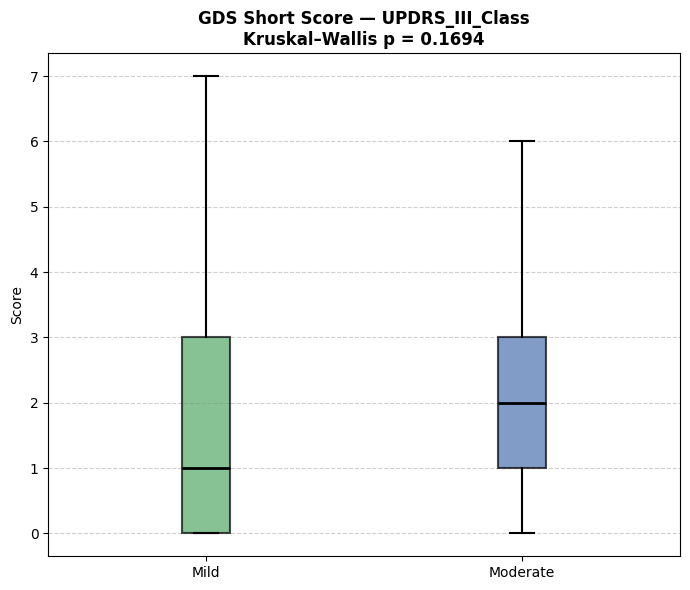


=== KRUSKAL–WALLIS RESULTS ===
GDS Short Score: H = 1.889, p = 1.6936e-01  --> 🛑 Not significant


In [154]:
for col in updrs_class:
    print(f'Kruskal-Dunn analysis for GDS Short Score by {col}:')
    kruskal_dunn_by_class(gds_df, col, ['GDS Short Score'], class_order=['Mild','Moderate'])

### Chi2 UPDRS Class - GDS 

Chi2 analysis for GDS Short Score by UPDRS_I_Class:

 Chi-square test for: Has Depression vs UPDRS_I_Class

Chi² statistic = 53.658
p-value = 0.0000
Degrees of freedom = 1
Cramér's V = 0.248
Effect size: Moderate
 ✅ Significant association (p < 0.05)

Contingency table (ordered):


UPDRS_I_Class,Mild,Moderate
Has Depression,,
False,729,68
True,77,37


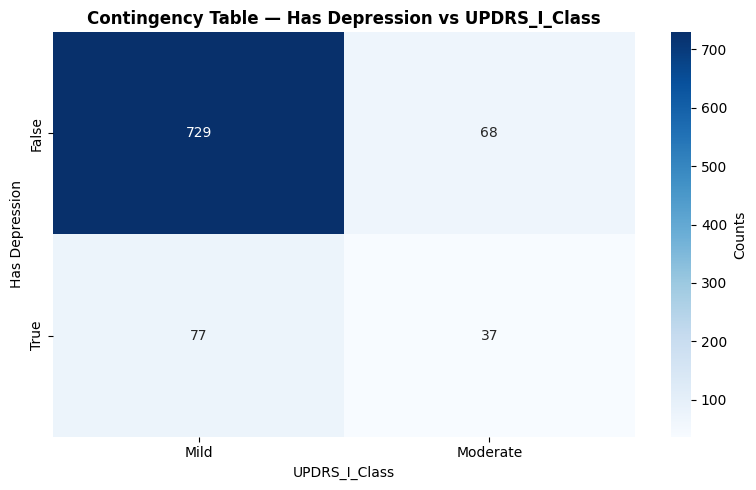

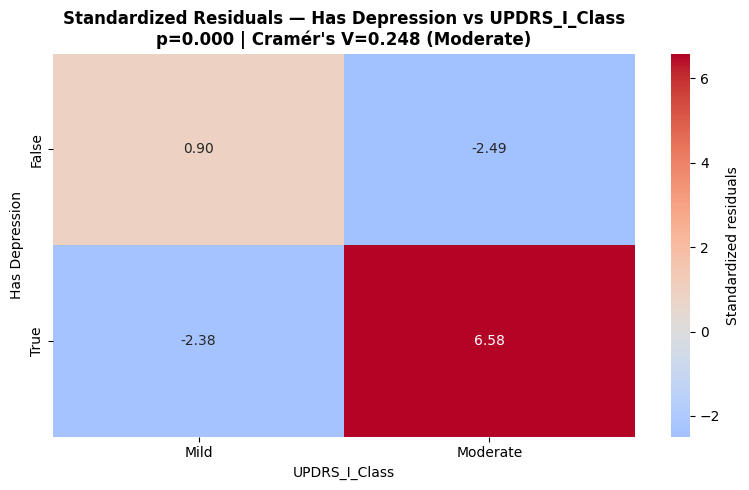


--------------------------------------------------------------------------------

Chi2 analysis for GDS Short Score by UPDRS_II_Class:

 Chi-square test for: Has Depression vs UPDRS_II_Class

Chi² statistic = 20.670
p-value = 0.0000
Degrees of freedom = 1
Cramér's V = 0.155
Effect size: Weak
 ✅ Significant association (p < 0.05)

Contingency table (ordered):


UPDRS_II_Class,Mild,Moderate
Has Depression,,
False,698,99
True,81,33


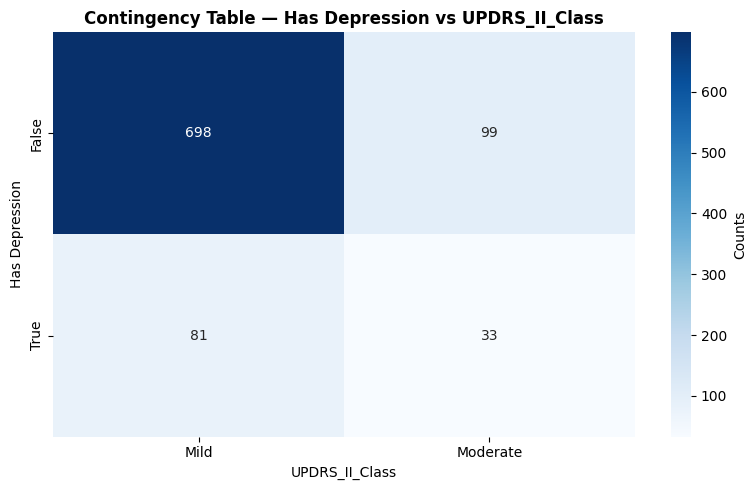

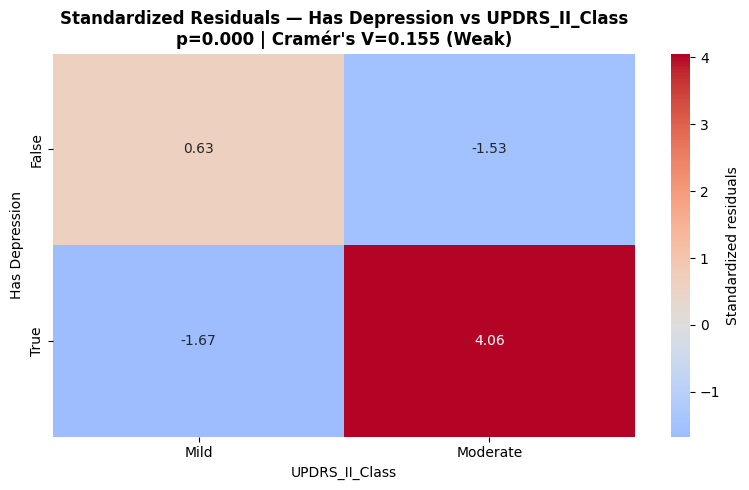


--------------------------------------------------------------------------------

Chi2 analysis for GDS Short Score by UPDRS_III_Class:

 Chi-square test for: Has Depression vs UPDRS_III_Class

Chi² statistic = 0.682
p-value = 0.4090
Degrees of freedom = 1
Cramér's V = 0.033
Effect size: Weak
 🛑 No significant association (p ≥ 0.05)
    → No tables or heatmaps displayed.

--------------------------------------------------------------------------------



In [155]:
for col in updrs_class:
    print(f'Chi2 analysis for GDS Short Score by {col}:')
    chi_square_heatmap(gds_df, 'Has Depression', col , order_1=None, order_2=['Mild','Moderate'])

/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/3630246633.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gds_df['UPDRS_I_II'] = gds_df['UPDRS_I_Class'] + ' & ' + gds_df['UPDRS_II_Class']
/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


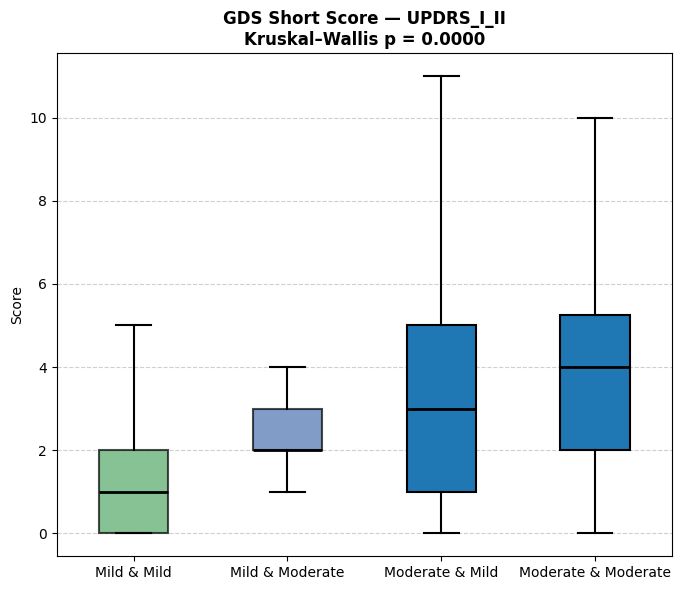


=== KRUSKAL–WALLIS RESULTS ===
GDS Short Score: H = 100.742, p = 1.0763e-21  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for GDS Short Score ===


,Mild & Mild,Mild & Moderate,Moderate & Mild,Moderate & Moderate
Mild & Mild,1.0,0.0000,0.0,0.0000
Mild & Moderate,0.0,1.0000,1.0,0.1575
Moderate & Mild,0.0,1.0000,1.0,1.0000
Moderate & Moderate,0.0,0.1575,1.0,1.0000


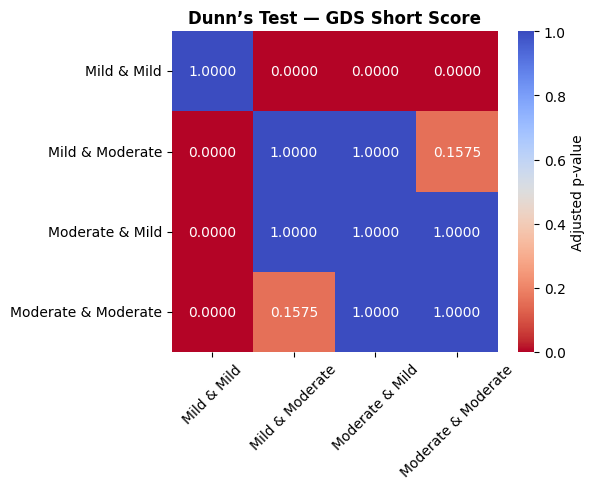


 Chi-square test for: Has Depression vs UPDRS_I_II

Chi² statistic = 60.596
p-value = 0.0000
Degrees of freedom = 3
Cramér's V = 0.258
Effect size: Moderate
 ✅ Significant association (p < 0.05)

Contingency table (ordered):


UPDRS_I_II,Mild & Mild,Mild & Moderate,Moderate & Mild,Moderate & Moderate
Has Depression,,,,
False,662,67,36,32
True,64,13,17,20


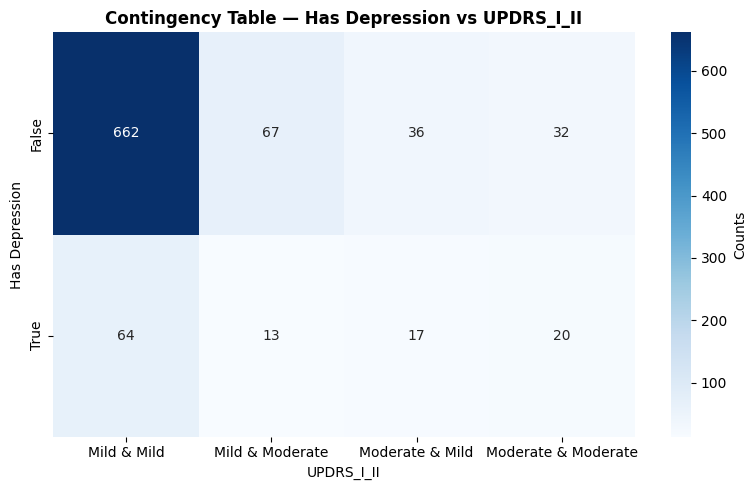

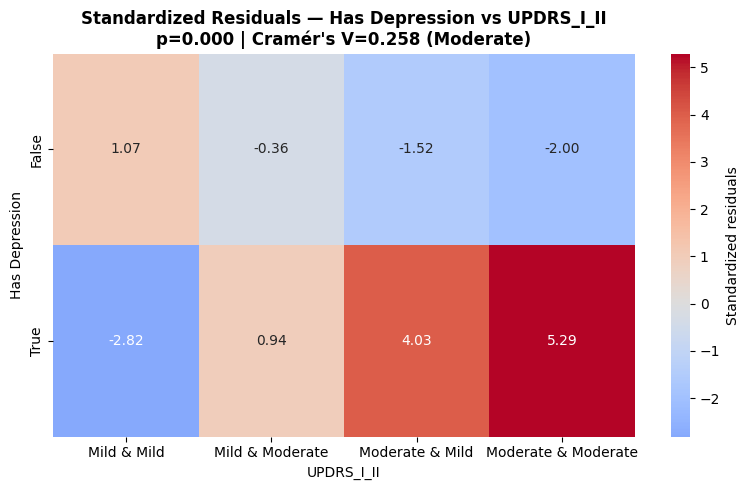


--------------------------------------------------------------------------------



In [156]:
gds_df[['Has Depression','UPDRS_I_Class','UPDRS_II_Class']].value_counts()
gds_df['UPDRS_I_II'] = gds_df['UPDRS_I_Class'] + ' & ' + gds_df['UPDRS_II_Class']

kruskal_dunn_by_class(gds_df, 'UPDRS_I_II', ['GDS Short Score'], class_order=None)
chi_square_heatmap(gds_df, 'Has Depression', 'UPDRS_I_II' , order_1=None, order_2=None)




### UPDRSS Prpgression - GDS

Kruskal-Dunn analysis for GDS Short Score by UPDRS_I_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


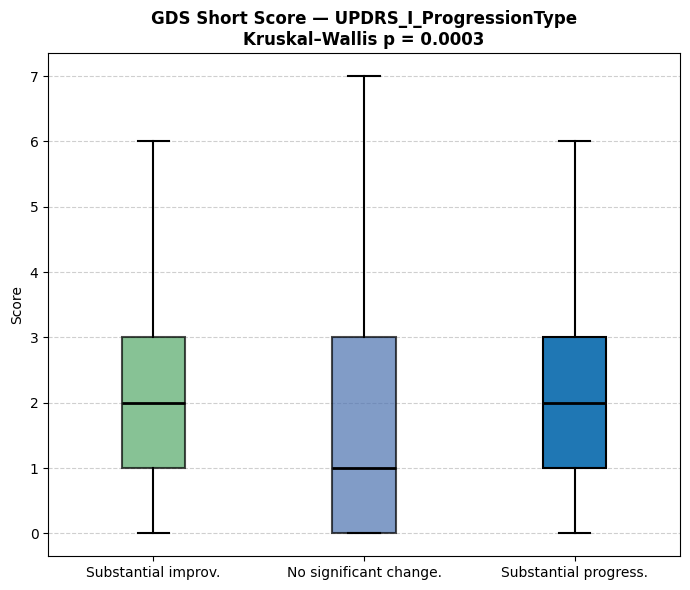


=== KRUSKAL–WALLIS RESULTS ===
GDS Short Score: H = 16.541, p = 2.5595e-04  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for GDS Short Score ===


,No significant change.,Substantial improv.,Substantial progress.
No significant change.,1.0000,0.0007,0.076
Substantial improv.,0.0007,1.0000,0.925
Substantial progress.,0.0760,0.9250,1.000


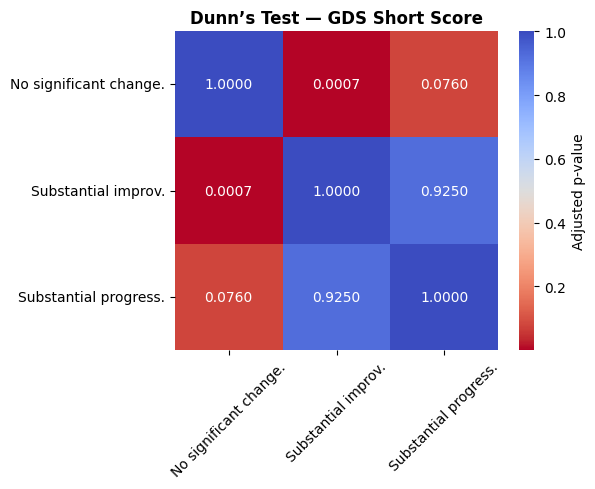

Kruskal-Dunn analysis for GDS Short Score by UPDRS_II_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


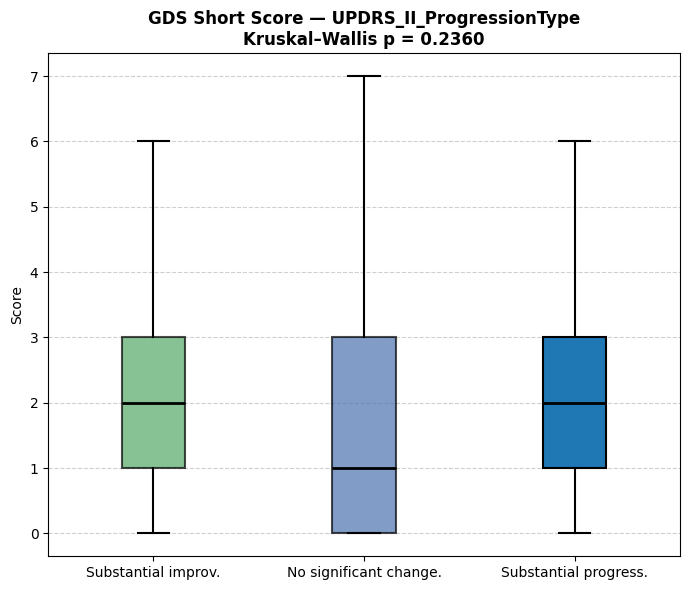


=== KRUSKAL–WALLIS RESULTS ===
GDS Short Score: H = 2.888, p = 2.3602e-01  --> 🛑 Not significant
Kruskal-Dunn analysis for GDS Short Score by UPDRS_III_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


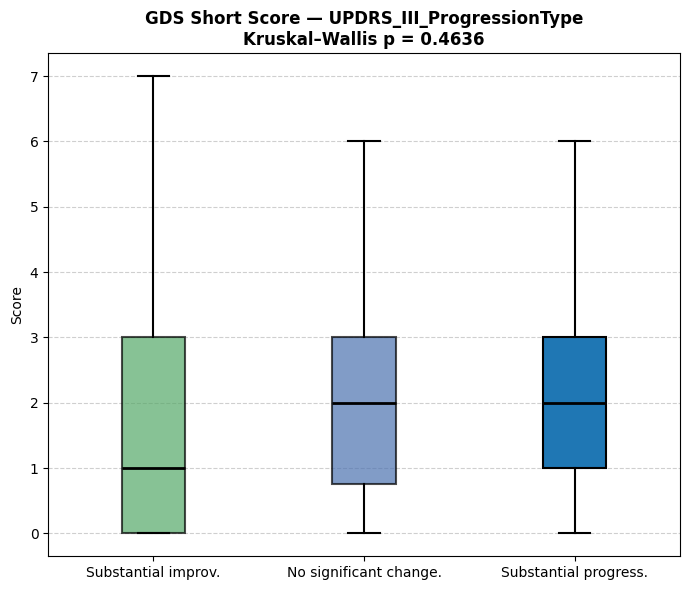


=== KRUSKAL–WALLIS RESULTS ===
GDS Short Score: H = 1.537, p = 4.6364e-01  --> 🛑 Not significant


In [157]:
for col in progression_types:
    print(f'Kruskal-Dunn analysis for GDS Short Score by {col}:')
    kruskal_dunn_by_class(gds_df, col, ['GDS Short Score'], class_order=['Substantial improv.' ,'No significant change.','Substantial progress.'])

### Chi2 UPDRS Progression - GDS

In [158]:
for col in progression_types:
    print(f'Chi2 analysis for GDS Short Score by {col}:')
    chi_square_heatmap(gds_df, 'Has Depression', col , order_1=None, order_2=['Substantial improv.' ,'No significant change.','Substantial progress.'])

Chi2 analysis for GDS Short Score by UPDRS_I_ProgressionType:

 Chi-square test for: Has Depression vs UPDRS_I_ProgressionType

Chi² statistic = 4.290
p-value = 0.1171
Degrees of freedom = 2
Cramér's V = 0.069
Effect size: Weak
 🛑 No significant association (p ≥ 0.05)
    → No tables or heatmaps displayed.

--------------------------------------------------------------------------------

Chi2 analysis for GDS Short Score by UPDRS_II_ProgressionType:

 Chi-square test for: Has Depression vs UPDRS_II_ProgressionType

Chi² statistic = 2.382
p-value = 0.3039
Degrees of freedom = 2
Cramér's V = 0.051
Effect size: Weak
 🛑 No significant association (p ≥ 0.05)
    → No tables or heatmaps displayed.

--------------------------------------------------------------------------------

Chi2 analysis for GDS Short Score by UPDRS_III_ProgressionType:

 Chi-square test for: Has Depression vs UPDRS_III_ProgressionType

Chi² statistic = 0.854
p-value = 0.6526
Degrees of freedom = 2
Cramér's V = 0.031
Ef

## GDS and STAI Analysis

In [159]:
# depression and anxiety comorbidity
comorbidity_df = gds_df.merge(stai_df[['PATNO','Visit ID','STAI Total Score','STAI PART I Score','STAI PART II Score']], on=['PATNO','Visit ID'], how='inner')
comorbidity_df.head(3)

,PATNO,Visit ID,GDS Short Score,Has Depression,MDS-UPDRS Total Score,MDS-UPDRS Part I (Patient Questionnaire) Total Score,MDS-UPDRS Part II Total Score,MDS-UPDRS Part III Total Score,MDS-UPDRS Total Score 1YearProg,UPDRS_III_1YearProg,...,UPDRS_II_Class,UPDRS_III_Class,UPDRS_IV_Class,UPDRS_I_ProgressionType,UPDRS_II_ProgressionType,UPDRS_III_ProgressionType,UPDRS_I_II,STAI Total Score,STAI PART I Score,STAI PART II Score
0,3001,V10_V12,1,False,46.0,6,5.0,35,37.0,26,...,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.,Mild & Mild,103.0,53.0,50.0
1,3003,V10_V12,2,False,72.0,9,10.0,53,59.0,39,...,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.,Mild & Mild,93.0,51.0,42.0
2,3010,V10_V12,4,False,52.0,11,16.0,18,70.0,34,...,Moderate,Mild,Moderate,No significant change.,No significant change.,Substantial progress.,Moderate & Moderate,84.0,44.0,40.0


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/852303133.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(
/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/852303133.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(
/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/852303133.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


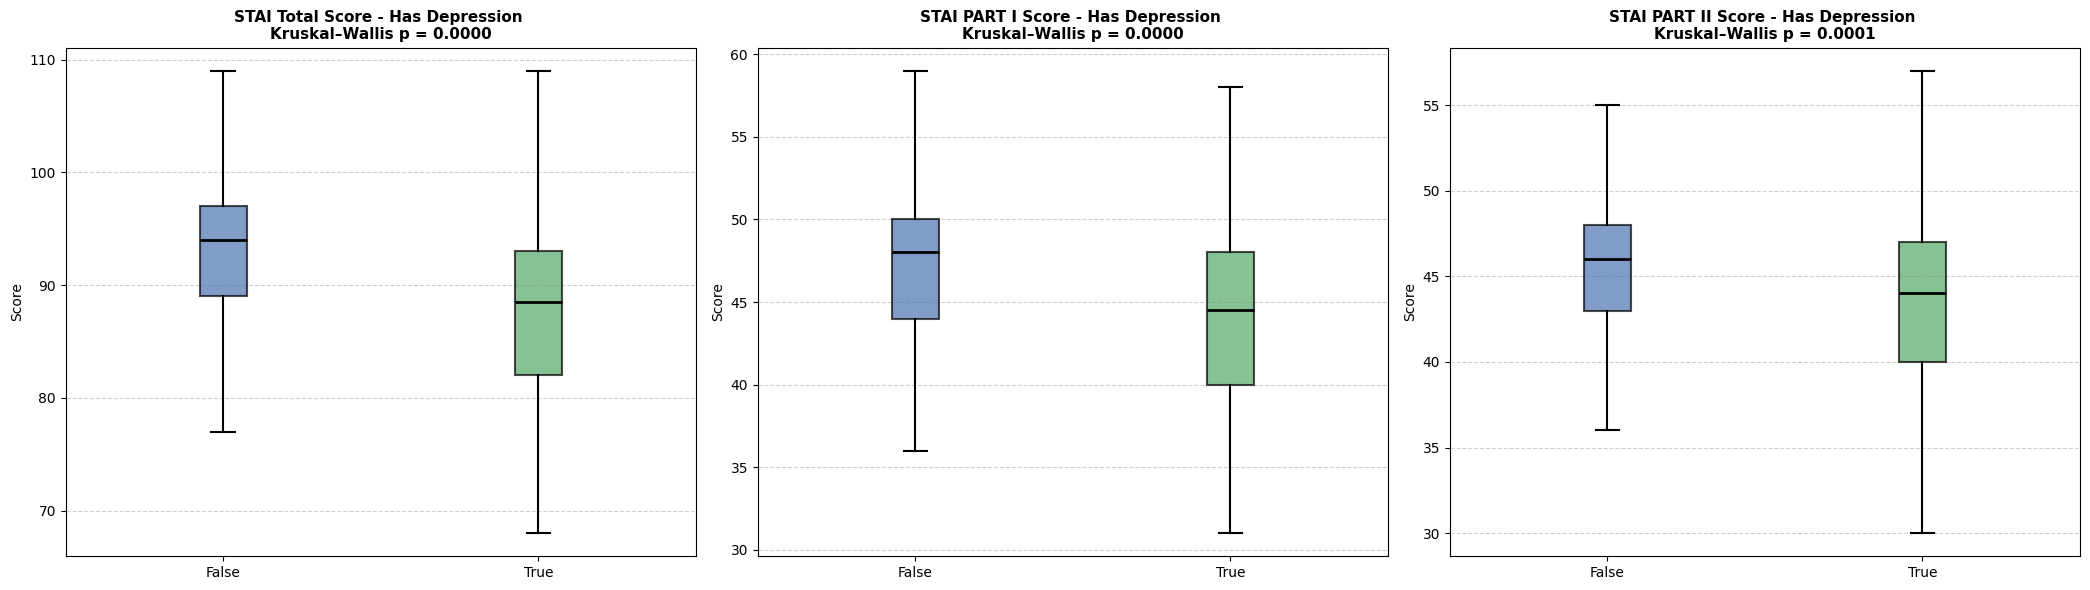


=== KRUSKAL–WALLIS RESULTS (YNProgression) ===
STAI Total Score: H = 32.529, p = 1.1744e-08  --> ✅ Significant (Dunn performed)
STAI PART I Score: H = 40.354, p = 2.1192e-10  --> ✅ Significant (Dunn performed)
STAI PART II Score: H = 14.410, p = 1.4700e-04  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for STAI Total Score ===


,False,True
False,1.0,0.0
True,0.0,1.0


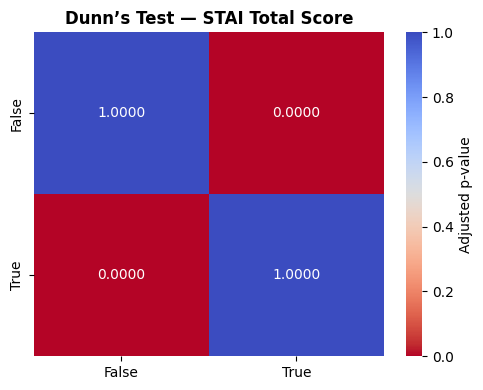


=== Dunn’s Test for STAI PART I Score ===


,False,True
False,1.0,0.0
True,0.0,1.0


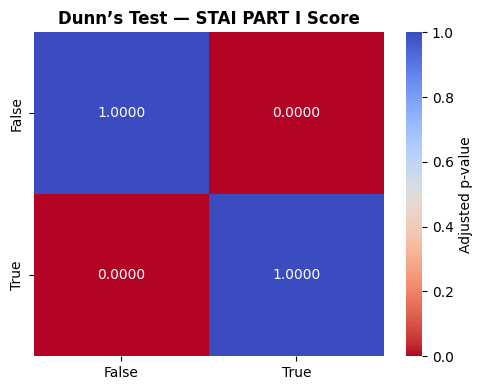


=== Dunn’s Test for STAI PART II Score ===


,False,True
False,1.0000,0.0001
True,0.0001,1.0000


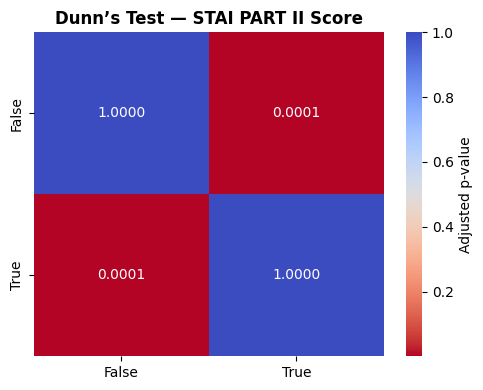

({'STAI Total Score': (32.52879458821178, 1.1743955683651e-08),
  'STAI PART I Score': (40.35354449090923, 2.119206165136183e-10),
  'STAI PART II Score': (14.410223244687273, 0.00014700208774246054)},
 {'STAI Total Score':        False  True 
  False    1.0    0.0
  True     0.0    1.0,
  'STAI PART I Score':        False  True 
  False    1.0    0.0
  True     0.0    1.0,
  'STAI PART II Score':         False   True 
  False  1.0000  0.0001
  True   0.0001  1.0000})

In [160]:
kruskal_dunn_ynprogression(comorbidity_df, 'Has Depression', ['STAI Total Score','STAI PART I Score','STAI PART II Score'])

# SLEEP DATA

In [161]:
sleep_data = pd.read_csv('/Users/fserracrespi/Desktop/PD_Project_UofL/PD_DATA/PD_1y_progress_DATA/Data_Sleep_1Year_12SEP2025.csv')
sleep_data.drop(columns=['Unnamed: 0'],inplace=True)
sleep_data.sort_values(by=['PATNO','Visit ID'],inplace=True)
# Aplicar la clasificación al dataframe
sleep_data = clasificar_updrs_thresholds(sleep_data)

sleep_data['UPDRS_I_ProgressionType'] = sleep_data['Δ UPDRS_I_1Y'].apply(lambda delta: categorize_progression(delta, -3,3 ))
sleep_data['UPDRS_II_ProgressionType'] = sleep_data['Δ UPDRS_II_1Y'].apply(lambda delta: categorize_progression(delta, -3,5 ))
sleep_data['UPDRS_III_ProgressionType'] = sleep_data['Δ UPDRS_III_1Y'].apply(lambda delta: categorize_progression(delta, -3,5 ))

sleep_data.head(3)

,PATNO,Visit ID,Sitting and reading,Watching TV,"Sitting, inactive in a public place",As a passenger in a car for an hour,Lying down to rest in the afternoon,Sitting and talking to someone,Sitting quietly after lunch,"In a car, while stopped in traffic",...,Δ UPDRS_II_1Y,Δ UPDRS_III_1Y,Δ UPDRS_IV_1Y,UPDRS_I_Class,UPDRS_II_Class,UPDRS_III_Class,UPDRS_IV_Class,UPDRS_I_ProgressionType,UPDRS_II_ProgressionType,UPDRS_III_ProgressionType
728,3001,V10_V12,1,2,1.0,0,2,0.0,0,0,...,-1.0,-9,0.0,Mild,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.
729,3003,V10_V12,1,1,0.0,3,1,0.0,0,0,...,-1.0,-14,0.0,Mild,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.
730,3010,V10_V12,2,3,1.0,0,3,1.0,1,0,...,4.0,16,-2.0,Moderate,Moderate,Mild,Moderate,No significant change.,No significant change.,Substantial progress.


In [162]:
sleep_data.to_csv('/Users/fserracrespi/Desktop/PD_Project_UofL/PD_DATA/MODELS DEVELOPMENT/DATA FOR MODELS/Sleep_Data.csv', index=False)

## REM 

In [163]:

rem_data = sleep_data[['PATNO','Visit ID','Vivid Dreams','Aggressive or Action-packed dreams','nocturnal behaviour',
                        'move arms/legs during sleep','hurt bed partner','speaking in sleep',
                        'sudden limb movements','complex movements','things fell down',
                        'my movements awake me','remember dreams','sleep is disturbed',
                        'Stroke','Head trauma','Parkinsonism','Restless Leg Syndrome (RLS)',
                        'Narcolepsy','Depression','Epilepsy','Inflammatory disease of the brain']]

DREAM_BEHAVIOR_VARS = [
    "Vivid Dreams",
    "Aggressive or Action-packed dreams",
    "nocturnal behaviour",
    "move arms/legs during sleep",
    "hurt bed partner",
    "speaking in sleep",
    "sudden limb movements",
    "complex movements",
    "things fell down",
    "my movements awake me",
    "remember dreams",
    "sleep is disturbed",
]

NEURO_VARS = [
    "Stroke",
    "Head trauma",
    "Parkinsonism",
    "Restless Leg Syndrome (RLS)",
    "Narcolepsy",
    "Depression",
    "Epilepsy",
    "Inflammatory disease of the brain",
]

rem_data["dream_behavior_score"] = rem_data[DREAM_BEHAVIOR_VARS].sum(axis=1)
rem_data["neuro_score"] = (rem_data[NEURO_VARS].sum(axis=1) > 0).astype(int)
rem_data["rbd_summary_score"] = (
    rem_data["dream_behavior_score"] + rem_data["neuro_score"]
)

rem_data["rbd_status"] = rem_data["rbd_summary_score"].apply(lambda x: "RBD Positive" if x >= 5 else "RBD Negative")
rem_data=rem_data.merge(sleep_data[['PATNO','Visit ID','UPDRS_I_Class',
                            'UPDRS_II_Class',
                            'UPDRS_III_Class',
                            'UPDRS_IV_Class',
                            'UPDRS_I_ProgressionType',
                            'UPDRS_II_ProgressionType',
                            'UPDRS_III_ProgressionType']], on=['PATNO','Visit ID'], how='inner')
rem_data.head(3)

rem_data['UPDRS_I_II']=rem_data['UPDRS_I_Class']+'_'+rem_data['UPDRS_II_Class']
rem_data.head(3)



/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1035369848.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rem_data["dream_behavior_score"] = rem_data[DREAM_BEHAVIOR_VARS].sum(axis=1)
/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1035369848.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rem_data["neuro_score"] = (rem_data[NEURO_VARS].sum(axis=1) > 0).astype(int)
/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1035369848.py:36: SettingWithCopyWa

,PATNO,Visit ID,Vivid Dreams,Aggressive or Action-packed dreams,nocturnal behaviour,move arms/legs during sleep,hurt bed partner,speaking in sleep,sudden limb movements,complex movements,...,rbd_summary_score,rbd_status,UPDRS_I_Class,UPDRS_II_Class,UPDRS_III_Class,UPDRS_IV_Class,UPDRS_I_ProgressionType,UPDRS_II_ProgressionType,UPDRS_III_ProgressionType,UPDRS_I_II
0,3001,V10_V12,1,0,0,1,0,1,1,0,...,7,RBD Positive,Mild,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.,Mild_Mild
1,3003,V10_V12,0,0,0,0,0,0,0,0,...,2,RBD Negative,Mild,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.,Mild_Mild
2,3010,V10_V12,1,0,0,1,0,0,1,0,...,8,RBD Positive,Moderate,Moderate,Mild,Moderate,No significant change.,No significant change.,Substantial progress.,Moderate_Moderate


### REM Distribution

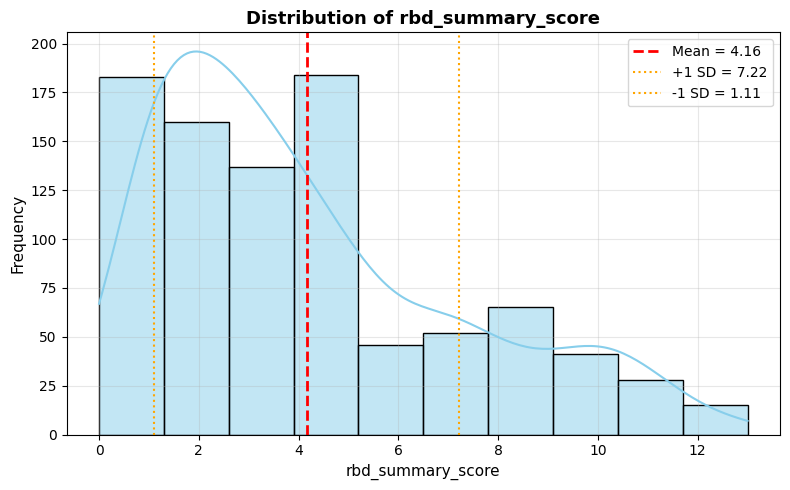

Statistical descriptors:
count    911.000000
mean       4.163557
std        3.055643
min        0.000000
25%        2.000000
50%        3.000000
75%        6.000000
max       13.000000
Name: rbd_summary_score, dtype: float64


In [164]:
plot_hist_with_stats(rem_data, 'rbd_summary_score', bins=10)

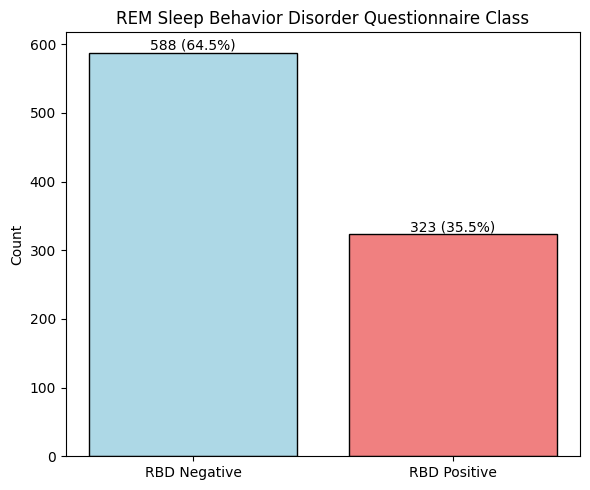

In [165]:
# Colores fijos
colors_eps = {
    "RBD Negative": "lightblue",
    "RBD Positive": "lightcoral"
}

# Conteos en orden fijo
counts = rem_data['rbd_status'].value_counts() \
            .reindex(["RBD Negative","RBD Positive"]) \
            .fillna(0) \
            .astype(int)

total = counts.sum()

fig, ax = plt.subplots(figsize=(6, 5))

# Barras
bars = ax.bar(
    counts.index,
    counts.values,
    color=[colors_eps[x] for x in counts.index],
    edgecolor='black'
)

ax.set_title("REM Sleep Behavior Disorder Questionnaire Class", fontsize=12)
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=0)

# Añadir conteo y porcentaje
for bar, count in zip(bars, counts.values):
    pct = (count / total) * 100 if total > 0 else 0
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count} ({pct:.1f}%)",
        ha="center", va="bottom", fontsize=10
    )

plt.tight_layout()
plt.show()



### UPDRS Class - REM

/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


Kurksal Dunn analysis for RBD Status by UPDRS_I_Class:


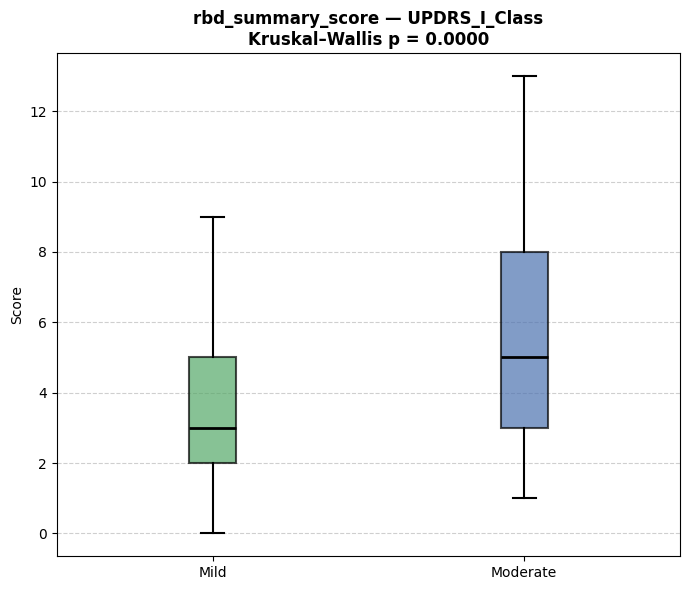


=== KRUSKAL–WALLIS RESULTS ===
rbd_summary_score: H = 36.301, p = 1.6909e-09  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for rbd_summary_score ===


,Mild,Moderate
Mild,1.0,0.0
Moderate,0.0,1.0


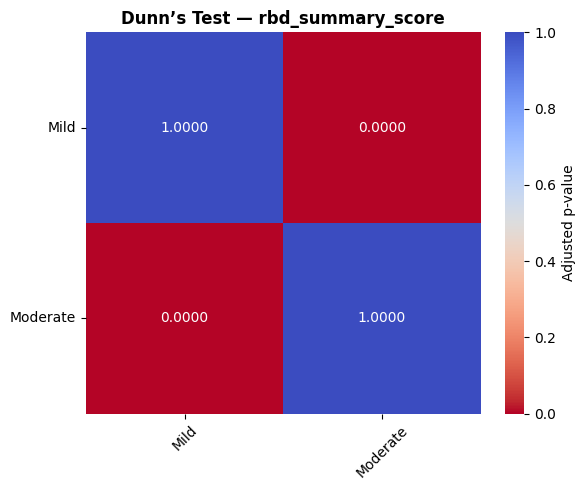

Kurksal Dunn analysis for RBD Status by UPDRS_II_Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


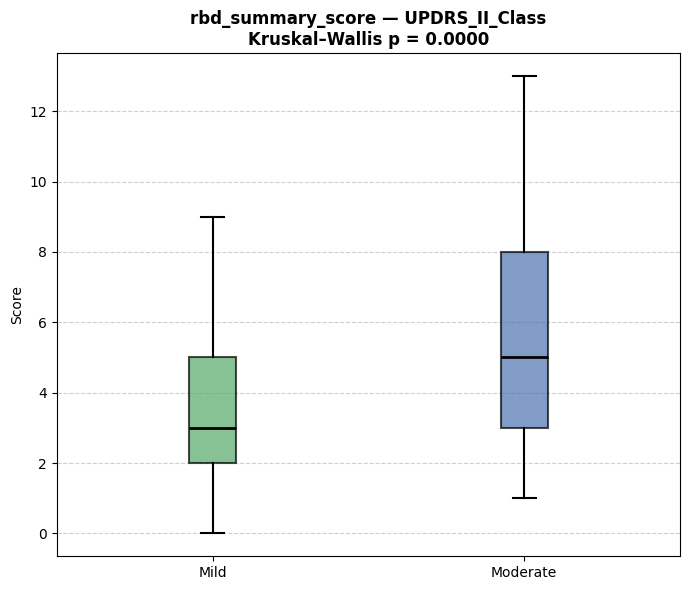


=== KRUSKAL–WALLIS RESULTS ===
rbd_summary_score: H = 33.319, p = 7.8229e-09  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for rbd_summary_score ===


,Mild,Moderate
Mild,1.0,0.0
Moderate,0.0,1.0


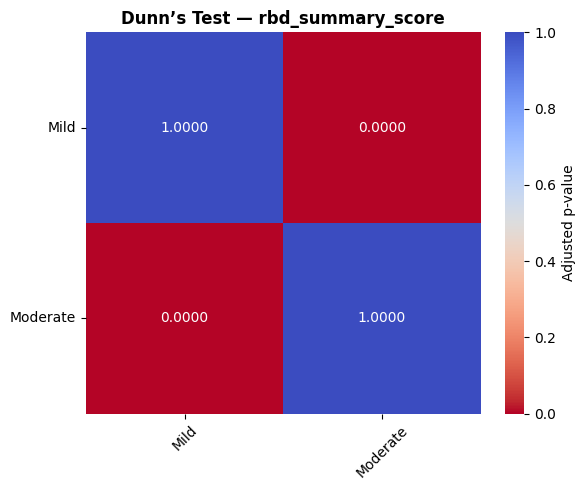

Kurksal Dunn analysis for RBD Status by UPDRS_III_Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


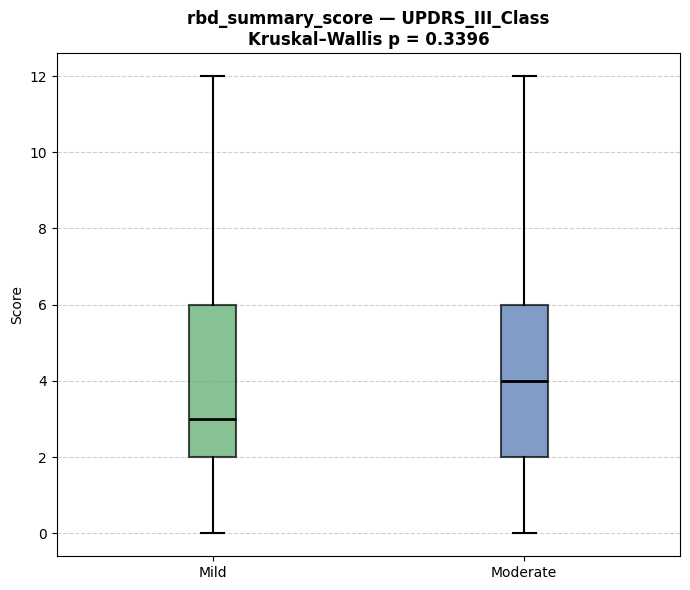


=== KRUSKAL–WALLIS RESULTS ===
rbd_summary_score: H = 0.912, p = 3.3958e-01  --> 🛑 Not significant


In [166]:
for col in updrs_class:
    print(f'Kurksal Dunn analysis for RBD Status by {col}:')
    kruskal_dunn_by_class(rem_data, col, ['rbd_summary_score'], class_order=['Mild','Moderate'])

/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


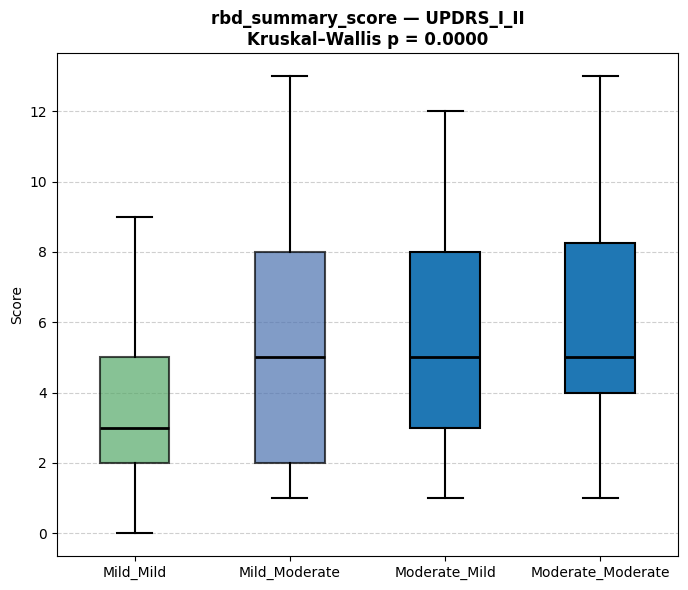


=== KRUSKAL–WALLIS RESULTS ===
rbd_summary_score: H = 51.999, p = 2.9970e-11  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for rbd_summary_score ===


,Mild_Mild,Mild_Moderate,Moderate_Mild,Moderate_Moderate
Mild_Mild,1.0000,0.0010,0.0007,0.0000
Mild_Moderate,0.0010,1.0000,1.0000,0.2968
Moderate_Mild,0.0007,1.0000,1.0000,1.0000
Moderate_Moderate,0.0000,0.2968,1.0000,1.0000


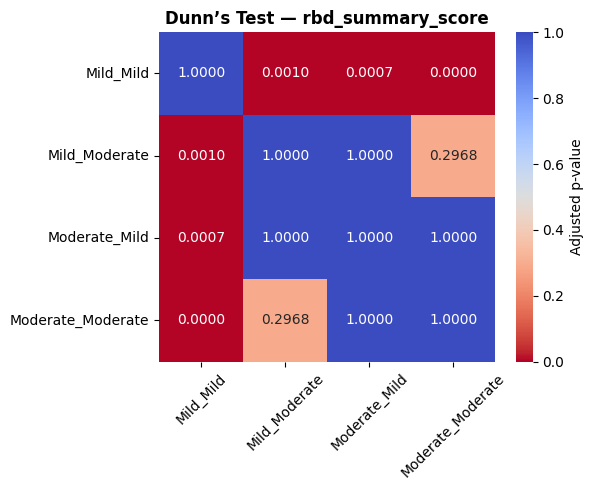

({'rbd_summary_score': (51.99867893909242, 2.997022403515341e-11)},
 {'rbd_summary_score':                    Mild_Mild  Mild_Moderate  Moderate_Mild  Moderate_Moderate
  Mild_Mild             1.0000         0.0010         0.0007             0.0000
  Mild_Moderate         0.0010         1.0000         1.0000             0.2968
  Moderate_Mild         0.0007         1.0000         1.0000             1.0000
  Moderate_Moderate     0.0000         0.2968         1.0000             1.0000})

In [167]:
kruskal_dunn_by_class(rem_data, 'UPDRS_I_II', ['rbd_summary_score'], class_order=None)

### Chi2 UPDRS Class - REM

Chi2 analysis for RBD Status by UPDRS_I_Class:

 Chi-square test for: rbd_status vs UPDRS_I_Class

Chi² statistic = 23.332
p-value = 0.0000
Degrees of freedom = 1
Cramér's V = 0.164
Effect size: Weak
 ✅ Significant association (p < 0.05)

Contingency table (ordered):


UPDRS_I_Class,Mild,Moderate
rbd_status,,
RBD Negative,543,45
RBD Positive,263,60


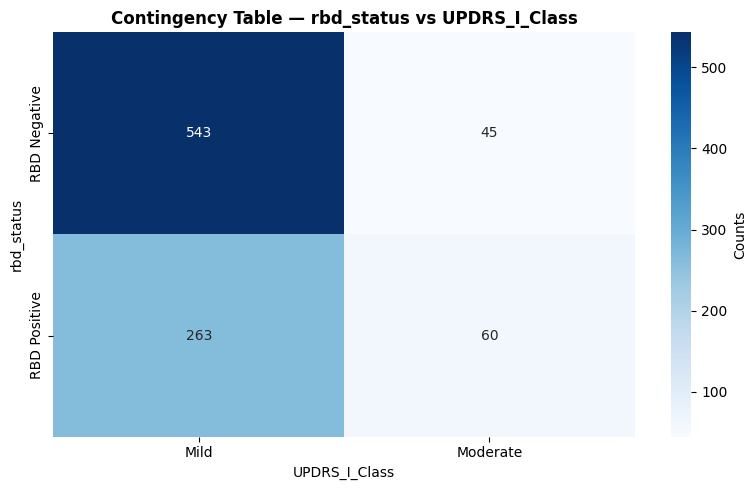

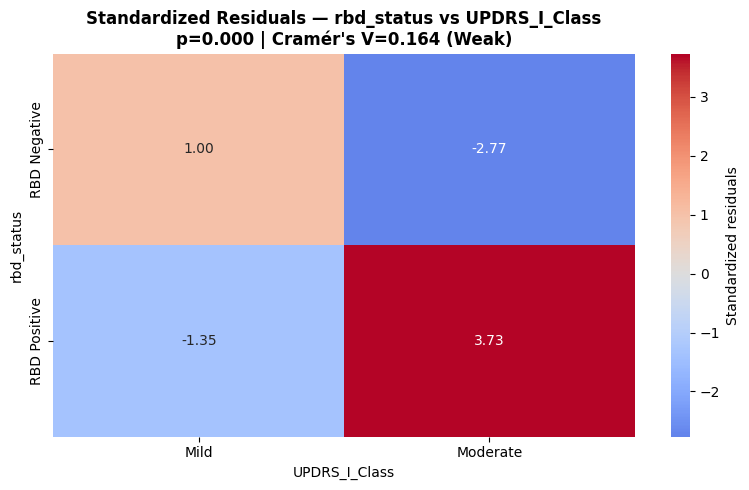


--------------------------------------------------------------------------------

Chi2 analysis for RBD Status by UPDRS_II_Class:

 Chi-square test for: rbd_status vs UPDRS_II_Class

Chi² statistic = 23.616
p-value = 0.0000
Degrees of freedom = 1
Cramér's V = 0.164
Effect size: Weak
 ✅ Significant association (p < 0.05)

Contingency table (ordered):


UPDRS_II_Class,Mild,Moderate
rbd_status,,
RBD Negative,528,60
RBD Positive,251,72


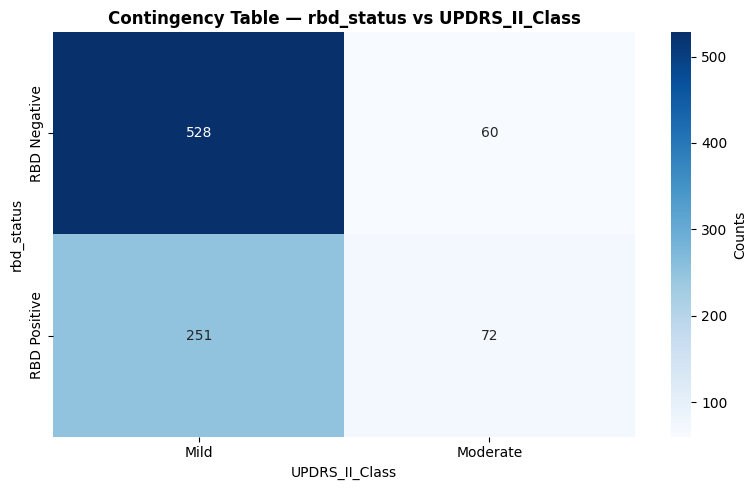

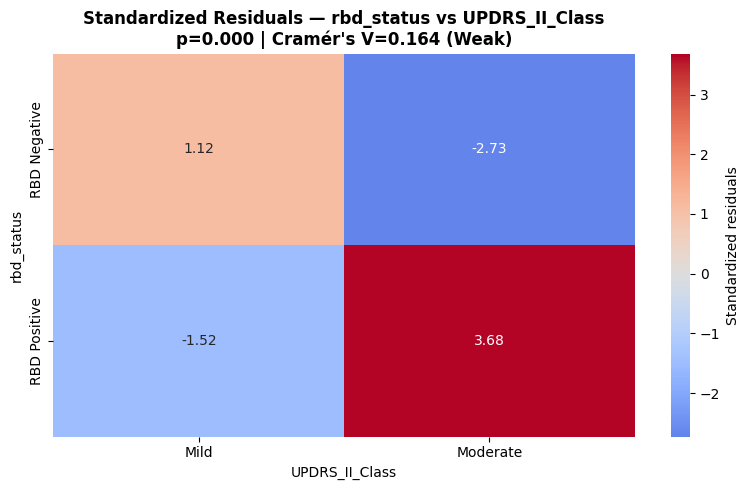


--------------------------------------------------------------------------------

Chi2 analysis for RBD Status by UPDRS_III_Class:

 Chi-square test for: rbd_status vs UPDRS_III_Class

Chi² statistic = 0.188
p-value = 0.6649
Degrees of freedom = 1
Cramér's V = 0.018
Effect size: Weak
 🛑 No significant association (p ≥ 0.05)
    → No tables or heatmaps displayed.

--------------------------------------------------------------------------------



In [168]:
for col in updrs_class:
    print(f'Chi2 analysis for RBD Status by {col}:')
    chi_square_heatmap(rem_data, 'rbd_status', col , order_1=None, order_2=['Mild','Moderate'])


 Chi-square test for: rbd_status vs UPDRS_I_II

Chi² statistic = 38.122
p-value = 0.0000
Degrees of freedom = 3
Cramér's V = 0.205
Effect size: Moderate
 ✅ Significant association (p < 0.05)

Contingency table (ordered):


UPDRS_I_II,Mild_Mild,Mild_Moderate,Moderate_Mild,Moderate_Moderate
rbd_status,,,,
RBD Negative,504,39,24,21
RBD Positive,222,41,29,31


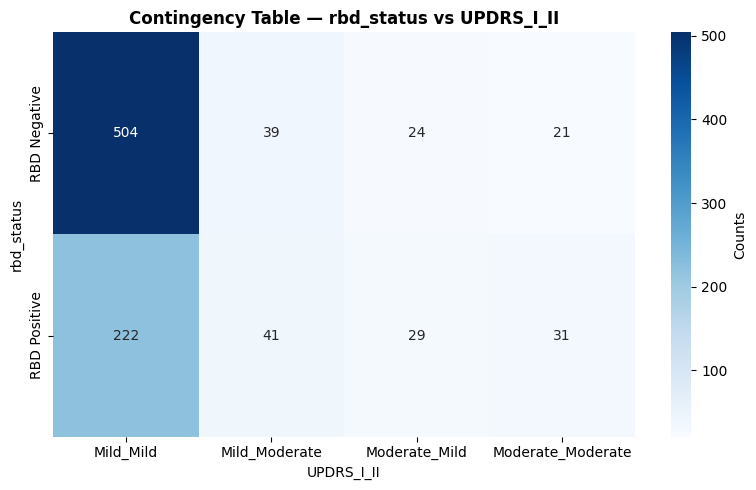

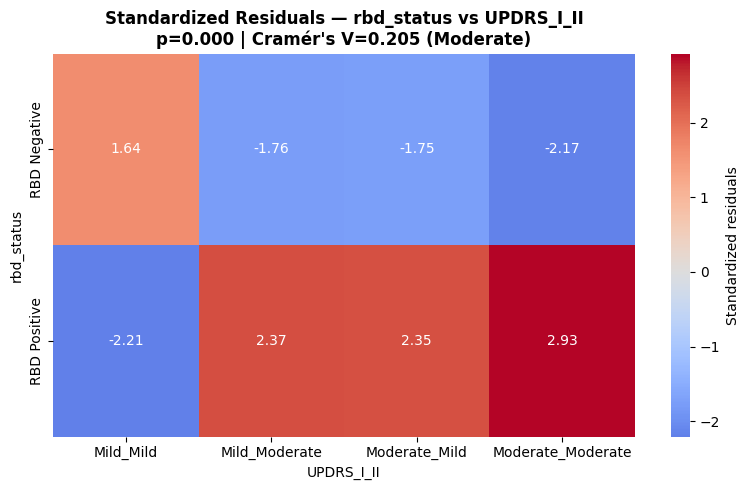


--------------------------------------------------------------------------------



In [169]:
chi_square_heatmap(rem_data, 'rbd_status', 'UPDRS_I_II' , order_1=None, order_2=None)

### UPDRS Progression - REM

Kurksal Dunn analysis for RBD Status by UPDRS_I_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


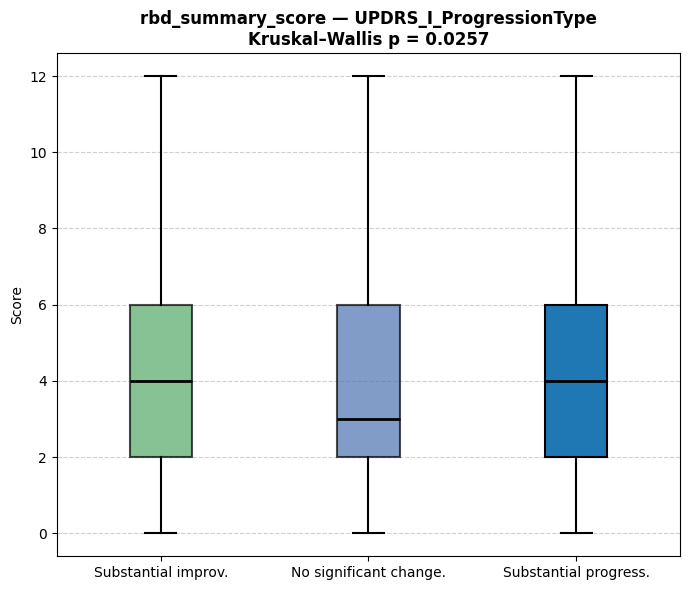


=== KRUSKAL–WALLIS RESULTS ===
rbd_summary_score: H = 7.323, p = 2.5692e-02  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for rbd_summary_score ===


,No significant change.,Substantial improv.,Substantial progress.
No significant change.,1.0000,0.096,0.1571
Substantial improv.,0.0960,1.000,1.0000
Substantial progress.,0.1571,1.000,1.0000


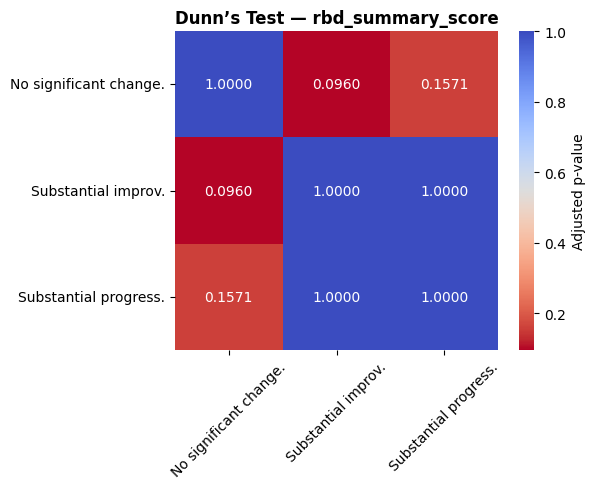

Kurksal Dunn analysis for RBD Status by UPDRS_II_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


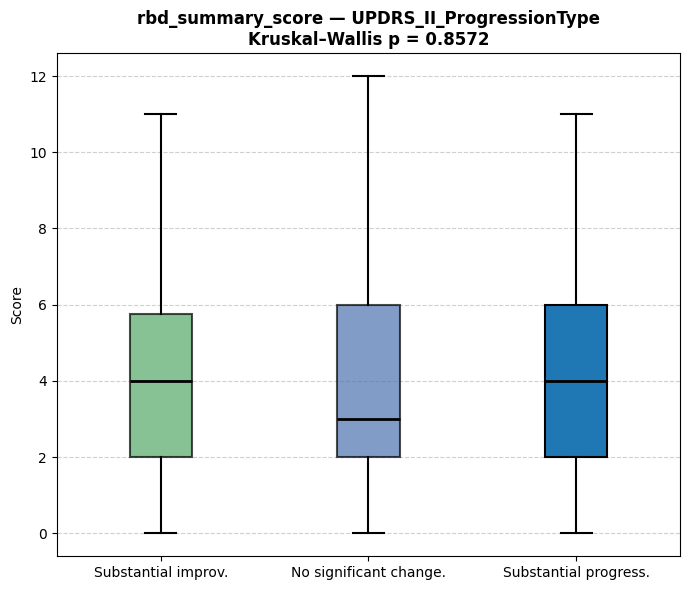


=== KRUSKAL–WALLIS RESULTS ===
rbd_summary_score: H = 0.308, p = 8.5723e-01  --> 🛑 Not significant
Kurksal Dunn analysis for RBD Status by UPDRS_III_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


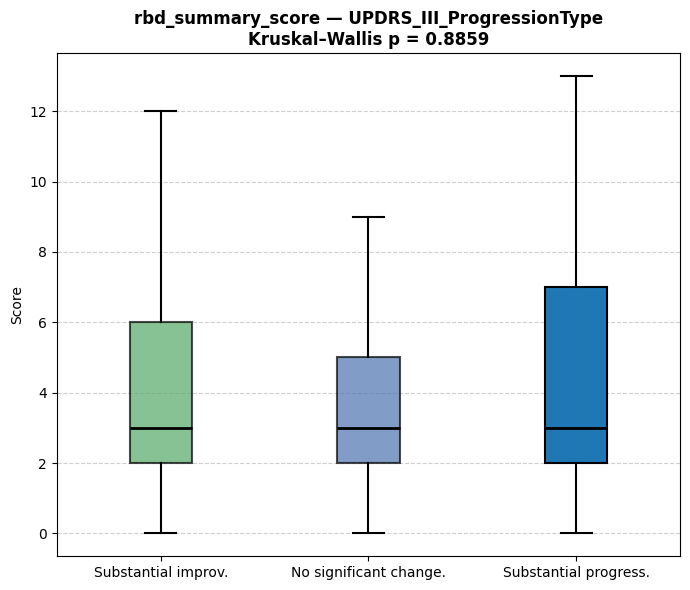


=== KRUSKAL–WALLIS RESULTS ===
rbd_summary_score: H = 0.242, p = 8.8586e-01  --> 🛑 Not significant


In [170]:
for col in progression_types:
    print(f'Kurksal Dunn analysis for RBD Status by {col}:')
    kruskal_dunn_by_class(rem_data, col, ['rbd_summary_score'], class_order=['Substantial improv.' ,'No significant change.','Substantial progress.'])

### Chi2 UPDRS Progression - REM

In [171]:
for col in progression_types:
    print(f'Chi2 analysis for RBD Status by {col}:')
    chi_square_heatmap(rem_data, 'rbd_status', col , order_1=None, order_2=['Substantial improv.' ,'No significant change.','Substantial progress.'])

Chi2 analysis for RBD Status by UPDRS_I_ProgressionType:

 Chi-square test for: rbd_status vs UPDRS_I_ProgressionType

Chi² statistic = 4.428
p-value = 0.1092
Degrees of freedom = 2
Cramér's V = 0.070
Effect size: Weak
 🛑 No significant association (p ≥ 0.05)
    → No tables or heatmaps displayed.

--------------------------------------------------------------------------------

Chi2 analysis for RBD Status by UPDRS_II_ProgressionType:

 Chi-square test for: rbd_status vs UPDRS_II_ProgressionType

Chi² statistic = 0.504
p-value = 0.7774
Degrees of freedom = 2
Cramér's V = 0.024
Effect size: Weak
 🛑 No significant association (p ≥ 0.05)
    → No tables or heatmaps displayed.

--------------------------------------------------------------------------------

Chi2 analysis for RBD Status by UPDRS_III_ProgressionType:

 Chi-square test for: rbd_status vs UPDRS_III_ProgressionType

Chi² statistic = 1.947
p-value = 0.3778
Degrees of freedom = 2
Cramér's V = 0.046
Effect size: Weak
 🛑 No signi

## EPWORTH

In [172]:
epworth_data = sleep_data[['PATNO','Visit ID','Sitting and reading',
                            'Watching TV',
                            'Sitting, inactive in a public place',
                            'As a passenger in a car for an hour',
                            'Lying down to rest in the afternoon',
                            'Sitting and talking to someone',
                            'Sitting quietly after lunch',
                            'In a car, while stopped in traffic',
                            'Epworth Sleepiness Scale Score','MDS-UPDRS Total Score',
                            'MDS-UPDRS Part I (Patient Questionnaire) Total Score',
                            'MDS-UPDRS Part II Total Score',
                            'MDS-UPDRS Part III Total Score',
                            'MDS-UPDRS Total Score 1YearProg',
                            'UPDRS_III_1YearProg',
                            'MDS-UPDRS Total Score',
                            'Δ TOTAL_UPDRS_1Y',
                            'Δ UPDRS_I_1Y',
                            'Δ UPDRS_II_1Y',
                            'Δ UPDRS_III_1Y',
                            'Δ UPDRS_IV_1Y',
                            'UPDRS_I_Class',
                            'UPDRS_II_Class',
                            'UPDRS_III_Class',
                            'UPDRS_IV_Class',
                            'UPDRS_I_ProgressionType',
                            'UPDRS_II_ProgressionType',
                            'UPDRS_III_ProgressionType']]

epworth_data['eps_class']= epworth_data['Epworth Sleepiness Scale Score'].apply(lambda x: 'Normal' if x<=11 else 'Excessive Sleepiness')
epworth_data.head(3)

/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/96510647.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  epworth_data['eps_class']= epworth_data['Epworth Sleepiness Scale Score'].apply(lambda x: 'Normal' if x<=11 else 'Excessive Sleepiness')


,PATNO,Visit ID,Sitting and reading,Watching TV,"Sitting, inactive in a public place",As a passenger in a car for an hour,Lying down to rest in the afternoon,Sitting and talking to someone,Sitting quietly after lunch,"In a car, while stopped in traffic",...,Δ UPDRS_III_1Y,Δ UPDRS_IV_1Y,UPDRS_I_Class,UPDRS_II_Class,UPDRS_III_Class,UPDRS_IV_Class,UPDRS_I_ProgressionType,UPDRS_II_ProgressionType,UPDRS_III_ProgressionType,eps_class
728,3001,V10_V12,1,2,1.0,0,2,0.0,0,0,...,-9,0.0,Mild,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.,Normal
729,3003,V10_V12,1,1,0.0,3,1,0.0,0,0,...,-14,0.0,Mild,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.,Normal
730,3010,V10_V12,2,3,1.0,0,3,1.0,1,0,...,16,-2.0,Moderate,Moderate,Mild,Moderate,No significant change.,No significant change.,Substantial progress.,Normal


### EPWORTH Distribution

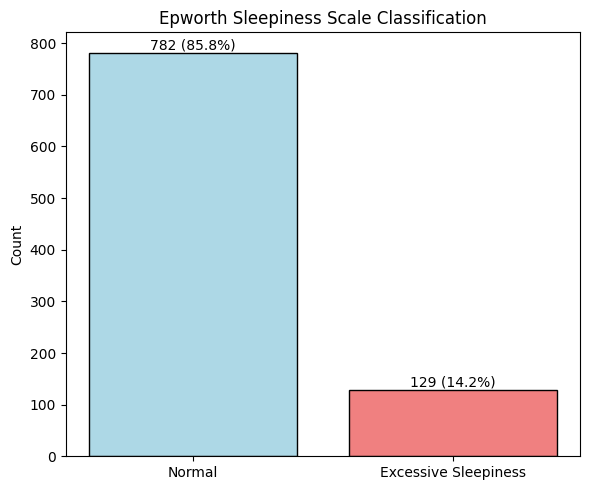

In [173]:
# Colores fijos
colors_eps = {
    "Normal": "lightblue",
    "Excessive Sleepiness": "lightcoral"
}

# Conteos en orden fijo
counts = epworth_data['eps_class'].value_counts() \
            .reindex(["Normal", "Excessive Sleepiness"]) \
            .fillna(0) \
            .astype(int)

total = counts.sum()

fig, ax = plt.subplots(figsize=(6, 5))

# Barras
bars = ax.bar(
    counts.index,
    counts.values,
    color=[colors_eps[x] for x in counts.index],
    edgecolor='black'
)

ax.set_title("Epworth Sleepiness Scale Classification", fontsize=12)
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=0)

# Añadir conteo y porcentaje
for bar, count in zip(bars, counts.values):
    pct = (count / total) * 100 if total > 0 else 0
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count} ({pct:.1f}%)",
        ha="center", va="bottom", fontsize=10
    )

plt.tight_layout()
plt.show()



#### UPDRS Class - Epworth Class

Kruskal-Dunn analysis for Epworth Sleepiness Scale Score by UPDRS_I_Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


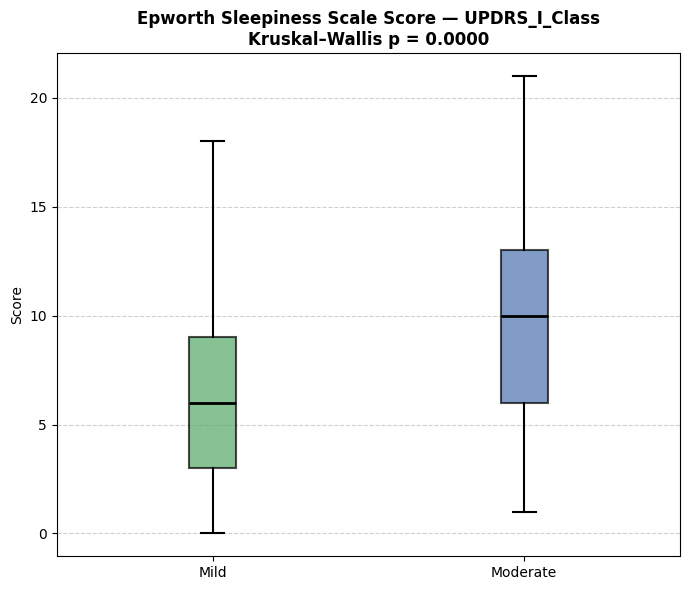


=== KRUSKAL–WALLIS RESULTS ===
Epworth Sleepiness Scale Score: H = 46.742, p = 8.0955e-12  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for Epworth Sleepiness Scale Score ===


,Mild,Moderate
Mild,1.0,0.0
Moderate,0.0,1.0


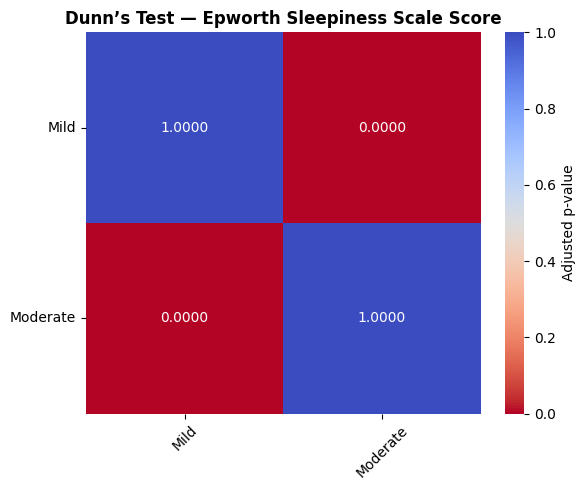

/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


Kruskal-Dunn analysis for Epworth Sleepiness Scale Score by UPDRS_II_Class:


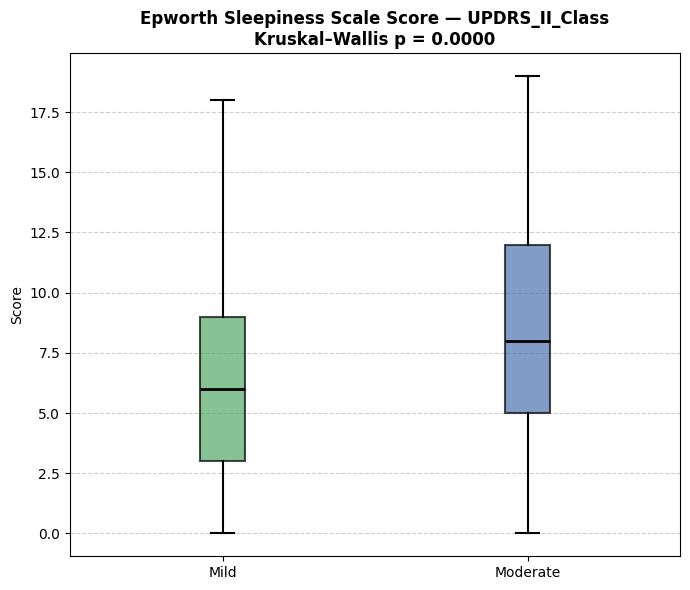


=== KRUSKAL–WALLIS RESULTS ===
Epworth Sleepiness Scale Score: H = 22.881, p = 1.7230e-06  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for Epworth Sleepiness Scale Score ===


,Mild,Moderate
Mild,1.0,0.0
Moderate,0.0,1.0


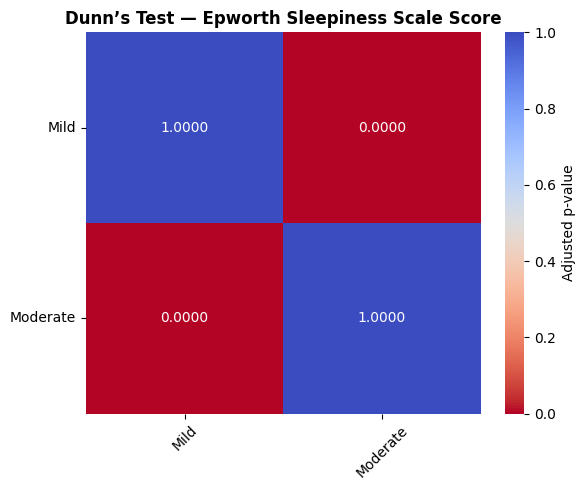

Kruskal-Dunn analysis for Epworth Sleepiness Scale Score by UPDRS_III_Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


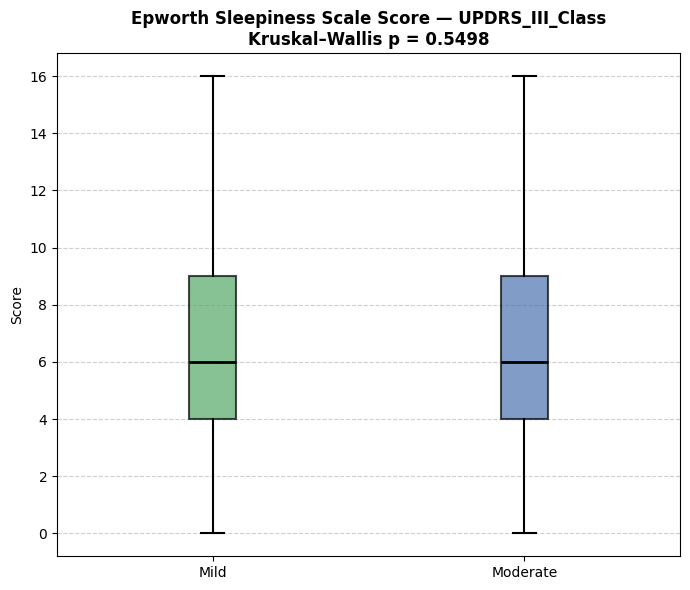


=== KRUSKAL–WALLIS RESULTS ===
Epworth Sleepiness Scale Score: H = 0.358, p = 5.4982e-01  --> 🛑 Not significant


In [174]:
for col in updrs_class:
    print(f'Kruskal-Dunn analysis for Epworth Sleepiness Scale Score by {col}:')
    kruskal_dunn_by_class(epworth_data, col, ['Epworth Sleepiness Scale Score'], class_order=['Mild','Moderate'])

### Chi2 UPDRS class - EPWORTH

Chi2 analysis for Epworth Sleepiness Scale Score by UPDRS_I_Class:

 Chi-square test for: eps_class vs UPDRS_I_Class

Chi² statistic = 41.440
p-value = 0.0000
Degrees of freedom = 1
Cramér's V = 0.218
Effect size: Moderate
 ✅ Significant association (p < 0.05)

Contingency table (ordered):


UPDRS_I_Class,Mild,Moderate
eps_class,,
Excessive Sleepiness,92,37
Normal,714,68


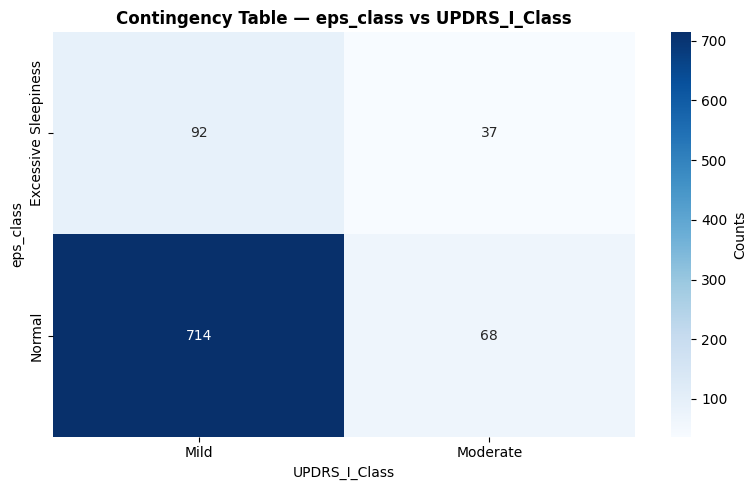

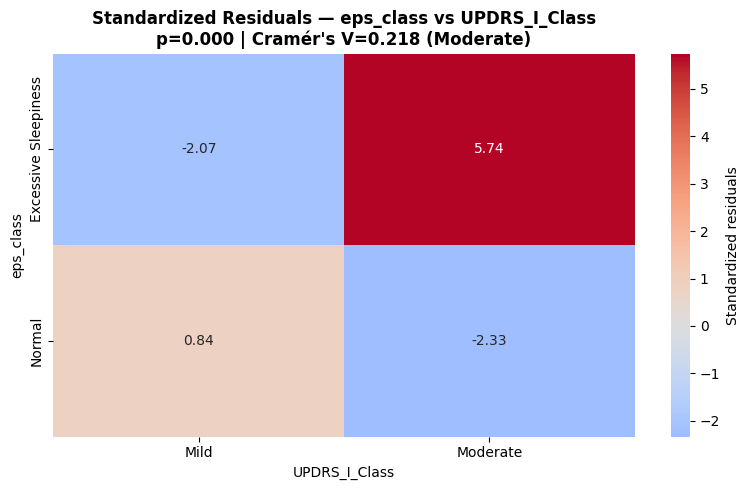


--------------------------------------------------------------------------------

Chi2 analysis for Epworth Sleepiness Scale Score by UPDRS_II_Class:

 Chi-square test for: eps_class vs UPDRS_II_Class

Chi² statistic = 18.215
p-value = 0.0000
Degrees of freedom = 1
Cramér's V = 0.146
Effect size: Weak
 ✅ Significant association (p < 0.05)

Contingency table (ordered):


UPDRS_II_Class,Mild,Moderate
eps_class,,
Excessive Sleepiness,94,35
Normal,685,97


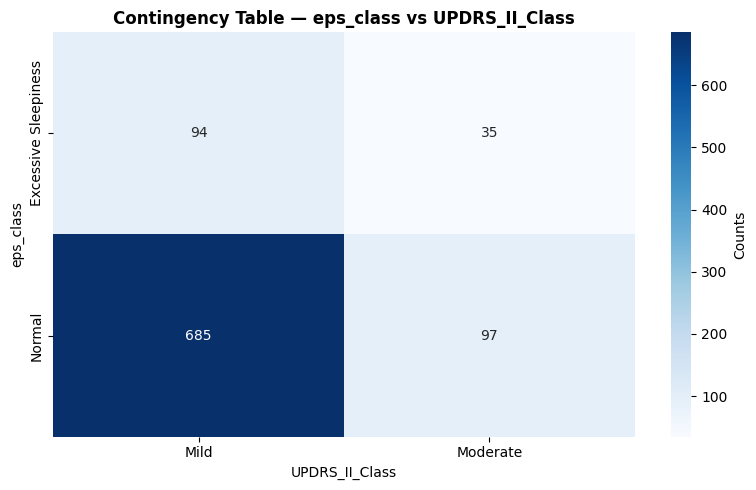

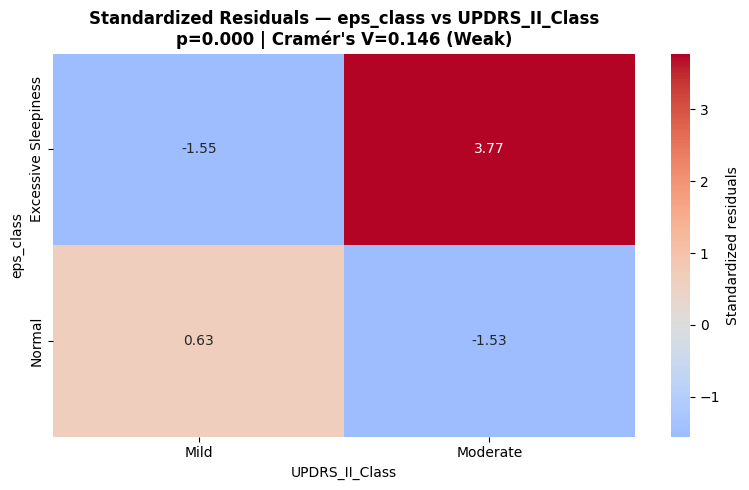


--------------------------------------------------------------------------------

Chi2 analysis for Epworth Sleepiness Scale Score by UPDRS_III_Class:

 Chi-square test for: eps_class vs UPDRS_III_Class

Chi² statistic = 0.330
p-value = 0.5655
Degrees of freedom = 1
Cramér's V = 0.024
Effect size: Weak
 🛑 No significant association (p ≥ 0.05)
    → No tables or heatmaps displayed.

--------------------------------------------------------------------------------



In [175]:
for col in updrs_class:
    print(f'Chi2 analysis for Epworth Sleepiness Scale Score by {col}:')
    chi_square_heatmap(epworth_data, 'eps_class', col , order_1=None, order_2=['Mild','Moderate'])

### UPDRS Progression - EPWORTH

Chi2 analysis for Epworth Sleepiness Scale Score by UPDRS_I_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


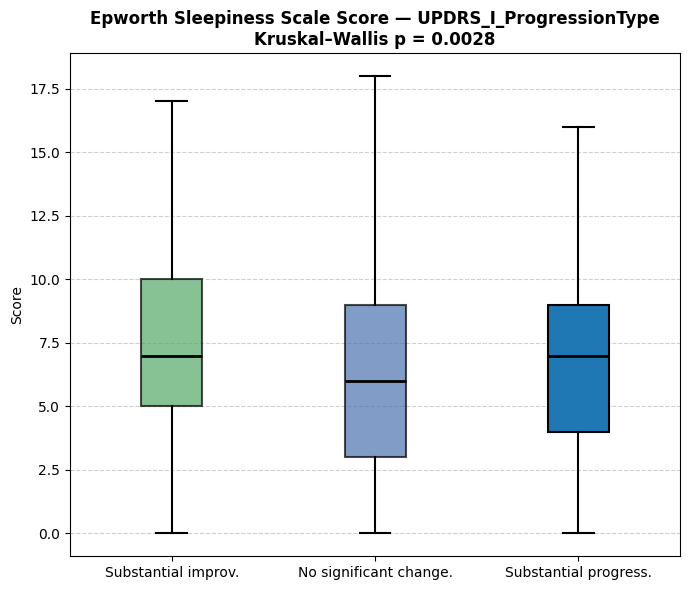


=== KRUSKAL–WALLIS RESULTS ===
Epworth Sleepiness Scale Score: H = 11.734, p = 2.8308e-03  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for Epworth Sleepiness Scale Score ===


,No significant change.,Substantial improv.,Substantial progress.
No significant change.,1.0000,0.0067,0.1466
Substantial improv.,0.0067,1.0000,1.0000
Substantial progress.,0.1466,1.0000,1.0000


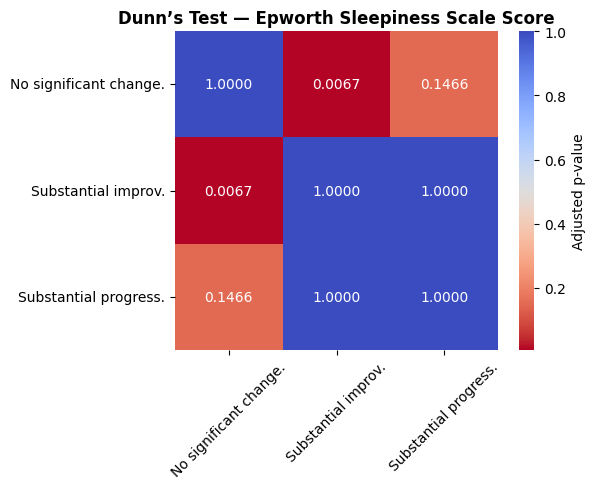

Chi2 analysis for Epworth Sleepiness Scale Score by UPDRS_II_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


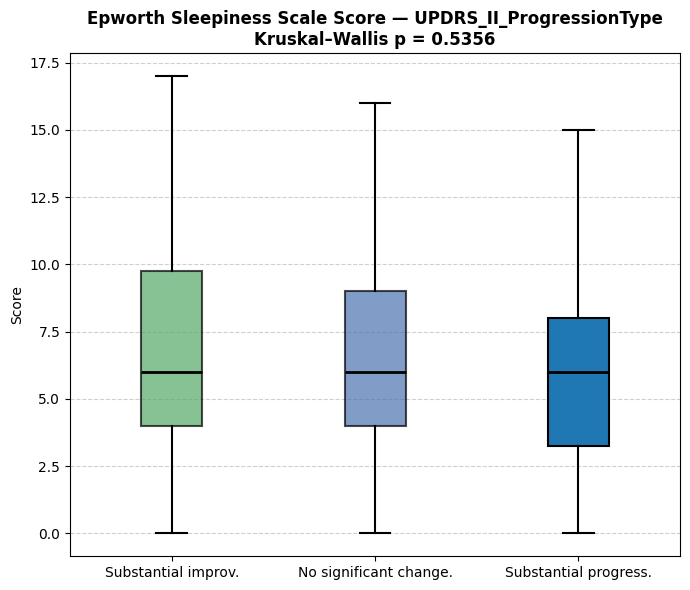


=== KRUSKAL–WALLIS RESULTS ===
Epworth Sleepiness Scale Score: H = 1.249, p = 5.3555e-01  --> 🛑 Not significant
Chi2 analysis for Epworth Sleepiness Scale Score by UPDRS_III_ProgressionType:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


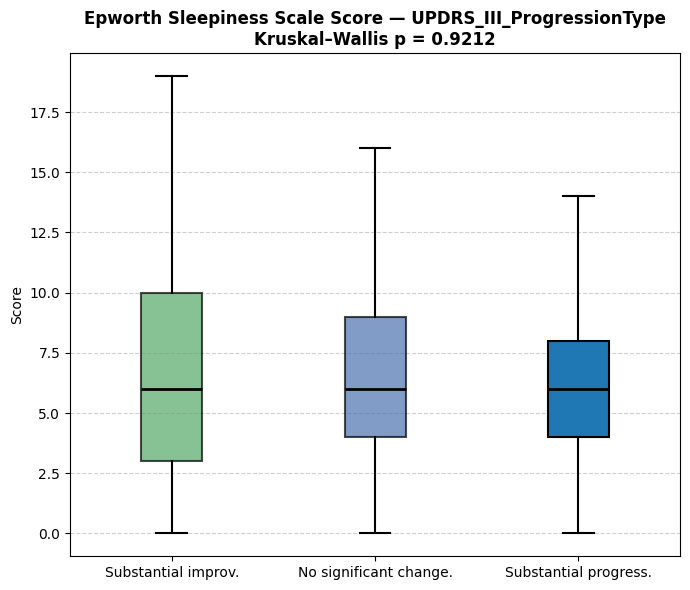


=== KRUSKAL–WALLIS RESULTS ===
Epworth Sleepiness Scale Score: H = 0.164, p = 9.2118e-01  --> 🛑 Not significant


In [176]:
for col in progression_types:
    print(f'Chi2 analysis for Epworth Sleepiness Scale Score by {col}:')
    kruskal_dunn_by_class(epworth_data, col, ['Epworth Sleepiness Scale Score'], class_order=['Substantial improv.' ,'No significant change.','Substantial progress.'])
    

### chi2 UPDRS Progression - EPWORTH

In [177]:
for col in progression_types:
    print(f'Chi2 analysis for Epworth Sleepiness Scale Score by {col}:')
    chi_square_heatmap(epworth_data, 'eps_class', col , order_1=None, order_2=['Substantial improv.' ,'No significant change.','Substantial progress.'])

Chi2 analysis for Epworth Sleepiness Scale Score by UPDRS_I_ProgressionType:

 Chi-square test for: eps_class vs UPDRS_I_ProgressionType

Chi² statistic = 3.228
p-value = 0.1991
Degrees of freedom = 2
Cramér's V = 0.060
Effect size: Weak
 🛑 No significant association (p ≥ 0.05)
    → No tables or heatmaps displayed.

--------------------------------------------------------------------------------

Chi2 analysis for Epworth Sleepiness Scale Score by UPDRS_II_ProgressionType:

 Chi-square test for: eps_class vs UPDRS_II_ProgressionType

Chi² statistic = 1.584
p-value = 0.4530
Degrees of freedom = 2
Cramér's V = 0.042
Effect size: Weak
 🛑 No significant association (p ≥ 0.05)
    → No tables or heatmaps displayed.

--------------------------------------------------------------------------------

Chi2 analysis for Epworth Sleepiness Scale Score by UPDRS_III_ProgressionType:

 Chi-square test for: eps_class vs UPDRS_III_ProgressionType

Chi² statistic = 1.157
p-value = 0.5606
Degrees of fre

# Medication 

In [178]:
medical_data = pd.read_csv('/Users/fserracrespi/Desktop/PD_Project_UofL/PD_DATA/PD_1y_progress_DATA/Data_Medication_1Year_12SEP2025.csv')
medical_data.drop(columns=['Unnamed: 0'],inplace=True)
medical_data.sort_values(by=['PATNO','Visit ID'],inplace=True)
# Aplicar la clasificación al dataframe
medical_data = clasificar_updrs_thresholds(medical_data)
medical_data['UPDRS_I_ProgressionType'] = medical_data['Δ UPDRS_I_1Y'].apply(lambda delta: categorize_progression(delta, -3,3 ))
medical_data['UPDRS_II_ProgressionType'] = medical_data['Δ UPDRS_II_1Y'].apply(lambda delta: categorize_progression(delta, -3,5 ))
medical_data['UPDRS_III_ProgressionType'] = medical_data['Δ UPDRS_III_1Y'].apply(lambda delta: categorize_progression(delta, -3,5 ))
medical_data.head(3)

,PATNO,Visit ID,Month_11_Medication,Month_11_Dose_Strength_mg_amantadine,Month_11_Total_mg_per_day_amantadine,Month_11_Dose_Strength_mg_selegiline,Month_11_Total_mg_per_day_selegiline,Month_11_Dose_Strength_mg_rotigotine,Month_11_Total_mg_per_day_rotigotine,Month_11_Dose_Strength_mg_pramipexole,...,Δ UPDRS_II_1Y,Δ UPDRS_III_1Y,Δ UPDRS_IV_1Y,UPDRS_I_Class,UPDRS_II_Class,UPDRS_III_Class,UPDRS_IV_Class,UPDRS_I_ProgressionType,UPDRS_II_ProgressionType,UPDRS_III_ProgressionType
728,3001,V10_V12,"['selegiline', 'carbidopa levodopa']",0.0,0.0,5.0,100.0,0.0,0.0,0.0,...,-1.0,-9,0.0,Mild,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.
729,3003,V10_V12,"['amantadine', 'carbidopa levodopa']",105.0,210.0,0.0,0.0,0.0,0.0,0.0,...,-1.0,-14,0.0,Mild,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.
730,3010,V10_V12,"['pramipexole', 'carbidopa levodopa']",0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,4.0,16,-2.0,Moderate,Moderate,Mild,Moderate,No significant change.,No significant change.,Substantial progress.


## Normal Medication

In [179]:
normal_meds = medical_data[['PATNO','Visit ID','Cardiovascular','Digestiva',
                            'Preventiva / Suplementos',
                            'Neurológica / Psiquiátrica',
                            'Endocrina / Metabólica',
                            'Urinaria / Genitourinaria',
                            'Musculoesquelética / Dolor',
                            'Dermatológica',
                            'Infecciosa',
                            'Ginecológica / Hormonales', 
                            'UPDRS_I_Class',
                            'UPDRS_II_Class',
                            'UPDRS_III_Class',
                            'UPDRS_IV_Class',
                            'UPDRS_I_ProgressionType',
                            'UPDRS_II_ProgressionType',
                            'UPDRS_III_ProgressionType']]

cols_normal_meds=normal_meds.columns.tolist()
normal_meds = normal_meds.rename(columns={
    'Cardiovascular': 'Cardiovascular',
    'Digestiva': 'Gastrointestinal',
    'Preventiva / Suplementos': 'Preventive / Supplements',
    'Neurológica / Psiquiátrica': 'Neurological / Psychiatric',
    'Endocrina / Metabólica': 'Endocrine / Metabolic',
    'Urinaria / Genitourinaria': 'Urinary / Genitourinary',
    'Musculoesquelética / Dolor': 'Musculoskeletal / Pain',
    'Dermatológica': 'Dermatological',
    'Infecciosa': 'Infectious',
    'Ginecológica / Hormonales': 'Gynecological / Hormonal'
})

normal_meds.drop(columns=['Dermatological', 'Infectious', 'Gynecological / Hormonal','Preventive / Supplements'],inplace=True)

normal_meds.head(3)



,PATNO,Visit ID,Cardiovascular,Gastrointestinal,Neurological / Psychiatric,Endocrine / Metabolic,Urinary / Genitourinary,Musculoskeletal / Pain,UPDRS_I_Class,UPDRS_II_Class,UPDRS_III_Class,UPDRS_IV_Class,UPDRS_I_ProgressionType,UPDRS_II_ProgressionType,UPDRS_III_ProgressionType
728,3001,V10_V12,1,0,0,0,1,0,Mild,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.
729,3003,V10_V12,0,1,0,2,1,0,Mild,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.
730,3010,V10_V12,0,0,0,0,0,0,Moderate,Moderate,Mild,Moderate,No significant change.,No significant change.,Substantial progress.


In [180]:
# 'Cardiovascular', 'Gastrointestinal','Preventive / Supplements', 'Neurological / Psychiatric','Endocrine / Metabolic', 'Urinary / Genitourinary','Musculoskeletal / Pain', 'Dermatological', 'Infectious', 'Gynecological / Hormonal',
for col in normal_meds.columns[2:-7]:
    normal_meds[col]= normal_meds[col].apply(lambda x: 'Takes Medication' if x==1 else 'No Medication')

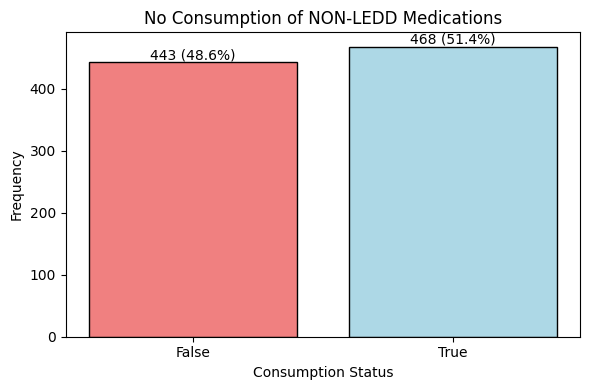

In [181]:

# Crear variable NO MED CONSUMPTION
normal_meds['NO MED CONSUMPTION'] = (
    normal_meds[normal_meds.columns[2:-7]]
    .eq('No Medication')
    .all(axis=1)
)

# Conteo y porcentajes
counts = normal_meds['NO MED CONSUMPTION'].value_counts()
percentages = counts / counts.sum() * 100

# Orden explícito: False primero, True después
counts = counts.reindex([False, True])
percentages = percentages.reindex([False, True])

# Crear figura
plt.figure(figsize=(6, 4))

# Crear barras con borde forzado
bars = plt.bar(
    counts.index.astype(str),
    counts.values,
    color=['lightcoral', 'lightblue'],
    edgecolor='black'
)

# Etiquetas con frecuencia y porcentaje
for i, (count, perc) in enumerate(zip(counts.values, percentages.values)):
    plt.text(
        i,
        count,
        f'{count} ({perc:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Etiquetas y título
plt.xlabel('Consumption Status')
plt.ylabel('Frequency')
plt.title('No Consumption of NON-LEDD Medications')

# Mejorar visualización
plt.tight_layout()

plt.show()


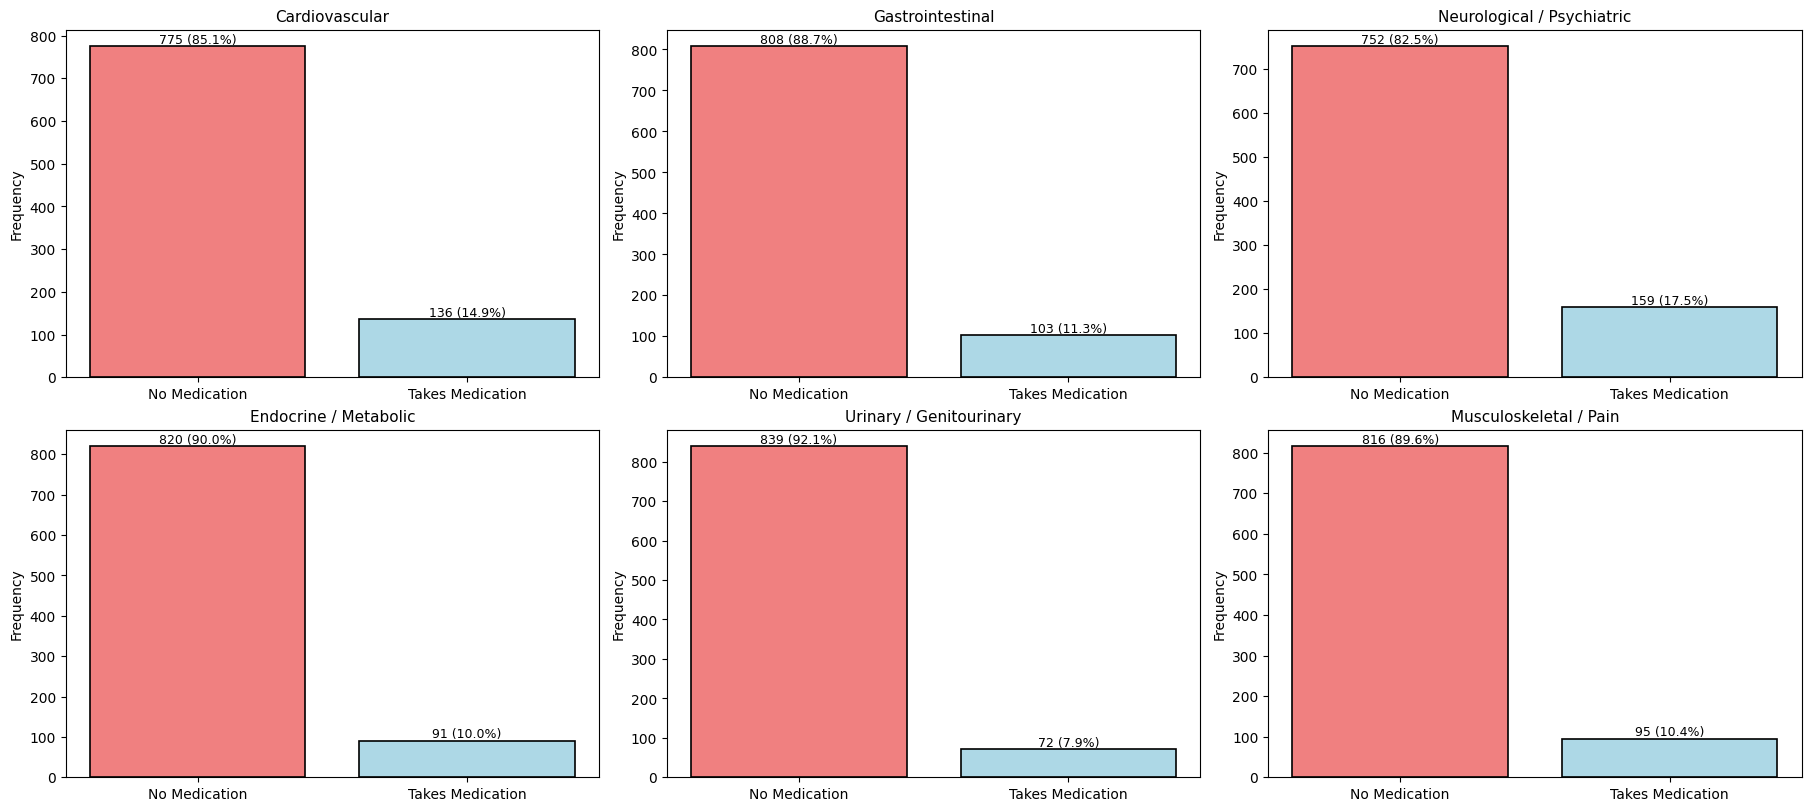

In [182]:
# Columnas a graficar
med_cols = [
    'Cardiovascular', 'Gastrointestinal',
    'Neurological / Psychiatric', 'Endocrine / Metabolic',
    'Urinary / Genitourinary', 'Musculoskeletal / Pain',
]

# Subplots fijos 2x3
nrows, ncols = 2, 3
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(18, 8),
    constrained_layout=True
)

axes = axes.flatten()

order = ['No Medication', 'Takes Medication']  # orden fijo
colors = ['lightcoral', 'lightblue']

for i, col in enumerate(med_cols):
    ax = axes[i]

    counts = normal_meds[col].value_counts().reindex(order).fillna(0).astype(int)
    total = counts.sum()
    percentages = (counts / total * 100) if total > 0 else counts.astype(float)

    bars = ax.bar(
        counts.index,
        counts.values,
        color=colors,
        edgecolor="black",
        linewidth=1.2
    )

    # Etiquetas: frecuencia (porcentaje)
    for bar, count, pct in zip(bars, counts.values, percentages):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{count} ({pct:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.set_title(col, fontsize=11)
    ax.set_ylabel("Frequency")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=0)

plt.show()


In [183]:
chi_square_heatmap(normal_meds, 'Musculoskeletal / Pain', 'UPDRS_III_Class', order_1=None, order_2=['Mild','Moderate'])
chi_square_heatmap(normal_meds, 'Neurological / Psychiatric', 'UPDRS_I_Class', order_1=None, order_2=['Mild','Moderate'])
chi_square_heatmap(normal_meds, 'Neurological / Psychiatric', 'UPDRS_II_Class', order_1=None, order_2=['Mild','Moderate'])


 Chi-square test for: Musculoskeletal / Pain vs UPDRS_III_Class

Chi² statistic = 0.000
p-value = 1.0000
Degrees of freedom = 1
Cramér's V = 0.003
Effect size: Weak
 🛑 No significant association (p ≥ 0.05)
    → No tables or heatmaps displayed.

--------------------------------------------------------------------------------


 Chi-square test for: Neurological / Psychiatric vs UPDRS_I_Class

Chi² statistic = 0.002
p-value = 0.9621
Degrees of freedom = 1
Cramér's V = 0.006
Effect size: Weak
 🛑 No significant association (p ≥ 0.05)
    → No tables or heatmaps displayed.

--------------------------------------------------------------------------------


 Chi-square test for: Neurological / Psychiatric vs UPDRS_II_Class

Chi² statistic = 0.013
p-value = 0.9089
Degrees of freedom = 1
Cramér's V = 0.008
Effect size: Weak
 🛑 No significant association (p ≥ 0.05)
    → No tables or heatmaps displayed.

--------------------------------------------------------------------------------



In [184]:
normal_meds.to_csv('/Users/fserracrespi/Desktop/PD_Project_UofL/PD_DATA/MODELS DEVELOPMENT/DATA FOR MODELS/Normal_Medications_Data.csv', index=False)

### LEDD Medication

In [185]:

ledd_medication=medical_data.copy()
ledd_medication.drop(columns=cols_normal_meds[2:],inplace=True)
ledd_medication.head(3)




,PATNO,Visit ID,Month_11_Medication,Month_11_Dose_Strength_mg_amantadine,Month_11_Total_mg_per_day_amantadine,Month_11_Dose_Strength_mg_selegiline,Month_11_Total_mg_per_day_selegiline,Month_11_Dose_Strength_mg_rotigotine,Month_11_Total_mg_per_day_rotigotine,Month_11_Dose_Strength_mg_pramipexole,...,MDS-UPDRS Part III Total Score,MDS-UPDRS Part IV Total Score,MDS-UPDRS Total Score 1YearProg,UPDRS_III_1YearProg,MDS-UPDRS Total Score,Δ TOTAL_UPDRS_1Y,Δ UPDRS_I_1Y,Δ UPDRS_II_1Y,Δ UPDRS_III_1Y,Δ UPDRS_IV_1Y
728,3001,V10_V12,"['selegiline', 'carbidopa levodopa']",0.0,0.0,5.0,100.0,0.0,0.0,0.0,...,35,0.0,37.0,26,46.0,-9.0,1,-1.0,-9,0.0
729,3003,V10_V12,"['amantadine', 'carbidopa levodopa']",105.0,210.0,0.0,0.0,0.0,0.0,0.0,...,53,0.0,59.0,39,72.0,-13.0,2,-1.0,-14,0.0
730,3010,V10_V12,"['pramipexole', 'carbidopa levodopa']",0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,18,7.0,70.0,34,52.0,18.0,0,4.0,16,-2.0


In [186]:
# === 2. Identificar columnas que representan dosis totales mensuales ===
pattern = r"Month_\d+_Total_mg_per_day_(\w+)"
dose_cols = [c for c in ledd_medication.columns if re.match(pattern, c)]

# Lista única de medicamentos
medications = sorted(list(set(re.match(pattern, c).group(1) for c in dose_cols)))

# === 3. Crear un DataFrame resumen por paciente ===
resumen_final = ledd_medication[["PATNO", "Visit ID"]].copy()

# === 4. Calcular estadísticas de cada medicamento y agregarlas como columnas ===
for med in medications:
    # columnas mensuales del medicamento
    med_cols = [c for c in ledd_medication.columns if f"_Total_mg_per_day_{med}" in c]
    
    # matriz de valores mensuales
    temp = ledd_medication[med_cols]
    
    # calcular medidas estadísticas
    resumen_final[f"Media_dosis_mg_día_{med}"] = temp.mean(axis=1, skipna=True)
    resumen_final[f"Mediana_{med}"] = temp.median(axis=1, skipna=True)
    resumen_final[f"SD_{med}"] = temp.std(axis=1, skipna=True)
    resumen_final[f"Mín_{med}"] = temp.min(axis=1, skipna=True)
    resumen_final[f"Máx_{med}"] = temp.max(axis=1, skipna=True)
    # contar solo meses con dosis válida (no NaN y > 0)
    resumen_final[f"consumo_meses_{med}"] = temp.apply(lambda x: x[(x.notna()) & (x > 0)].count(), axis=1)

# === 5. (Opcional) eliminar filas sin medicación en todo el año ===
mask = resumen_final.filter(like="Media_dosis_mg_día").sum(axis=1) > 0
resumen_final = resumen_final[mask]

In [187]:
ledd_medication=resumen_final.merge(medical_data[['PATNO','Visit ID','UPDRS_I_Class','UPDRS_II_Class','UPDRS_III_Class','UPDRS_I_ProgressionType',
                            'UPDRS_II_ProgressionType',
                            'UPDRS_III_ProgressionType']])
ledd_medication.head(3)

,PATNO,Visit ID,Media_dosis_mg_día_amantadine,Mediana_amantadine,SD_amantadine,Mín_amantadine,Máx_amantadine,consumo_meses_amantadine,Media_dosis_mg_día_apomorphine,Mediana_apomorphine,...,SD_zonisamide,Mín_zonisamide,Máx_zonisamide,consumo_meses_zonisamide,UPDRS_I_Class,UPDRS_II_Class,UPDRS_III_Class,UPDRS_I_ProgressionType,UPDRS_II_ProgressionType,UPDRS_III_ProgressionType
0,3001,V10_V12,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0,Mild,Mild,Moderate,No significant change.,No significant change.,Substantial improv.
1,3003,V10_V12,210.0,210.0,0.0,210.0,210.0,12,0.0,0.0,...,0.0,0.0,0.0,0,Mild,Mild,Moderate,No significant change.,No significant change.,Substantial improv.
2,3010,V10_V12,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0,Moderate,Moderate,Mild,No significant change.,No significant change.,Substantial progress.


In [188]:
ledd_medication

,PATNO,Visit ID,Media_dosis_mg_día_amantadine,Mediana_amantadine,SD_amantadine,Mín_amantadine,Máx_amantadine,consumo_meses_amantadine,Media_dosis_mg_día_apomorphine,Mediana_apomorphine,...,SD_zonisamide,Mín_zonisamide,Máx_zonisamide,consumo_meses_zonisamide,UPDRS_I_Class,UPDRS_II_Class,UPDRS_III_Class,UPDRS_I_ProgressionType,UPDRS_II_ProgressionType,UPDRS_III_ProgressionType
0,3001,V10_V12,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0,Mild,Mild,Moderate,No significant change.,No significant change.,Substantial improv.
1,3003,V10_V12,210.0,210.0,0.0,210.0,210.0,12,0.0,0.0,...,0.0,0.0,0.0,0,Mild,Mild,Moderate,No significant change.,No significant change.,Substantial improv.
2,3010,V10_V12,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0,Moderate,Moderate,Mild,No significant change.,No significant change.,Substantial progress.
3,3023,V08_V10,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0,Mild,Mild,Moderate,No significant change.,No significant change.,No significant change.
4,3051,V10_V12,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0,Mild,Mild,Mild,No significant change.,Substantial improv.,No significant change.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
905,238871,V04_V06,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0,Mild,Mild,Mild,No significant change.,No significant change.,No significant change.
906,239947,V04_V06,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0,Moderate,Mild,Mild,Substantial improv.,Substantial improv.,Substantial improv.
907,240358,V04_V06,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0,Mild,Mild,Mild,No significant change.,No significant change.,Substantial improv.
908,243027,V04_V06,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0,Mild,Mild,Mild,No significant change.,No significant change.,Substantial improv.


In [189]:
ledd_medication.to_csv('/Users/fserracrespi/Desktop/PD_Project_UofL/PD_DATA/MODELS DEVELOPMENT/DATA FOR MODELS/LEDD_Medication_Data.csv', index=False)

### Metricas generales

In [190]:
# columnas de dosis media diaria
media_dosis_cols = [c for c in ledd_medication.columns if c.startswith("Media_dosis_mg_día_")]

# media global de la dosis media
media_dosis_global = ledd_medication[media_dosis_cols].mean().sort_values(ascending=False)

media_dosis_global


Media_dosis_mg_día_levodopa           382.767308
Media_dosis_mg_día_carbidopa           72.210096
Media_dosis_mg_día_pramipexole         43.997527
Media_dosis_mg_día_rasagiline          38.557692
Media_dosis_mg_día_amantadine          33.102839
Media_dosis_mg_día_ropinirole          25.467491
Media_dosis_mg_día_entacapone          18.553114
Media_dosis_mg_día_benserazide         12.180540
Media_dosis_mg_día_rotigotine          10.377930
Media_dosis_mg_día_selegiline           4.869505
Media_dosis_mg_día_safinamide           3.834615
Media_dosis_mg_día_piribedil            1.767399
Media_dosis_mg_día_apomorphine          0.602381
Media_dosis_mg_día_trihexyphenidyl      0.329670
Media_dosis_mg_día_zonisamide           0.000000
dtype: float64

In [191]:
# columnas de dosis media diaria
consumo_meses_cols = [c for c in ledd_medication.columns if c.startswith("consumo_meses_")]

# media global de la dosis media
consumo_meses_global = ledd_medication[consumo_meses_cols].mean().sort_values(ascending=False)

consumo_meses_global

consumo_meses_levodopa           9.789011
consumo_meses_carbidopa          7.838462
consumo_meses_rasagiline         4.525275
consumo_meses_pramipexole        2.725275
consumo_meses_amantadine         1.768132
consumo_meses_benserazide        1.603297
consumo_meses_ropinirole         1.528571
consumo_meses_rotigotine         0.752747
consumo_meses_selegiline         0.643956
consumo_meses_safinamide         0.312088
consumo_meses_entacapone         0.241758
consumo_meses_piribedil          0.154945
consumo_meses_trihexyphenidyl    0.038462
consumo_meses_apomorphine        0.031868
consumo_meses_zonisamide         0.000000
dtype: float64

In [192]:
# columnas de dosis media diaria
SD_consumo_cols = [c for c in ledd_medication.columns if c.startswith("SD_")]

# media global de la dosis media
SD_consumo_global = ledd_medication[SD_consumo_cols].mean().sort_values(ascending=True)

SD_consumo_global

SD_zonisamide          0.000000
SD_trihexyphenidyl     0.063445
SD_piribedil           0.480114
SD_apomorphine         0.556468
SD_selegiline          0.691148
SD_safinamide          0.785746
SD_rotigotine          2.135052
SD_benserazide         2.341152
SD_rasagiline          2.688844
SD_amantadine          4.668117
SD_entacapone          4.677421
SD_ropinirole          5.242016
SD_pramipexole         6.401915
SD_carbidopa          13.060206
SD_levodopa           66.309621
dtype: float64

### Metricas por grupo UPDRS III y ANOVA UPDRS 3 Class


#### Consumo diario

In [193]:
# columnas de dosis media diaria
media_dosis_cols = [c for c in ledd_medication.columns if c.startswith("Media_dosis_mg_día_")]

ledd_medication_updrs3_mild = ledd_medication[ledd_medication['UPDRS_III_Class']=='Mild']
ledd_medication_updrs3_moderate = ledd_medication[ledd_medication['UPDRS_III_Class']=='Moderate']

# media uprds3 mild
media_dosis_updrs3_mild = ledd_medication_updrs3_mild[media_dosis_cols].mean().sort_values(ascending=False)

print(media_dosis_updrs3_mild)
print("\n")
# media uprds3 moderate
media_dosis_updrs3_moderate = ledd_medication_updrs3_moderate[media_dosis_cols].mean().sort_values(ascending=False)
print(media_dosis_updrs3_moderate)




Media_dosis_mg_día_levodopa           382.184738
Media_dosis_mg_día_carbidopa           71.047940
Media_dosis_mg_día_pramipexole         45.149318
Media_dosis_mg_día_rasagiline          39.265799
Media_dosis_mg_día_amantadine          31.571561
Media_dosis_mg_día_ropinirole          26.206113
Media_dosis_mg_día_entacapone          19.434118
Media_dosis_mg_día_benserazide         12.897047
Media_dosis_mg_día_rotigotine          10.785523
Media_dosis_mg_día_selegiline           4.396427
Media_dosis_mg_día_safinamide           4.076208
Media_dosis_mg_día_piribedil            1.992978
Media_dosis_mg_día_apomorphine          0.679265
Media_dosis_mg_día_trihexyphenidyl      0.247831
Media_dosis_mg_día_zonisamide           0.000000
dtype: float64


Media_dosis_mg_día_levodopa           387.331715
Media_dosis_mg_día_carbidopa           81.315534
Media_dosis_mg_día_amantadine          45.100324
Media_dosis_mg_día_pramipexole         34.973301
Media_dosis_mg_día_rasagiline          33.009709
Med

In [194]:
for med_col in media_dosis_cols:
    print("="*80)
    print(f"Kruskal–Dunn analysis for {med_col} by UPDRS III Class")

    # extraer datos por grupo (y quitar NaNs)
    mild = ledd_medication.loc[
        ledd_medication['UPDRS_III_Class'] == 'Mild', med_col
    ]

    moderate = ledd_medication.loc[
        ledd_medication['UPDRS_III_Class'] == 'Moderate', med_col
    ]

    # Kruskal necesita variación: si todos los valores (en ambos grupos) son constantes, no tiene sentido
    combined = pd.concat([mild, moderate], axis=0)
    if combined.nunique() < 2:
        print("Saltado: no hay variación (todos los valores son iguales).")
        continue

    # Si los dos grupos son efectivamente iguales (misma distribución exacta y mismo tamaño), no aporta comparar
    if (len(mild) == len(moderate)) and np.array_equal(
        np.sort(mild.to_numpy()),
        np.sort(moderate.to_numpy())
    ):
        print("Saltado: Mild y Moderate contienen exactamente los mismos valores.")
        continue

    # === Kruskal–Wallis ===
    h_stat, p_kw = kruskal(mild, moderate)
    print(f"Kruskal-Wallis H = {h_stat:.3f}, p = {p_kw:.4g}")

    # === Dunn post-hoc (solo si es significativo) ===
    if p_kw < 0.05:
        print("Post-hoc Dunn (Bonferroni):")

        temp_df = ledd_medication[
            ledd_medication['UPDRS_III_Class'].isin(['Mild', 'Moderate'])
        ][['UPDRS_III_Class', med_col]].dropna()

        dunn = sp.posthoc_dunn(
            temp_df,
            val_col=med_col,
            group_col='UPDRS_III_Class',
            p_adjust='bonferroni'
        )
        print(dunn)
    else:
        print("No diferencias significativas → Dunn no aplicado")

Kruskal–Dunn analysis for Media_dosis_mg_día_amantadine by UPDRS III Class
Kruskal-Wallis H = 0.514, p = 0.4733
No diferencias significativas → Dunn no aplicado
Kruskal–Dunn analysis for Media_dosis_mg_día_apomorphine by UPDRS III Class
Kruskal-Wallis H = 0.512, p = 0.4742
No diferencias significativas → Dunn no aplicado
Kruskal–Dunn analysis for Media_dosis_mg_día_benserazide by UPDRS III Class
Kruskal-Wallis H = 1.838, p = 0.1751
No diferencias significativas → Dunn no aplicado
Kruskal–Dunn analysis for Media_dosis_mg_día_carbidopa by UPDRS III Class
Kruskal-Wallis H = 1.903, p = 0.1678
No diferencias significativas → Dunn no aplicado
Kruskal–Dunn analysis for Media_dosis_mg_día_entacapone by UPDRS III Class
Kruskal-Wallis H = 1.108, p = 0.2925
No diferencias significativas → Dunn no aplicado
Kruskal–Dunn analysis for Media_dosis_mg_día_levodopa by UPDRS III Class
Kruskal-Wallis H = 0.000, p = 0.9876
No diferencias significativas → Dunn no aplicado
Kruskal–Dunn analysis for Media_dos

#### Consumo meses


In [195]:
# columnas de dosis media diaria
meses_consumo_cols = [c for c in ledd_medication.columns if c.startswith("consumo_meses_")]

meses_consumo_updrs3_mild = ledd_medication[ledd_medication['UPDRS_III_Class']=='Mild']
meses_consumo_updrs3_moderate = ledd_medication[ledd_medication['UPDRS_III_Class']=='Moderate']

# media uprds3 mild
meses_consumo_updrs3_mild = meses_consumo_updrs3_mild[meses_consumo_cols].mean().sort_values(ascending=False)

print(meses_consumo_updrs3_mild)
print("\n")
# media uprds3 moderate
meses_consumo_updrs3_moderate = meses_consumo_updrs3_moderate[meses_consumo_cols].mean().sort_values(ascending=False)
print(meses_consumo_updrs3_moderate)

consumo_meses_levodopa           9.765799
consumo_meses_carbidopa          7.712515
consumo_meses_rasagiline         4.619579
consumo_meses_pramipexole        2.824040
consumo_meses_amantadine         1.752169
consumo_meses_benserazide        1.645601
consumo_meses_ropinirole         1.574969
consumo_meses_rotigotine         0.759603
consumo_meses_selegiline         0.573730
consumo_meses_safinamide         0.337051
consumo_meses_entacapone         0.257745
consumo_meses_piribedil          0.174721
consumo_meses_apomorphine        0.035936
consumo_meses_trihexyphenidyl    0.028501
consumo_meses_zonisamide         0.000000
dtype: float64


consumo_meses_levodopa           9.970874
consumo_meses_carbidopa          8.825243
consumo_meses_rasagiline         3.786408
consumo_meses_pramipexole        1.951456
consumo_meses_amantadine         1.893204
consumo_meses_benserazide        1.271845
consumo_meses_selegiline         1.194175
consumo_meses_ropinirole         1.165049
consumo_meses_rot

In [196]:
for med_col in meses_consumo_cols:
    print("="*80)
    print(f"Kruskal–Dunn analysis for {med_col} by UPDRS III Class")

    # extraer datos por grupo (y quitar NaNs)
    mild = ledd_medication.loc[
        ledd_medication['UPDRS_III_Class'] == 'Mild', med_col
    ]

    moderate = ledd_medication.loc[
        ledd_medication['UPDRS_III_Class'] == 'Moderate', med_col
    ]

    # Kruskal necesita variación: si todos los valores (en ambos grupos) son constantes, no tiene sentido
    combined = pd.concat([mild, moderate], axis=0)
    if combined.nunique() < 2:
        print("Saltado: no hay variación (todos los valores son iguales).")
        continue

    # Si los dos grupos son efectivamente iguales (misma distribución exacta y mismo tamaño), no aporta comparar
    if (len(mild) == len(moderate)) and np.array_equal(
        np.sort(mild.to_numpy()),
        np.sort(moderate.to_numpy())
    ):
        print("Saltado: Mild y Moderate contienen exactamente los mismos valores.")
        continue

    # === Kruskal–Wallis ===
    h_stat, p_kw = kruskal(mild, moderate)
    print(f"Kruskal-Wallis H = {h_stat:.3f}, p = {p_kw:.4g}")

    # === Dunn post-hoc (solo si es significativo) ===
    if p_kw < 0.05:
        print("Post-hoc Dunn (Bonferroni):")

        temp_df = ledd_medication[
            ledd_medication['UPDRS_III_Class'].isin(['Mild', 'Moderate'])
        ][['UPDRS_III_Class', med_col]].dropna()

        dunn = sp.posthoc_dunn(
            temp_df,
            val_col=med_col,
            group_col='UPDRS_III_Class',
            p_adjust='bonferroni'
        )
        print(dunn)
    else:
        print("No diferencias significativas → Dunn no aplicado")

Kruskal–Dunn analysis for consumo_meses_amantadine by UPDRS III Class
Kruskal-Wallis H = 0.410, p = 0.5219
No diferencias significativas → Dunn no aplicado
Kruskal–Dunn analysis for consumo_meses_apomorphine by UPDRS III Class
Kruskal-Wallis H = 0.512, p = 0.4742
No diferencias significativas → Dunn no aplicado
Kruskal–Dunn analysis for consumo_meses_benserazide by UPDRS III Class
Kruskal-Wallis H = 1.496, p = 0.2213
No diferencias significativas → Dunn no aplicado
Kruskal–Dunn analysis for consumo_meses_carbidopa by UPDRS III Class
Kruskal-Wallis H = 3.273, p = 0.07043
No diferencias significativas → Dunn no aplicado
Kruskal–Dunn analysis for consumo_meses_entacapone by UPDRS III Class
Kruskal-Wallis H = 1.127, p = 0.2884
No diferencias significativas → Dunn no aplicado
Kruskal–Dunn analysis for consumo_meses_levodopa by UPDRS III Class
Kruskal-Wallis H = 0.016, p = 0.8999
No diferencias significativas → Dunn no aplicado
Kruskal–Dunn analysis for consumo_meses_piribedil by UPDRS III C

## meds reactivas a levodopa


In [197]:
ledd_medication.head(3)

,PATNO,Visit ID,Media_dosis_mg_día_amantadine,Mediana_amantadine,SD_amantadine,Mín_amantadine,Máx_amantadine,consumo_meses_amantadine,Media_dosis_mg_día_apomorphine,Mediana_apomorphine,...,SD_zonisamide,Mín_zonisamide,Máx_zonisamide,consumo_meses_zonisamide,UPDRS_I_Class,UPDRS_II_Class,UPDRS_III_Class,UPDRS_I_ProgressionType,UPDRS_II_ProgressionType,UPDRS_III_ProgressionType
0,3001,V10_V12,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0,Mild,Mild,Moderate,No significant change.,No significant change.,Substantial improv.
1,3003,V10_V12,210.0,210.0,0.0,210.0,210.0,12,0.0,0.0,...,0.0,0.0,0.0,0,Mild,Mild,Moderate,No significant change.,No significant change.,Substantial improv.
2,3010,V10_V12,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0,Moderate,Moderate,Mild,No significant change.,No significant change.,Substantial progress.


In [198]:
normal_meds.head(3)

,PATNO,Visit ID,Cardiovascular,Gastrointestinal,Neurological / Psychiatric,Endocrine / Metabolic,Urinary / Genitourinary,Musculoskeletal / Pain,UPDRS_I_Class,UPDRS_II_Class,UPDRS_III_Class,UPDRS_IV_Class,UPDRS_I_ProgressionType,UPDRS_II_ProgressionType,UPDRS_III_ProgressionType,NO MED CONSUMPTION
728,3001,V10_V12,Takes Medication,No Medication,No Medication,No Medication,Takes Medication,No Medication,Mild,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.,False
729,3003,V10_V12,No Medication,Takes Medication,No Medication,No Medication,Takes Medication,No Medication,Mild,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.,False
730,3010,V10_V12,No Medication,No Medication,No Medication,No Medication,No Medication,No Medication,Moderate,Moderate,Mild,Moderate,No significant change.,No significant change.,Substantial progress.,True


In [199]:
total_data = normal_meds[normal_meds.columns[:-7]].merge(ledd_medication, on=['PATNO','Visit ID'], how='inner')
total_data.head(3)


,PATNO,Visit ID,Cardiovascular,Gastrointestinal,Neurological / Psychiatric,Endocrine / Metabolic,Urinary / Genitourinary,Musculoskeletal / Pain,UPDRS_I_Class_x,Media_dosis_mg_día_amantadine,...,SD_zonisamide,Mín_zonisamide,Máx_zonisamide,consumo_meses_zonisamide,UPDRS_I_Class_y,UPDRS_II_Class,UPDRS_III_Class,UPDRS_I_ProgressionType,UPDRS_II_ProgressionType,UPDRS_III_ProgressionType
0,3001,V10_V12,Takes Medication,No Medication,No Medication,No Medication,Takes Medication,No Medication,Mild,0.0,...,0.0,0.0,0.0,0,Mild,Mild,Moderate,No significant change.,No significant change.,Substantial improv.
1,3003,V10_V12,No Medication,Takes Medication,No Medication,No Medication,Takes Medication,No Medication,Mild,210.0,...,0.0,0.0,0.0,0,Mild,Mild,Moderate,No significant change.,No significant change.,Substantial improv.
2,3010,V10_V12,No Medication,No Medication,No Medication,No Medication,No Medication,No Medication,Moderate,0.0,...,0.0,0.0,0.0,0,Moderate,Moderate,Mild,No significant change.,No significant change.,Substantial progress.


Kruskal-Dunn analysis for Cardiovascular by UPDRS III Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


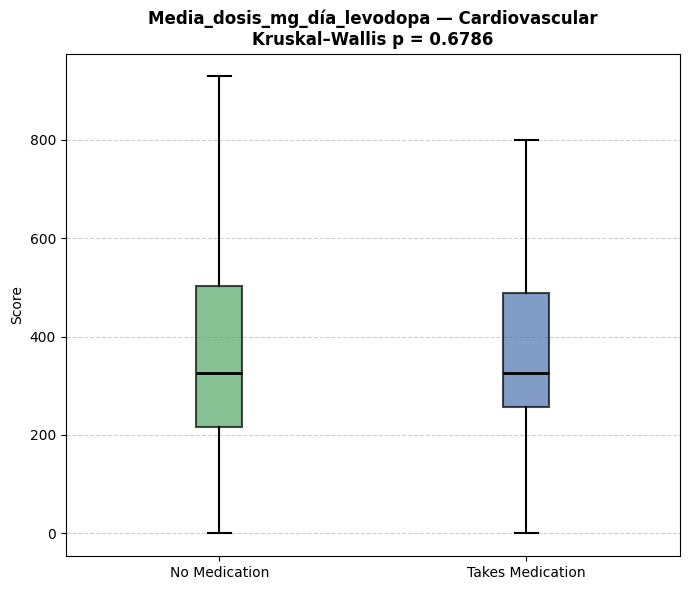


=== KRUSKAL–WALLIS RESULTS ===
Media_dosis_mg_día_levodopa: H = 0.172, p = 6.7856e-01  --> 🛑 Not significant
Kruskal-Dunn analysis for Gastrointestinal by UPDRS III Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


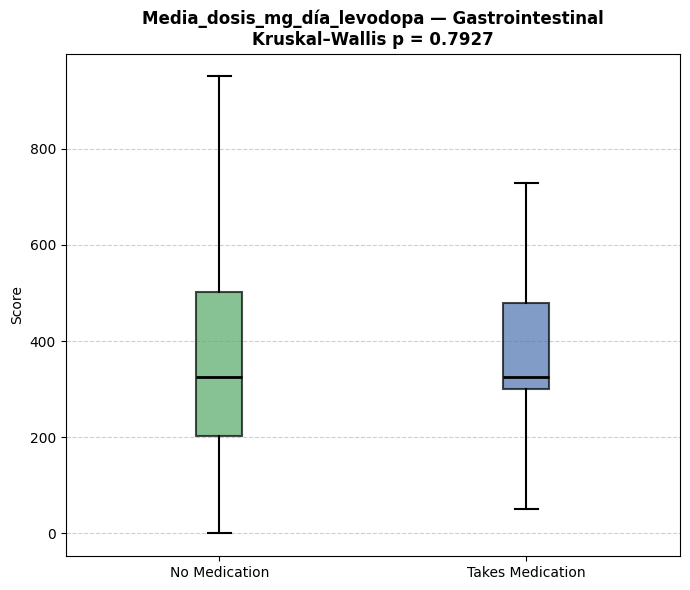


=== KRUSKAL–WALLIS RESULTS ===
Media_dosis_mg_día_levodopa: H = 0.069, p = 7.9267e-01  --> 🛑 Not significant
Kruskal-Dunn analysis for Neurological / Psychiatric by UPDRS III Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


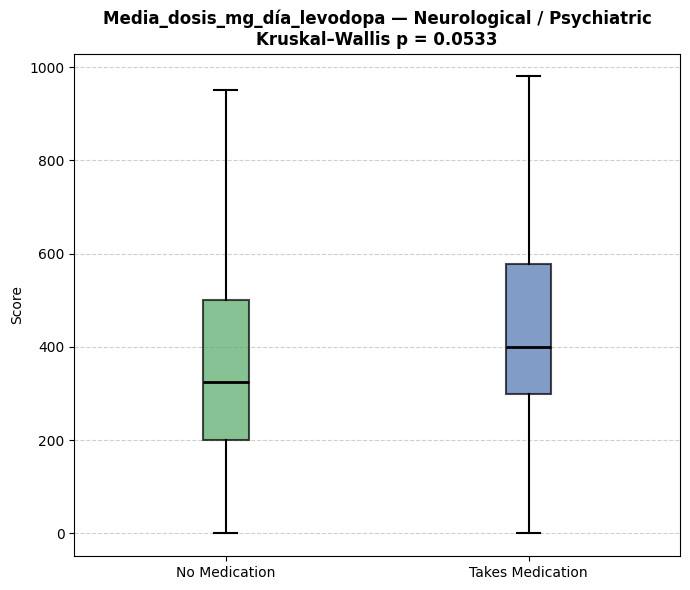


=== KRUSKAL–WALLIS RESULTS ===
Media_dosis_mg_día_levodopa: H = 3.733, p = 5.3334e-02  --> 🛑 Not significant
Kruskal-Dunn analysis for Endocrine / Metabolic by UPDRS III Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


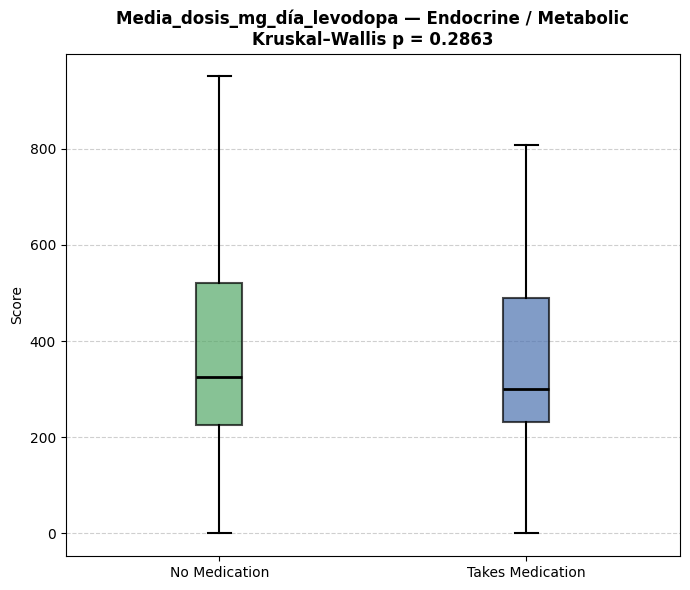


=== KRUSKAL–WALLIS RESULTS ===
Media_dosis_mg_día_levodopa: H = 1.137, p = 2.8631e-01  --> 🛑 Not significant
Kruskal-Dunn analysis for Urinary / Genitourinary by UPDRS III Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


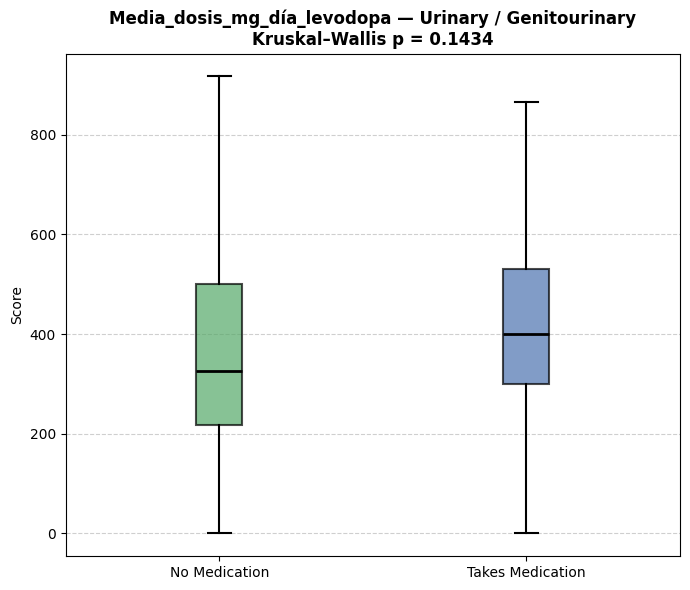


=== KRUSKAL–WALLIS RESULTS ===
Media_dosis_mg_día_levodopa: H = 2.141, p = 1.4338e-01  --> 🛑 Not significant
Kruskal-Dunn analysis for Musculoskeletal / Pain by UPDRS III Class:


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_17728/1107694872.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(


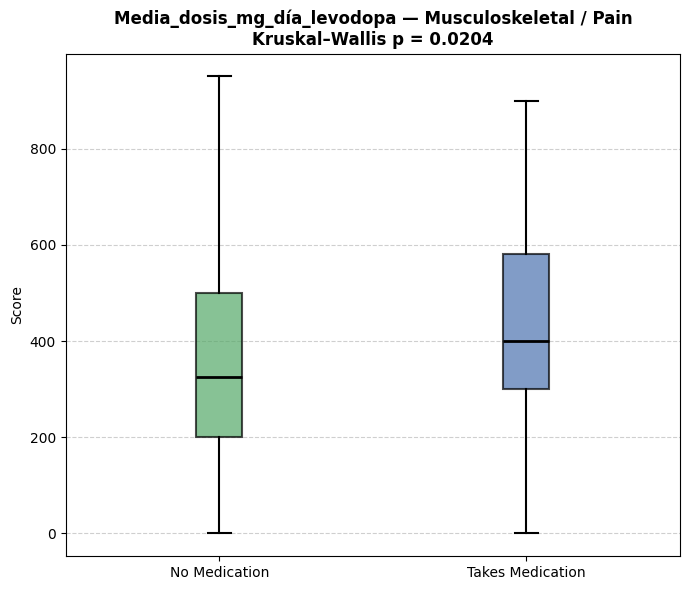


=== KRUSKAL–WALLIS RESULTS ===
Media_dosis_mg_día_levodopa: H = 5.376, p = 2.0415e-02  --> ✅ Significant (Dunn performed)

=== Dunn’s Test for Media_dosis_mg_día_levodopa ===


,No Medication,Takes Medication
No Medication,1.0000,0.0204
Takes Medication,0.0204,1.0000


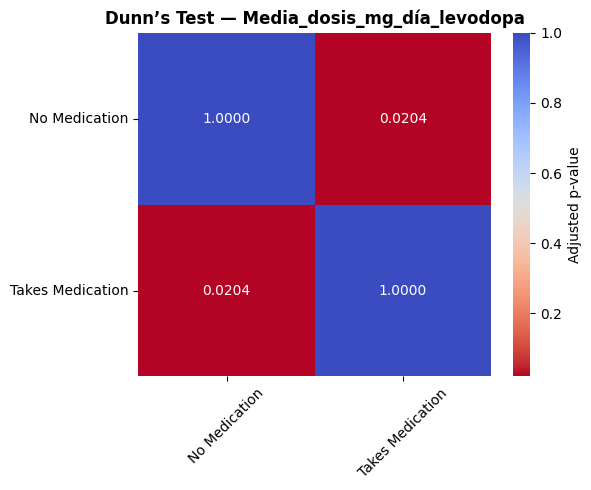

In [200]:
for col in total_data.columns[2:8]:
    print(f'Kruskal-Dunn analysis for {col} by UPDRS III Class:')
    kruskal_dunn_by_class(total_data, col, ['Media_dosis_mg_día_levodopa'])